In [378]:
### Importing required libraries ###

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning) 
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
import seaborn as sns
from linearmodels.panel import PanelOLS
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import scipy
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import kruskal
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from linearmodels import PooledOLS
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.formula.api import ols
import scikit_posthocs as sp
from scipy.stats import zscore
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import adfuller

1.	Context  
2.	Functions  
3.	Read in all datasets  
    3.1. Which datsets did we choose and why?  
4.	Creating datasets  
	4.1. Modify waste datasets  
	4.2. Exploratory analysis of waste datasets  
	4.3. Merge into one waste dataset  
	4.4. Creating and anylsizing master dataset  
	4.5. Merge all dataset  
	4.6. Analyze missing values  
	4.7. Data Transformation  
	4.8. Outlier Anylysis  
5.	Treating of outliers and missing values.  
6.	Recycling development  
	6.1. How is the development?  
	6.2. How does recycling compare across countries in the EU and How does it compare for specific types of waste?  
	6.3. Target analysis  
7.	Are there characteristics of countries that could lead to increased recycling?  
	7.1. Panel Regression  
	7.2. PCA  
	7.3. Hierarchical Clustering  
8.	How well can the development of the amount of recycling be predicted?  
	8.1. Linear regression  
	8.2. Time Series  
	8.3. Conclusion  
9. Findings
	9.1. Potential bias
	9.2. Why were the quesstions good?
	9.3. DO the answers make sense?
	9.4. Were there any difficulties?
	9.5. Which Data Science tools and techniques were learned during this exercise?
	9.6. Key insights
10. Appendix	

# 1. Context

## EU Recycling
European policymakers have long recognized that better waste recycling is crucial for environmental protection, resource conservation, and sustainable growth. EU waste policy is central to the Circular Economy vision – the idea of keeping materials in use for as long as possible and minimizing waste. In fact, EU directives on waste management have been enacted to push member states up the “waste hierarchy” (prioritizing prevention, then reuse, then recycling, over disposal [3]). These laws aim to extract value from what we throw away and reduce environmental harm. For example, the Waste Framework Directive (2008/98/EC) created a broad legal framework for waste in Europe, setting ambitious recycling targets and mandating national waste plans. Under this directive, countries were required to recycle at least 50% of household (municipal) waste by 2020, with even higher goals of 60% by 2030 and 65% by 2035 [1]. Complementing this, the Packaging and Packaging Waste Directive (94/62/EC, later updated) compels high recovery of packaging materials (aiming for about 65% recycling of all packaging by 2025 [1]), and the WEEE Directive (2012/19/EU) addresses electronic waste by setting collection and recycling requirements for e-waste. Through such policies – along with others like the Landfill Directive to curb dumping – the EU has built a comprehensive regulatory push to improve recycling rates and move Europe toward a circular economy. The motivation behind these directives is clear: waste that isn’t recycled represents lost raw materials and often ends up polluting land, water, and air. By enforcing common rules, the EU strives to ensure all member states contribute to the environmental goals and benefit from the economic opportunities of recycling (like job creation in the recycling industry and reduced raw material imports) [3].
 
## Recycling Disparities
Despite these regulations and goals, monitoring compliance and progress is a critical ongoing need. Europe’s waste challenge remains significant – the average European generates around 500–600 kg of municipal waste per year, and as of 2020 roughly 49% of that (just about half) was recycled [1] [2]. This is a notable improvement from a decade ago (when only around 37% was recycled [1]), indicating that EU policies and national efforts have had an impact. However, this EU-wide average hides stark differences across countries. In some member states, less than a third of waste gets recycled, and over 60% of household waste still ends up in landfills [3] – a sign of lagging performance – whereas other states have become recycling frontrunners, already surpassing the EU’s 2025 targets with well over half of their waste recycled. These disparities raise important questions about why certain countries succeed and others struggle, and they underscore why the EU cares deeply about tracking and understanding recycling progress. The European Commission doesn’t just set targets – it actively checks how each country is doing, producing “early warning” assessments to flag member states at risk of missing upcoming recycling goals [1]. Such oversight is essential to ensure that environmental directives are implemented effectively and that the EU’s collective goals (like reducing landfill use to under 10% by 2035 [1]) will be met.
 
This is where data-driven analysis becomes invaluable: by examining trends over time and patterns across countries, we help to reveal what’s working, what isn’t, and what factors might be driving these outcomes. With vast datasets collected (e.g. through Eurostat and national reports), we strive to make sense of the numbers – identifying successes to replicate, pinpointing gaps that need intervention, and ultimately supporting better policy decisions.
 
With this research project we want to answer the following questions:
- How has the amount of recycling of waste developed in the EU overall over time?
- How does recycling compare across countries in the EU?
- How does it compare for specific types of waste such as municipal waste, packaging waste, and
electrical waste?
- Are there characteristics of countries that could lead to increased recycling?
- How well can the development of the amount of recycling be predicted?
 
[1] [EUR-Lex COM(2023) 304](https://eur-lex.europa.eu/legal-content/EN/TXT/?%3Bqid=1686220362244&uri=COM%3A2023%3A304%3AFIN#:~:text=2025%2C%20Member%20States%20are%20required,waste%20management%20plans%20and%20waste)
 
[2] [Eurostat](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Municipal_waste%20statistics#Municipal_waste_generation)
 
[3] [European Commission Environment](https://environment.ec.europa.eu/index_en?prefLang=de)

# Functions
This chapter contains all the functions that we created to help us analyze and clean the datasets.

In [379]:
"""
This function filters a given Eurostat-dataframe to keep only the 27 current EU member states AND the EU27_2020 aggregate.
It then prints statistics and explicitly lists the countries/codes that were removed.
"""

def filter_to_eu27(df, name, eu_countries_map):
    """
    Filters the dataframe to keep only the 27 current EU member states AND the EU27_2020 aggregate.
    Prints statistics and explicitly lists the countries/codes that were removed.
    """
    initial_rows = len(df)
    
    # 1. Identify what is currently in the dataframe
    current_geo = set(df['geo'].unique())
    
    # 2. Identify valid keys (EU countries + EU Aggregate)
    valid_geo = set(eu_countries_map.keys())
    
    # 3. Calculate the difference (What will be removed?)
    removed_geo = current_geo - valid_geo
    
    # 4. Filter: Keep rows where 'geo' is in our valid keys
    df_filtered = df[df['geo'].isin(valid_geo)].copy()
    
    removed_rows = initial_rows - len(df_filtered)
    
    print(f"[{name}] Filtered to EU-27 + Aggregate:")
    print(f"   - Kept: {len(df_filtered)} rows")
    print(f"   - Removed: {removed_rows} rows")
    
    if removed_geo:
        # Sort list for better readability
        print(f"   - Removed Countries/Aggregates: {sorted(list(removed_geo))}")
    else:
        print(f"   - No countries removed (Dataset matched requirements exactly).")
    
    print("-" * 40) # Separator line
    
    return df_filtered

In [380]:
"""
This function drops a given list of columns from a list of dataframes if the columns exist.
"""

def drop_columns_if_exist(dfs, columns_to_drop, verbose=True):
    """
    Drops a specific list of columns from a list of dataframes if they exist.
    """
    if verbose:
        print(f"--- Dropping {len(columns_to_drop)} specific columns ---")
    
    for i, df in enumerate(dfs):
        # Find intersection: which columns to drop are actually in this df?
        cols_in_df = [c for c in df.columns if c in columns_to_drop]
        
        if cols_in_df:
            df.drop(columns=cols_in_df, inplace=True)
            if verbose:
                print(f"[Dataset {i+1}] Dropped {len(cols_in_df)} columns: {cols_in_df}")
        else:
            if verbose:
                print(f"[Dataset {i+1}] No matching columns found.")

In [381]:
"""
    This function removes all columns that are fully empty.
"""
def drop_fully_empty_columns(df, verbose=True):
    """
    Remove all columns that contain only NaN values.
    """
    empty_cols = df.columns[df.isna().all()].tolist()
    
    if verbose and empty_cols:
        print("Dropping fully empty columns:", empty_cols)
    elif verbose:
        print("No fully empty columns found.")
    
    return df.drop(columns=empty_cols)

In [382]:
"""
This function identifies columns whic hexists in all dataframes and 
"""

def drop_global_constant_columns(dfs):
    """
    Identifies and drops columns that exist in ALL dataframes AND have the 
    exact same single constant value across ALL dataframes.
    Returns a dictionary of {column: constant_value} for documentation.
    """
    # 1. Identify columns present in ALL dataframes
    if not dfs:
        return {}
        
    common_cols = set(dfs[0].columns)
    for df in dfs[1:]:
        common_cols.intersection_update(df.columns)
    
    global_constants = {}
    
    # 2. Check which of these common columns are globally constant
    for col in list(common_cols):
        unique_vals = set()
        is_constant_everywhere = True
        
        for df in dfs:
            # Get unique values for this column in this dataframe
            vals = df[col].unique()
            
            # If a dataframe has more than 1 value (or 0), it's not constant within itself
            if len(vals) != 1:
                is_constant_everywhere = False
                break
            
            unique_vals.add(vals[0])
            
        # 3. Check if the value is the same across all dataframes (set length must be 1)
        if is_constant_everywhere and len(unique_vals) == 1:
            global_constants[col] = unique_vals.pop()

    # 4. Drop these columns from all dataframes
    if global_constants:
        print(f"Dropping {len(global_constants)} globally constant columns:")
        for col, val in global_constants.items():
            print(f"  - '{col}': '{val}'")
            for df in dfs:
                df.drop(columns=[col], inplace=True)
    else:
        print("No globally constant columns found.")
        
    return global_constants



In [383]:
"""
This function iterates through ALL dataframes, collects unique code-description pairs across all of them, and prints a single consolidated legend.
"""

def extract_and_print_combined_legend(dfs):
    """
    Iterates through ALL dataframes, collects unique code-description pairs 
    across all of them, and prints a single consolidated legend.
    """
    # Define the known pairs (Code : Description Column)
    known_pairs = {
        'OBS_FLAG': 'Observation status (Flag) V2 structure',
        'unit': 'Unit of measure',
        'waste': 'Waste categories',
        'wst_oper': 'Waste management operations',
        'geo': 'Geopolitical entity (reporting)',
        'STRUCTURE_ID':	'STRUCTURE_NAME'
        
    }

    # Dictionary to store unique pairs for each category
    # Structure: {'OBS_FLAG': {('b', 'break in series'), ...}, ...}
    combined_legends = {key: set() for key in known_pairs}

    # 1. Collect all pairs from all dataframes
    for df in dfs:
        for code_col, desc_col in known_pairs.items():
            if code_col in df.columns and desc_col in df.columns:
                # Get unique pairs from this specific dataframe
                pairs = df[[code_col, desc_col]].dropna(subset=[code_col]).drop_duplicates()
                
                # Add to our master set
                for _, row in pairs.iterrows():
                    combined_legends[code_col].add((row[code_col], row[desc_col]))

    # 2. Print the consolidated legend
    print("=== COMBINED DATASET LEGEND (ALL DATASETS) ===\n")
    
    for category, pairs in combined_legends.items():
        if pairs:
            print(f"[{category}]")
            # Sort by code (first element of tuple) for readability
            sorted_pairs = sorted(list(pairs), key=lambda x: x[0])
            
            for code, desc in sorted_pairs:
                print(f"  {code} : {desc}")
            print() # Empty line between categories

In [384]:
def create_wide_waste_dataframe_all_units(df):
    """
    Transforms the dataset to Wide Format retaining ALL units.
    Creates columns combining Operation + Unit (e.g., 'waste_generated_tonnes').
    Fixes the trailing underscore issue for index columns.
    """
    print("=== TRANSFORMING TO WIDE FORMAT (KEEPING ALL UNITS) ===\n")
    
    # 1. Pivot: Long -> Wide
    df_wide = df.pivot_table(
        index=['geo', 'TIME_PERIOD'], 
        columns=['wst_oper', 'unit'], 
        values='OBS_VALUE'
    ).reset_index()
    
    # 2. Flatten and Rename Columns
    
    op_map = {
        'GEN': 'waste_generated',
        'DSP_L_OTH': 'waste_landfill',
        'DSP_I': 'waste_incinerated',
        'RCY': 'waste_recycled_total',
        'TRT': 'waste_treated_total',
        'RCY_M': 'waste_recycled_material',
        'RCY_C_D': 'waste_composted',
        'PRP_REU': 'waste_reuse',
        'DSP_I_RCV_E': 'waste_incinerated_energy',
        'RCV_E': 'waste_energy_recovery'
    }
    
    unit_map = {
        'KG_HAB': 'kg_capita',
        'THS_T': 'tonnes'
    }
    
    new_columns = []
    
    for col in df_wide.columns:
        # Check if it is a tuple (MultiIndex column)
        if isinstance(col, tuple):
            op_code, unit_code = col
            
            # FIX: If unit_code is empty (happens for geo and TIME_PERIOD), just use the name
            if not unit_code:
                new_columns.append(op_code)
                continue
            
            # Translate codes
            op_name = op_map.get(op_code, op_code)
            unit_name = unit_map.get(unit_code, unit_code)
            
            # Combine only if unit exists
            new_name = f"{op_name}_{unit_name}"
            new_columns.append(new_name)
            
        else:
            # Fallback for simple strings
            new_columns.append(col)
    
    # Assign new clean column names
    df_wide.columns = new_columns
    
    # Info Output
    print(f"Pivoted shape: {df_wide.shape}")
    print(f"Columns created ({len(new_columns)}):")
    print(new_columns)
    
    return df_wide

In [385]:
def create_waste_dataset_scaffold(df_ops, df_mun, df_pack, df_elect, country_map):
    """
    Create a balanced country–year panel (scaffold) and merge all datasets onto it.

    The function builds a complete grid of 28 countries × 24 years (2000–2023),
    then left‑joins municipal, packaging, e‑waste recycling rates and
    municipal waste operations onto this scaffold. This guarantees a
    perfectly balanced panel with 672 rows (one row per country–year).
    """
    print("=== CREATING MASTER DATASET (SCAFFOLD METHOD) ===\n")
    
    # --- A. CREATE SCAFFOLD (THE GRID) ---
    
    # 1. Define dimensions
    # Use the keys from the country_map to ensure the exact set of 28 entities
    geo_list = sorted(list(country_map.keys()))
    year_list = list(range(2000, 2024))  # 2000 to 2023
    
    expected_rows = len(geo_list) * len(year_list)
    print(f"Target dimensions: {len(geo_list)} entities * {len(year_list)} years = {expected_rows} rows")
    
    # 2. Build MultiIndex from cartesian product
    scaffold_index = pd.MultiIndex.from_product([geo_list, year_list], names=["geo", "TIME_PERIOD"])
    
    # 3. Create empty scaffold DataFrame
    df_scaffold = pd.DataFrame(index=scaffold_index).reset_index()
    
    # --- B. PREPARATION (RENAMING) ---
    
    # Municipal recycling rates
    mun_clean = df_mun[["geo", "TIME_PERIOD", "OBS_VALUE", "OBS_FLAG"]].rename(columns={
        "OBS_VALUE": "recycling_rate_municipal_pc",
        "OBS_FLAG": "flag_municipal",
    })
    
    # Packaging recycling rates
    pack_clean = df_pack[["geo", "TIME_PERIOD", "OBS_VALUE", "OBS_FLAG"]].rename(columns={
        "OBS_VALUE": "recycling_rate_packaging_pc",
        "OBS_FLAG": "flag_packaging",
    })
    
    # E‑waste recycling rates
    elect_clean = df_elect[["geo", "TIME_PERIOD", "OBS_VALUE", "OBS_FLAG"]].rename(columns={
        "OBS_VALUE": "recycling_rate_ewaste_pc",
        "OBS_FLAG": "flag_ewaste",
    })
    
    # Waste operations (already wide). No additional filtering here; the join enforces the time window.
    ops_clean = df_ops.copy()
    
    # --- C. MERGING (LEFT JOINS ONTO THE SCAFFOLD) ---
    
    # 1. Scaffold + Municipal
    df_merged = pd.merge(df_scaffold, mun_clean, on=["geo", "TIME_PERIOD"], how="left")
    
    # 2. + Packaging
    df_merged = pd.merge(df_merged, pack_clean, on=["geo", "TIME_PERIOD"], how="left")
    
    # 3. + E‑Waste
    df_merged = pd.merge(df_merged, elect_clean, on=["geo", "TIME_PERIOD"], how="left")
    
    # 4. + Waste operations
    df_merged = pd.merge(df_merged, ops_clean, on=["geo", "TIME_PERIOD"], how="left")
    
    # --- D. FINAL STRUCTURE & REORDERING ---
    
    df_merged = df_merged.set_index(["geo", "TIME_PERIOD"]).sort_index()
    
    # Bring the key recycling indicators to the front
    cols_priority = [
        "recycling_rate_municipal_pc", "flag_municipal",
        "recycling_rate_packaging_pc", "flag_packaging",
        "recycling_rate_ewaste_pc", "flag_ewaste",
    ]
    cols_rest = [c for c in df_merged.columns if c not in cols_priority]
    df_merged = df_merged[cols_priority + cols_rest]
    
    print(f"Final shape: {df_merged.shape}")
    
    if len(df_merged) == expected_rows:
        print(f"SUCCESS: Dataset is perfectly balanced ({len(df_merged)} rows).")
    else:
        print(f"WARNING: Row mismatch! Expected {expected_rows}, got {len(df_merged)}.")
        
    return df_merged


# 3. Read data
## Which datasets did we choose and why?
In a first step we read in all of our datasets. We differentiate bteween two different types of datasets. First we have four datastes abut the waste treatment and the second category is datasets about country characteristics.
We selected three waste types based on data availability on Eurostat we wanted to analye, which is packaing waste, municipal waste and electrical waste. The waste per capita dataset contains some additional overall information. 
We only used data from Eurostat here since they had good data availability for the EU countries.

For the country characteristics we thought about what charcateristics might have an influence on the recycling rate and then searched fr datasets with these charcteristics. When possible we again chose data from Eurostat, to make joining easier, but this was not always possible.

In [386]:
# waste datasets
pack_waste = pd.read_csv("./data/ten00063_page_linear_2_0.csv", sep=",")
mun_waste = pd.read_csv("./data/sdg_11_60_linear_2_0.csv", sep=",")
elect_waste = pd.read_csv("./data/cei_wm060_linear_2_0.csv", sep=",")
waste_per_cap = pd.read_csv("./data/env_wasmun_linear_2_0.csv", sep=",")

# country characteristics
gdp_per_cap = pd.read_csv("./data/gdp-per-capita-worldbank.csv", sep=",")
urban_pop = pd.read_csv("./data/share-of-population-urban.csv", sep=",")
waste_expenditure = pd.read_csv("./data/IMF_COFOG_GENM_GF0501_WIDEF.csv", sep=",")
pop_density = pd.read_csv("./data/tps00003_linear_2_0.csv", sep=",")
educ = pd.read_csv("./data/edat_lfs_9903__custom_19291848_linear_2_0.csv", sep=",")
waste_policies = pd.read_csv("./data/EU_waste_policies.csv", sep=";")

# 4. Creating datasets
For our analysis we created two datasets. One dataset only contained the waste datasets and teh other one contained information about the other variables as well. We did the analysis of missing values and outliers on the second dataset that was created.

## 4.1. Modify waste datasets

### 4.1.1. Legend

First, we automatically created a legend to explain what all the variables meant. There we can se that the dataset contains a lot of flags. We ignored them to make our analysis easier. For the unif we focused on the ones with the unit percentage.

In [387]:
current_dfs = [pack_waste, mun_waste, elect_waste, waste_per_cap]
extract_and_print_combined_legend(current_dfs)

=== COMBINED DATASET LEGEND (ALL DATASETS) ===

[OBS_FLAG]
  b : break in time series
  bd : break in time series, definition differs (see metadata)
  be : break in time series, estimated
  bep : break in time series, estimated, provisional
  bi : break in time series, value imputed by Eurostat or other receiving agencies
  d : definition differs (see metadata)
  dp : definition differs (see metadata), provisional
  e : estimated
  ep : estimated, provisional
  i : value imputed by Eurostat or other receiving agencies
  p : provisional

[unit]
  KG_HAB : Kilograms per capita
  PC : Percentage
  RT_TGT2025 : Rate (2025 target and onwards)
  THS_T : Thousand tonnes

[waste]
  W1501 : Packaging

[wst_oper]
  DSP_I : Disposal - incineration (D10)
  DSP_I_RCV_E : Disposal - incineration (D10) and recovery - energy recovery (R1)
  DSP_L_OTH : Disposal - landfill and other (D1-D7, D12)
  GEN : Waste generated
  PRP_REU : Preparing for reuse
  RCV_E : Recovery - energy recovery (R1)
  RCY : Re

### 4.1.2. EU27_2020 Interpretation Across All Datasets

For all Eurostat datasets used in this project, the aggregate **`EU27_2020`** represents the value for the European Union as a whole in its current composition of 27 member states (i.e. all EU countries except the United Kingdom after Brexit). In each case, `EU27_2020` is **not** a simple arithmetic average of the 27 national values, but is derived from **aggregated quantities** and, where relevant, the **aggregated population**.

##### 1. Recycling rate of municipal waste (`sdg_11_60`)

For `sdg_11_60`, the code `EU27_2020` denotes the **EU‑wide recycling rate of municipal waste**. It is calculated by summing the recycled municipal waste of all 27 member states and dividing this by the sum of the total municipal waste generated in these countries, then multiplying by 100 to obtain a percentage. This yields a single EU‑level recycling rate that reflects the combined performance of all EU27_2020 countries.

Source: https://ec.europa.eu/eurostat/cache/metadata/en/sdg_11_60_esmsip2.htm

##### 2. Recycling rates for packaging waste (`ten00063`)

For the dataset `ten00063`, `EU27_2020` indicates the **EU‑wide recycling rate for packaging waste** for a given material (or for total packaging). The numerator is the sum of recycled packaging waste across all EU27_2020 countries, and the denominator is the sum of all generated packaging waste in those countries, again converted into a percentage. This ensures that larger countries contribute proportionally more to the EU aggregate than smaller ones.

Source: https://ec.europa.eu/eurostat/cache/metadata/en/env_waspac_esms.htm

##### 3. Recycling rate of WEEE (`cei_wm060`)

In the WEEE dataset `cei_wm060`, `EU27_2020` represents the **EU‑level recycling rate of separately collected electrical and electronic waste**. The EU indicator is computed as the sum of WEEE entering recycling and preparation‑for‑re‑use facilities across all member states, divided by the total amount of separately collected WEEE in the EU27_2020 countries. The resulting percentage captures the overall treatment efficiency of the EU’s WEEE management system rather than an average of national rates.

Source: https://ec.europa.eu/eurostat/cache/metadata/en/cei_wm060_esmsip2.htm

##### 4. Municipal waste by waste management operations (`env_wasmun`)

In the dataset `env_wasmun`, `EU27_2020` refers to **EU‑wide aggregates of municipal waste generation and treatment**. For absolute quantities (thousand tonnes), the EU value is obtained by summing the national amounts for all 27 member states. For per‑capita indicators (kg per inhabitant), the total EU waste amount is summed first and then divided by the aggregated EU27_2020 population for the respective year. This consistent aggregation principle applies to all operations (e.g. generated, landfilled, incinerated, recycled) and ensures that EU27_2020 reflects the combined waste flows of the entire Union.

Source: https://ec.europa.eu/eurostat/cache/metadata/en/env_wasmun_esms.htm


### 4.1.3. Filter for Current EU Member States (EU27_2020)

For all core analyses, only the **current 27 EU member states (EU27_2020)** are included. This ensures consistency with the official Eurostat aggregate `EU27_2020` and avoids mixing in candidate, EFTA or former member states.

The following countries are retained in the datasets:

`['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland',
'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']`

In [388]:
eu_countries_map = {
    'EU27_2020': 'European Union - 27 countries (from 2020)',
    'AT': 'Austria',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'HR': 'Croatia',
    'CY': 'Cyprus',
    'CZ': 'Czechia',
    'DK': 'Denmark',
    'EE': 'Estonia',
    'FI': 'Finland',
    'FR': 'France',
    'DE': 'Germany',
    'EL': 'Greece',
    'HU': 'Hungary',
    'IE': 'Ireland',
    'IT': 'Italy',
    'LV': 'Latvia',
    'LT': 'Lithuania',
    'LU': 'Luxembourg',
    'MT': 'Malta',
    'NL': 'Netherlands',
    'PL': 'Poland',
    'PT': 'Portugal',
    'RO': 'Romania',
    'SK': 'Slovakia',
    'SI': 'Slovenia',
    'ES': 'Spain',
    'SE': 'Sweden'
}




In [389]:
# 1. Packaging Waste
pack_waste = filter_to_eu27(pack_waste, "Packaging Waste", eu_countries_map)

# 2. Municipal Waste
mun_waste = filter_to_eu27(mun_waste, "Municipal Waste", eu_countries_map)

# 3. E-Waste
elect_waste = filter_to_eu27(elect_waste, "E-Waste", eu_countries_map)

# 4. Waste Per Capita
waste_per_cap = filter_to_eu27(waste_per_cap, "Waste Per Capita", eu_countries_map)

[Packaging Waste] Filtered to EU-27 + Aggregate:
   - Kept: 600 rows
   - Removed: 50 rows
   - Removed Countries/Aggregates: ['IS', 'LI', 'NO']
----------------------------------------
[Municipal Waste] Filtered to EU-27 + Aggregate:
   - Kept: 658 rows
   - Removed: 120 rows
   - Removed Countries/Aggregates: ['AL', 'BA', 'CH', 'IS', 'ME', 'MK', 'NO', 'RS', 'TR', 'XK']
----------------------------------------
[E-Waste] Filtered to EU-27 + Aggregate:
   - Kept: 470 rows
   - Removed: 46 rows
   - Removed Countries/Aggregates: ['IS', 'LI', 'NO']
----------------------------------------
[Waste Per Capita] Filtered to EU-27 + Aggregate:
   - Kept: 14349 rows
   - Removed: 3104 rows
   - Removed Countries/Aggregates: ['AL', 'BA', 'CH', 'IS', 'ME', 'MK', 'NO', 'RS', 'TR', 'XK']
----------------------------------------


### 4.1.4. Drop fully empty columns
Next we dropped fully empty columns as they have nor useful information

In [390]:
pack_waste = drop_fully_empty_columns(pack_waste)
mun_waste = drop_fully_empty_columns(mun_waste)
elect_waste = drop_fully_empty_columns(elect_waste)
waste_per_cap = drop_fully_empty_columns(waste_per_cap)

Dropping fully empty columns: ['Time', 'Observation value', 'CONF_STATUS', 'Confidentiality status (flag)']
Dropping fully empty columns: ['Time', 'Observation value', 'CONF_STATUS', 'Confidentiality status (flag)']
Dropping fully empty columns: ['Time', 'Observation value', 'CONF_STATUS', 'Confidentiality status (flag)']
Dropping fully empty columns: ['Time', 'Observation value', 'CONF_STATUS', 'Confidentiality status (flag)']


### 4.1.5. **Drop** **columns** which are globally contant over all datasets.
Since globally constant columns also have bo useful inforation we dropped them as well. This also helps us see if all datasets really have the same time structure. Since we drop the column time frequency, that is annual for every country, this confirms, that all our data is measured annualy.

In [391]:
all_dfs = [pack_waste, mun_waste, elect_waste, waste_per_cap]
dropped_info = drop_global_constant_columns(all_dfs)

Dropping 3 globally constant columns:
  - 'Time frequency': 'Annual'
  - 'freq': 'A'
  - 'STRUCTURE': 'dataflow'


Dropped 3 globally constant columns (these values are not any more relvant as they have across the datasets the same value):
  - **freq**: A
  - **Time frequency**: Annual
  - **STRUCTURE**: dataflow

### 4.1.6. Drop columns with the same information
Some variable encode the same information, since some have the long form and some the short form. Here, we dropped the long form to make our dataset smaller.

In [392]:
# 1. List of Dataframes
all_dfs = [pack_waste, mun_waste, elect_waste, waste_per_cap]

# 2. List of columns strictly corresponding to the Legend created above
cols_to_remove_legend = [
    'Geopolitical entity (reporting)',          # Mapped to 'geo'
    'Unit of measure',                          # Mapped to 'unit'
    'Waste categories',                         # Mapped to 'waste'
    'Waste management operations',              # Mapped to 'wst_oper'
    'Observation status (Flag) V2 structure',    # Mapped to 'OBS_FLAG'
    'STRUCTURE_NAME'                           # Mapped to 'STRUCTURE_ID'
]

# 3. Execute Drop
drop_columns_if_exist(all_dfs, cols_to_remove_legend)

--- Dropping 6 specific columns ---
[Dataset 1] Dropped 5 columns: ['STRUCTURE_NAME', 'Waste categories', 'Unit of measure', 'Geopolitical entity (reporting)', 'Observation status (Flag) V2 structure']
[Dataset 2] Dropped 4 columns: ['STRUCTURE_NAME', 'Unit of measure', 'Geopolitical entity (reporting)', 'Observation status (Flag) V2 structure']
[Dataset 3] Dropped 4 columns: ['STRUCTURE_NAME', 'Unit of measure', 'Geopolitical entity (reporting)', 'Observation status (Flag) V2 structure']
[Dataset 4] Dropped 5 columns: ['STRUCTURE_NAME', 'Waste management operations', 'Unit of measure', 'Geopolitical entity (reporting)', 'Observation status (Flag) V2 structure']


### 4.1.6. Drop STRUCTURE_ID

**STRUCTURE_ID** (along with `STRUCTURE` and `STRUCTURE_NAME`) represents internal technical metadata used by Eurostat's database system (SDMX identifiers). These columns provide no additional analytical value, they are constant within each dataset and are removed to reduce redundancy and keep the dataframes clean.

In [393]:
# 1. List of Dataframes
all_dfs = [pack_waste, mun_waste, elect_waste, waste_per_cap]

# 2. List of columns strictly corresponding to the Legend created above
cols_to_remove_legend = [
    'STRUCTURE_ID'
]

# 3. Execute Drop
drop_columns_if_exist(all_dfs, cols_to_remove_legend)

--- Dropping 1 specific columns ---
[Dataset 1] Dropped 1 columns: ['STRUCTURE_ID']
[Dataset 2] Dropped 1 columns: ['STRUCTURE_ID']
[Dataset 3] Dropped 1 columns: ['STRUCTURE_ID']
[Dataset 4] Dropped 1 columns: ['STRUCTURE_ID']


## 4.2. Exploratory analysis of waste dataset
### 4.2.1. Descriptive Statistics

In [394]:
display(pack_waste)
print("\n--- DESCRIPTIVE STATISTICS ---")
print(pack_waste['OBS_VALUE'].describe())

display(mun_waste)
print("\n--- DESCRIPTIVE STATISTICS ---")
print(mun_waste['OBS_VALUE'].describe())

display(elect_waste)
print("\n--- DESCRIPTIVE STATISTICS ---")
print(elect_waste['OBS_VALUE'].describe())

display(waste_per_cap)
print("\n--- DESCRIPTIVE STATISTICS ---")
print(waste_per_cap['OBS_VALUE'].describe())

,waste,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
0,W1501,RT_TGT2025,AT,2000,69.4,NaN
1,W1501,RT_TGT2025,AT,2001,64.3,NaN
2,W1501,RT_TGT2025,AT,2002,65.9,NaN
3,W1501,RT_TGT2025,AT,2003,64.2,NaN
4,W1501,RT_TGT2025,AT,2004,66.2,NaN
...,...,...,...,...,...,...
645,W1501,RT_TGT2025,SK,2019,67.5,NaN
646,W1501,RT_TGT2025,SK,2020,70.8,d
647,W1501,RT_TGT2025,SK,2021,73.9,d
648,W1501,RT_TGT2025,SK,2022,71.8,d



--- DESCRIPTIVE STATISTICS ---
count    600.000000
mean      58.722000
std       12.925068
min        5.900000
25%       51.700000
50%       61.000000
75%       67.500000
max       85.300000
Name: OBS_VALUE, dtype: float64


,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
4,PC,AT,2000,63.4,NaN
5,PC,AT,2001,64.3,e
6,PC,AT,2002,62.5,e
7,PC,AT,2003,64.2,e
8,PC,AT,2004,57.4,NaN
...,...,...,...,...,...
763,PC,SK,2019,38.5,NaN
764,PC,SK,2020,45.3,NaN
765,PC,SK,2021,48.9,NaN
766,PC,SK,2022,49.5,NaN



--- DESCRIPTIVE STATISTICS ---
count    658.000000
mean      30.871277
std       18.106845
min        0.000000
25%       15.125000
50%       31.800000
75%       45.775000
max       71.400000
Name: OBS_VALUE, dtype: float64


,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
0,PC,AT,2005,73.1,NaN
1,PC,AT,2006,79.5,NaN
2,PC,AT,2007,78.7,NaN
3,PC,AT,2008,79.7,NaN
4,PC,AT,2009,79.0,NaN
...,...,...,...,...,...
511,PC,SK,2019,91.2,NaN
512,PC,SK,2020,92.6,NaN
513,PC,SK,2021,92.5,NaN
514,PC,SK,2022,90.9,NaN



--- DESCRIPTIVE STATISTICS ---
count    470.000000
mean      81.218723
std       11.254215
min        0.000000
25%       79.100000
50%       82.700000
75%       86.175000
max      122.800000
Name: OBS_VALUE, dtype: float64


,wst_oper,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
11,DSP_I,KG_HAB,AT,1995,0.0,NaN
12,DSP_I,KG_HAB,AT,1996,0.0,NaN
13,DSP_I,KG_HAB,AT,1997,0.0,NaN
14,DSP_I,KG_HAB,AT,1998,0.0,NaN
15,DSP_I,KG_HAB,AT,1999,0.0,NaN
...,...,...,...,...,...,...
17414,TRT,THS_T,SK,2019,2293.0,NaN
17415,TRT,THS_T,SK,2020,2568.0,NaN
17416,TRT,THS_T,SK,2021,2660.0,NaN
17417,TRT,THS_T,SK,2022,2531.0,NaN



--- DESCRIPTIVE STATISTICS ---
count     14348.000000
mean       3196.981461
std       15871.384751
min           0.000000
25%          23.000000
50%         216.000000
75%         785.500000
max      238156.000000
Name: OBS_VALUE, dtype: float64


### 4.2.2. Analyzing missing values

In [395]:
print("\n--- MISSING VALUES ---")
print(pack_waste.isnull().sum())

print("\n--- MISSING VALUES ---")
print(mun_waste.isnull().sum())

print("\n--- MISSING VALUES ---")
print(elect_waste.isnull().sum())

print("\n--- MISSING VALUES (by Year) ---")
print(waste_per_cap.isnull().sum)


--- MISSING VALUES ---
waste            0
unit             0
geo              0
TIME_PERIOD      0
OBS_VALUE        0
OBS_FLAG       562
dtype: int64

--- MISSING VALUES ---
unit             0
geo              0
TIME_PERIOD      0
OBS_VALUE        0
OBS_FLAG       528
dtype: int64

--- MISSING VALUES ---
unit             0
geo              0
TIME_PERIOD      0
OBS_VALUE        0
OBS_FLAG       466
dtype: int64

--- MISSING VALUES (by Year) ---
<bound method DataFrame.sum of        wst_oper   unit    geo  TIME_PERIOD  OBS_VALUE  OBS_FLAG
11        False  False  False        False      False      True
12        False  False  False        False      False      True
13        False  False  False        False      False      True
14        False  False  False        False      False      True
15        False  False  False        False      False      True
...         ...    ...    ...          ...        ...       ...
17414     False  False  False        False      False      True
17415   

### 4.2.3. Unit check

In [396]:
print("\n--- UNITS CHECK ---")
print(pack_waste['unit'].value_counts())
print(pack_waste['waste'].value_counts())
pack_waste = pack_waste.drop(columns=['waste'])

print("\n--- UNITS CHECK ---")
print(mun_waste['unit'].value_counts())

print("\n--- UNITS CHECK ---")
print(elect_waste['unit'].value_counts())

print("\n--- OPERATION CATEGORIES CHECK ---")
print(waste_per_cap['wst_oper'].value_counts())
print("\n--- UNITS CHECK ---")
print(waste_per_cap['unit'].value_counts())
print("\n--- OBS_VALUE CHECK ---")
print(waste_per_cap['OBS_VALUE'].value_counts())


--- UNITS CHECK ---
unit
RT_TGT2025    600
Name: count, dtype: int64
waste
W1501    600
Name: count, dtype: int64

--- UNITS CHECK ---
unit
PC    658
Name: count, dtype: int64

--- UNITS CHECK ---
unit
PC    470
Name: count, dtype: int64

--- OPERATION CATEGORIES CHECK ---
wst_oper
GEN            1596
DSP_L_OTH      1588
TRT            1588
RCY_M          1582
RCY            1574
RCY_C_D        1574
DSP_I          1560
RCV_E          1548
DSP_I_RCV_E    1534
PRP_REU         205
Name: count, dtype: int64

--- UNITS CHECK ---
unit
THS_T     7175
KG_HAB    7174
Name: count, dtype: int64

--- OBS_VALUE CHECK ---
OBS_VALUE
0.0        2158
1.0         201
2.0         125
3.0         123
4.0          86
           ... 
36421.0       1
38272.0       1
36096.0       1
37407.0       1
2660.0        1
Name: count, Length: 3399, dtype: int64


## 4.3. Merge of waste datasets

### 4.3.1. Data Transformation: Waste Operations (Pivot all Units)

We restructure the `waste_per_cap` dataset to the Wide Format, but **retain both units of measure** available in the raw data:
1.  **Kilograms per capita (`KG_HAB`)**: Essential for comparing countries relative to population size.
2.  **Thousand Tonnes (`THS_T`)**: Useful for analyzing the absolute environmental impact or mass.

**Transformation:**
We pivot the table using both `wst_oper` and `unit` as column headers. This creates distinct columns for every combination, e.g., `waste_generated_kg` and `waste_generated_tonnes`.

In [397]:
waste_ops_wide = create_wide_waste_dataframe_all_units(waste_per_cap)

print("\n=== SAMPLE (WIDE FORMAT - ALL UNITS) ===")
display(waste_ops_wide)

=== TRANSFORMING TO WIDE FORMAT (KEEPING ALL UNITS) ===

Pivoted shape: (798, 22)
Columns created (22):
['geo', 'TIME_PERIOD', 'waste_incinerated_kg_capita', 'waste_incinerated_tonnes', 'waste_incinerated_energy_kg_capita', 'waste_incinerated_energy_tonnes', 'waste_landfill_kg_capita', 'waste_landfill_tonnes', 'waste_generated_kg_capita', 'waste_generated_tonnes', 'waste_reuse_kg_capita', 'waste_reuse_tonnes', 'waste_energy_recovery_kg_capita', 'waste_energy_recovery_tonnes', 'waste_recycled_total_kg_capita', 'waste_recycled_total_tonnes', 'waste_composted_kg_capita', 'waste_composted_tonnes', 'waste_recycled_material_kg_capita', 'waste_recycled_material_tonnes', 'waste_treated_total_kg_capita', 'waste_treated_total_tonnes']

=== SAMPLE (WIDE FORMAT - ALL UNITS) ===


,geo,TIME_PERIOD,waste_incinerated_kg_capita,waste_incinerated_tonnes,waste_incinerated_energy_kg_capita,waste_incinerated_energy_tonnes,waste_landfill_kg_capita,waste_landfill_tonnes,waste_generated_kg_capita,waste_generated_tonnes,...,waste_energy_recovery_kg_capita,waste_energy_recovery_tonnes,waste_recycled_total_kg_capita,waste_recycled_total_tonnes,waste_composted_kg_capita,waste_composted_tonnes,waste_recycled_material_kg_capita,waste_recycled_material_tonnes,waste_treated_total_kg_capita,waste_treated_total_tonnes
0,AT,1995,0.0,0.0,54.0,431.0,205.0,1626.0,437.0,3476.0,...,54.0,431.0,221.0,1756.0,118.0,936.0,103.0,820.0,482.0,3835.0
1,AT,1996,0.0,0.0,54.0,431.0,185.0,1476.0,516.0,4110.0,...,54.0,431.0,321.0,2553.0,210.0,1674.0,110.0,879.0,563.0,4484.0
2,AT,1997,0.0,0.0,56.0,445.0,189.0,1506.0,532.0,4241.0,...,56.0,445.0,338.0,2693.0,220.0,1752.0,118.0,941.0,586.0,4672.0
3,AT,1998,0.0,0.0,55.0,440.0,186.0,1483.0,532.0,4240.0,...,55.0,440.0,342.0,2731.0,219.0,1744.0,124.0,987.0,586.0,4676.0
4,AT,1999,0.0,0.0,57.0,456.0,194.0,1553.0,563.0,4496.0,...,57.0,456.0,357.0,2853.0,224.0,1792.0,133.0,1061.0,611.0,4885.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
793,SK,2019,16.0,85.0,39.0,211.0,219.0,1197.0,421.0,2299.0,...,23.0,125.0,162.0,886.0,49.0,269.0,113.0,616.0,421.0,2293.0
794,SK,2020,0.0,0.0,35.0,193.0,218.0,1189.0,478.0,2612.0,...,35.0,193.0,217.0,1184.0,65.0,355.0,148.0,810.0,470.0,2568.0
795,SK,2021,0.0,0.0,40.0,220.0,202.0,1099.0,497.0,2705.0,...,40.0,219.0,243.0,1323.0,77.0,420.0,166.0,903.0,488.0,2660.0
796,SK,2022,0.0,0.0,38.0,204.0,188.0,1022.0,478.0,2597.0,...,37.0,203.0,237.0,1286.0,79.0,430.0,158.0,857.0,466.0,2531.0


### Explanation of the Single Columns

All indicators appear in two variants:
- `_kg_capita`: value expressed **per inhabitant** (kilograms per capita), suitable for cross-country comparison.
- `_tonnes`: value expressed as **absolute mass** (thousand tonnes), suitable for analysing total volumes over time.

#### 1. `waste_generated_kg_capita` / `waste_generated_tonnes`

These columns represent the **total amount of municipal waste generated** in a given country and year. Generation refers to waste handed over to the elecicipal collection system (or equivalent), mainly from households but also from commerce, offices and public institutions.

#### 2. `waste_treated_total_kg_capita` / `waste_treated_total_tonnes`

These indicators show the **total amount of elecicipal waste that underwent any treatment operation** (recovery or disposal) in that country and year. Treatment includes all operations after collection, such as recycling, composting, incineration and landfilling.

#### 3. `waste_landfill_kg_capita` / `waste_landfill_tonnes`

These columns capture elecicipal waste sent to **landfill or other final disposal operations** (codes D1–D7, D12 in EU waste legislation). Landfilling means depositing waste in or on land (e.g. landfill sites or surface impoundments) with no intention of recovery.

#### 4. `waste_incinerated_kg_capita` / `waste_incinerated_tonnes`

These indicators refer to elecicipal waste treated by **incineration as a disposal operation** (code D10), where the primary purpose is to destroy waste rather than to recover energy.

#### 5. `waste_incinerated_energy_kg_capita` / `waste_incinerated_energy_tonnes`

These indicators represent **incineration with energy recovery** (code R1), where waste is burned to generate useful energy (electricity, heat, or both) and the plant meets EU efficiency criteria.

#### 6. `waste_energy_recovery_kg_capita` / `waste_energy_recovery_tonnes`

These columns summarise **energy recovery from municipal waste**, typically corresponding to operations where waste replaces other fuels and the main outcome is usable energy.

#### 7. `waste_recycled_total_kg_capita` / `waste_recycled_total_tonnes`

These indicators show the **total amount of municipal waste recycled**, combining both material recycling and biological recycling (composting and anaerobic digestion). Recycling means reprocessing waste materials into products, materials or substances for the same or a different purpose, excluding energy recovery.

#### 8. `waste_recycled_material_kg_capita` / `waste_recycled_material_tonnes`

These columns quantify **material recycling**, where non-organic waste (e.g. paper, glass, metals, plastics) is reprocessed into new materials or products.

#### 9. `waste_composted_kg_capita` / `waste_composted_tonnes`

These indicators represent **biological recycling** of biodegradable municipal waste through **composting and anaerobic digestion**.

#### 10. `waste_reuse_kg_capita` / `waste_reuse_tonnes`

These columns measure **preparation for re-use**, i.e. operations such as checking, cleaning and repairing products or components so that they can be used again without further pre-processing.

---

**Sources:**

- Eurostat metadata “Municipal waste by waste management operations (env_wasmun_esms)”:  
  https://ec.europa.eu/eurostat/cache/metadata/en/env_wasmun_esms.htm

- Eurostat metadata “Management of waste by waste management operations and type of material (env_wassd_esms)”:  
  https://ec.europa.eu/eurostat/cache/metadata/en/env_wassd_esms.htm 

- Eurostat Statistics Explained – Municipal waste statistics:  
  https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Municipal_waste_statistics

- Eurostat product page env_wasmun:  
  https://ec.europa.eu/eurostat/product?code=env_wasmun&mode=view


### 4.3.2.Data Aggregation

The four cleaned Eurostat datasets are consolidated into a single **master panel dataset** using a scaffold-based approach. This guarantees a balanced country–year structure and makes all indicators directly comparable across time and space.

A direct merge on the original datasets was not sufficient, because **none of the four sources provides complete coverage for all 28 entities and all years 2000–2023 simultaneously**. Each dataset has its own gaps in time and country coverage, so a simple intersection would either drop many years or exclude some countries. To avoid losing information and to keep the panel structurally consistent, a synthetic country–year scaffold is used as the backbone.

#### Aggregation Strategy (Scaffold Method)

1. **Time window**  
   The analysis is restricted to the years **2000–2023**, in line with the defined project scope for the waste and recycling indicators.

2. **Scaffold construction (balanced panel)**  
   A complete **country–year grid** is created from:
   - 28 entities (the 27 EU member states plus the aggregate `EU27_2020`, or the selected country set for the analysis).
   - 24 years (2000–2023).  
   This results in a target of **28 × 24 = 672** rows. The scaffold DataFrame contains all combinations of `geo` (country code) and `TIME_PERIOD` (year), even if some indicators are missing for a given pair. Missing values in the final panel therefore represent genuine data gaps in the Eurostat series rather than structural holes in the table.

3. **Merging procedure**  
   The cleaned datasets are then merged onto this scaffold via sequential **left joins** on `geo` and `TIME_PERIOD`:
   - Municipal recycling rates (`sdg_11_60`),
   - Packaging recycling rates (`ten00063`),
   - E‑waste recycling rates (`cei_wm060`),
   - Municipal waste generation and treatment in wide format (`waste_ops_wide` / `env_wasmun`).  
   This ensures:
   - Every country–year combination in the scaffold appears exactly once.
   - All available indicators are attached where data exist, while the scaffold itself remains complete.

4. **Panel structure**  
   The final master dataset is indexed by a **multi-index** (`geo`, `TIME_PERIOD`), so that each row corresponds to one country–year combination and all waste‑ and recycling‑related variables are available as aligned columns.

## Pre-Merge Preparation: Renaming Strategy

To avoid column name collisions and keep the meaning of each variable explicit after merging, the following renaming scheme is applied to the recycling datasets before they are joined to the scaffold:

| Dataset            | Original Column | New Column Name                | Description                                              |
| :---------------- | :-------------- | :----------------------------- | :------------------------------------------------------- |
| **Packaging Waste** | `OBS_VALUE`    | `recycling_rate_packaging_pc`  | Packaging waste recycling rate (2025‑target definition, in percent). |
|                    | `OBS_FLAG`     | `flag_packaging`               | Eurostat quality/status flag for packaging data.        |
| **Municipal Waste** | `OBS_VALUE`    | `recycling_rate_municipal_pc`  | Recycling rate of municipal waste (SDG indicator, in percent). |
|                    | `OBS_FLAG`     | `flag_municipal`               | Eurostat quality/status flag for municipal data.        |
| **E‑Waste**         | `OBS_VALUE`    | `recycling_rate_ewaste_pc`     | Recycling rate of separately collected WEEE (in percent). |
|                    | `OBS_FLAG`     | `flag_ewaste`                  | 

This scaffold-based approach produces a **fully balanced master panel in terms of structure**, while transparently retaining the original data availability patterns from the underlying Eurostat sources.

In [398]:
df_final_waste = create_waste_dataset_scaffold(waste_ops_wide, mun_waste, pack_waste, elect_waste, eu_countries_map)
display(df_final_waste)

=== CREATING MASTER DATASET (SCAFFOLD METHOD) ===

Target dimensions: 28 entities * 24 years = 672 rows
Final shape: (672, 26)
SUCCESS: Dataset is perfectly balanced (672 rows).


recycling_rate_municipal_pc flag_municipal  \
geo TIME_PERIOD                                               
AT  2000                                63.4            NaN   
    2001                                64.3              e   
    2002                                62.5              e   
    2003                                64.2              e   
    2004                                57.4            NaN   
...                                      ...            ...   
SK  2019                                38.5            NaN   
    2020                                45.3            NaN   
    2021                                48.9            NaN   
    2022                                49.5            NaN   
    2023                                50.3            NaN   

                 recycling_rate_packaging_pc flag_packaging  \
geo TIME_PERIOD                                               
AT  2000                                69.4            NaN   
    2001                                64.3            NaN   
    2002                                65.9            NaN   
    2003                                64.2            NaN   
    2004                                66.2            NaN   
...                                      ...            ...   
SK  2019                                67.5            NaN   
    2020                                70.8              d   
    2021                                73.9              d   
    2022                                71.8              d   
    2023                                71.9             dp   

                 recycling_rate_ewaste_pc flag_ewaste  \
geo TIME_PERIOD                                         
AT  2000                              NaN         NaN   
    2001                              NaN         NaN   
    2002                              NaN         NaN   
    2003                              NaN         NaN   
    2004                              NaN         NaN   
...                                   ...         ...   
SK  2019                             91.2         NaN   
    2020                             92.6         NaN   
    2021                             92.5         NaN   
    2022                             90.9         NaN   
    2023                             92.4         NaN   

                 waste_incinerated_kg_capita  waste_incinerated_tonnes  \
geo TIME_PERIOD                                                          
AT  2000                                 0.0                       0.0   
    2001                                 0.0                       0.0   
    2002                                 0.0                       0.0   
    2003                                 0.0                       0.0   
    2004                                 0.0                       0.0   
...                                      ...                       ...   
SK  2019                                16.0                      85.0   
    2020                                 0.0                       0.0   
    2021                                 0.0                       0.0   
    2022                                 0.0                       0.0   
    2023                                 0.0                       0.0   

                 waste_incinerated_energy_kg_capita  \
geo TIME_PERIOD                                       
AT  2000                                       65.0   
    2001                                       65.0   
    2002                                       66.0   
    2003                                       73.0   
    2004                                      169.0   
...                                             ...   
SK  2019                                       39.0   
    2020                                       35.0   
    2021                                       40.0   
    2022                                       38.0   
    2023    

## 4.4. Analyze and modify all characteristics datasets

## 4.4.1. Transform long datasets

We had to transform waste expenditure into long format, to be able to megre it with the other dataframes.

In [399]:
# Filter waste expenditure #
print(waste_expenditure.columns)
waste_expenditure = waste_expenditure[waste_expenditure["SECTOR"] == "IMF_SEC_GG"]
waste_expenditure = waste_expenditure[waste_expenditure["UNIT_MEASURE"] == "PT_GDP"]
cols_to_keep = (
    ['REF_AREA', 'REF_AREA_LABEL'] +
    [col for col in waste_expenditure.columns if col.isdigit()]
)
waste_expenditure = waste_expenditure[cols_to_keep]
print(waste_expenditure.columns)
waste_expenditure_long = waste_expenditure.melt(
    id_vars=["REF_AREA", "REF_AREA_LABEL"],     
    var_name="Year",                
    value_name="Value"                
)
waste_expenditure_long["Year"] = waste_expenditure_long["Year"].astype(int)
waste_expenditure_long["Value"] = pd.to_numeric(waste_expenditure_long["Value"], errors="coerce")
waste_expenditure = waste_expenditure_long.sort_values(by=["REF_AREA", "Year"]).reset_index(drop=True)

Index(['FREQ', 'FREQ_LABEL', 'REF_AREA', 'REF_AREA_LABEL', 'INDICATOR',
       'INDICATOR_LABEL', 'UNIT_MEASURE', 'UNIT_MEASURE_LABEL', 'SECTOR',
       'SECTOR_LABEL', 'DATABASE_ID', 'DATABASE_ID_LABEL', 'UNIT_MULT',
       'UNIT_MULT_LABEL', 'OBS_STATUS', 'OBS_STATUS_LABEL', 'OBS_CONF',
       'OBS_CONF_LABEL', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')
Index(['REF_AREA', 'REF_AREA_LABEL', '1990', '1991', '1992', '1993', '1994',
       '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003',
       '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012',
       '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021',
       '2022', '2023'],
      dtype='object')


## 4.4.2. Filter to only include EU countries

In [400]:
eu_countries_map_iso3 = {
    'EU27_2020': 'European Union - 27 countries (from 2020)',
    'AUT': 'Austria',
    'BEL': 'Belgium',
    'BGR': 'Bulgaria',
    'HRV': 'Croatia',
    'CYP': 'Cyprus',
    'CZE': 'Czechia',
    'DNK': 'Denmark',
    'EST': 'Estonia',
    'FIN': 'Finland',
    'FRA': 'France',
    'DEU': 'Germany',
    'GRC': 'Greece',
    'HUN': 'Hungary',
    'IRL': 'Ireland',
    'ITA': 'Italy',
    'LVA': 'Latvia',
    'LTU': 'Lithuania',
    'LUX': 'Luxembourg',
    'MLT': 'Malta',
    'NLD': 'Netherlands',
    'POL': 'Poland',
    'PRT': 'Portugal',
    'ROU': 'Romania',
    'SVK': 'Slovakia',
    'SVN': 'Slovenia',
    'ESP': 'Spain',
    'SWE': 'Sweden'
}

def filter_to_eu27(df, geo_col, name="Dataset", iso3 = False):
    """
    Filters the dataframe to keep only the 27 current EU member states AND the EU27_2020 aggregate.
    Prints statistics and explicitly lists the countries/codes that were removed.
    """
    if iso3:
        c_map = eu_countries_map_iso3
    else:
        c_map = eu_countries_map

    initial_rows = len(df)
    
    # 1. Identify what is currently in the dataframe
    current_geo = set(df[geo_col].dropna().unique())
    
    # 2. Identify valid keys (EU countries + EU Aggregate)
    valid_geo = set(c_map.keys())
    
    # 3. Calculate the difference (What will be removed?)
    removed_geo = current_geo - valid_geo
    
    # 4. Filter: Keep rows where geo_col is in our valid keys
    df_filtered = df[df[geo_col].isin(valid_geo)].copy()
    
    removed_rows = initial_rows - len(df_filtered)
    
    print(f"[{name}] Filtered to EU-27 + Aggregate:")
    print(f"   - Kept: {len(df_filtered)} rows")
    print(f"   - Removed: {removed_rows} rows")
    
    if removed_geo:
        
        print(f"   - Removed Countries/Aggregates: {sorted(list(removed_geo))}")
    else:
        print(f"   - No countries removed (Dataset matched requirements exactly).")
    
    print("-" * 40) 
    
    return df_filtered


We filtered education to only include tertiary education, as we thought that it would make not difference in recycling if someone had primary education, since this is the standard in all EU countries.

In [401]:
# Filter educ #
educ = educ[educ["isced11"] == "ED5-8"]

In [402]:
# 1. Packaging Waste
pack_waste = filter_to_eu27(pack_waste, 'geo', "Packaging Waste")

# 2. Municipal Waste
mun_waste = filter_to_eu27(mun_waste, 'geo', "Municipal Waste")

# 3. E-Waste
elect_waste = filter_to_eu27(elect_waste, 'geo', "E-Waste")

# 4. Waste Per Capita
waste_per_cap = filter_to_eu27(waste_per_cap, 'geo', "Waste Per Capita")

# 5. GDP per Capita
gdp_per_cap = filter_to_eu27(gdp_per_cap, 'Code', "GDP Per Capita", iso3 = True)

# 6. Urban population
urban_pop = filter_to_eu27(urban_pop, 'Code', "Urban population", iso3 = True)

# 7. Waste expenditure
waste_expenditure = filter_to_eu27(waste_expenditure, 'REF_AREA', "Waste expenditure", iso3 = True)

# 8. Population density
pop_density = filter_to_eu27(pop_density, 'geo', "Population density")

# 9. Education
educ = filter_to_eu27(educ, 'geo', "Education")

print("\nAll datasets restricted to EU-27 countries.")

[Packaging Waste] Filtered to EU-27 + Aggregate:
   - Kept: 600 rows
   - Removed: 0 rows
   - No countries removed (Dataset matched requirements exactly).
----------------------------------------
[Municipal Waste] Filtered to EU-27 + Aggregate:
   - Kept: 658 rows
   - Removed: 0 rows
   - No countries removed (Dataset matched requirements exactly).
----------------------------------------
[E-Waste] Filtered to EU-27 + Aggregate:
   - Kept: 470 rows
   - Removed: 0 rows
   - No countries removed (Dataset matched requirements exactly).
----------------------------------------
[Waste Per Capita] Filtered to EU-27 + Aggregate:
   - Kept: 14349 rows
   - Removed: 0 rows
   - No countries removed (Dataset matched requirements exactly).
----------------------------------------
[GDP Per Capita] Filtered to EU-27 + Aggregate:
   - Kept: 945 rows
   - Removed: 6366 rows
   - Removed Countries/Aggregates: ['ABW', 'AFG', 'AGO', 'AIA', 'ALA', 'ALB', 'AND', 'ANT', 'ARE', 'ARG', 'ARM', 'ASM', 'ATG'

## 4.5. Join all datastes

In [403]:
alpha3_to_alpha2 = {
    "AUT": "AT",
    "BEL": "BE",
    "BGR": "BG",
    "HRV": "HR",
    "CYP": "CY",
    "CZE": "CZ",
    "DNK": "DK",
    "EST": "EE",
    "FIN": "FI",
    "FRA": "FR",
    "DEU": "DE",
    "GRC": "EL",  # Greece is 'EL' in Eurostat
    "HUN": "HU",
    "IRL": "IE",
    "ITA": "IT",
    "LVA": "LV",
    "LTU": "LT",
    "LUX": "LU",
    "MLT": "MT",
    "NLD": "NL",
    "POL": "PL",
    "PRT": "PT",
    "ROU": "RO",
    "SVK": "SK",
    "SVN": "SI",
    "ESP": "ES",
    "SWE": "SE",
    "EU27_2020": "EU27_2020"  # keep EU aggregate as is
}

def to_alpha2(code):
    """Convert 3-letter country code to 2-letter for EU countries; otherwise keep as is."""
    return alpha3_to_alpha2.get(code, code)


pack_waste_fin = pack_waste[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
mun_waste_fin = mun_waste[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
elect_waste_fin = elect_waste[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
waste_per_cap_fin = waste_per_cap[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
waste_expenditure_fin = waste_expenditure[["REF_AREA", "Year", "Value"]].rename(
    columns={"REF_AREA": "country","Year": "year","Value": "value"}
)
gdp_per_cap_fin = gdp_per_cap[["Code", "Year", "GDP per capita, PPP (constant 2021 international $)"]].rename(
    columns={"Code": "country","Year": "year","GDP per capita, PPP (constant 2021 international $)": "value"}
)
urban_pop_fin = urban_pop[["Code", "Year", "Urban population (% of total population)"]].rename(
    columns={"Code": "country","Year": "year","Urban population (% of total population)": "value"}
)
pop_density_fin = pop_density[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)
educ_fin = educ[["geo", "TIME_PERIOD", "OBS_VALUE"]].rename(
    columns={"geo": "country","TIME_PERIOD": "year","OBS_VALUE": "value"}
)


In [404]:
from functools import reduce
pack_waste_fin      = pack_waste_fin.rename(columns={"value": "packaging_recycling"})
mun_waste_fin       = mun_waste_fin.rename(columns={"value": "municipal_recycling"})
elect_waste_fin     = elect_waste_fin.rename(columns={"value": "electrical_recycling"})
waste_per_cap_fin   = waste_per_cap_fin.rename(columns={"value": "waste_per_capita"})
waste_expenditure_fin   = waste_expenditure_fin.rename(columns={"value": "waste_expenditure"})
gdp_per_cap_fin     = gdp_per_cap_fin.rename(columns={"value": "gdp_per_capita"})
urban_pop_fin       = urban_pop_fin.rename(columns={"value": "urban_population_share"})
pop_density_fin     = pop_density_fin.rename(columns={"value": "population_density"})
educ_fin            = educ_fin.rename(columns={"value": "education_attainment"})
dfs = [pack_waste_fin, mun_waste_fin, elect_waste_fin, gdp_per_cap_fin, urban_pop_fin, pop_density_fin, educ_fin, waste_expenditure_fin]  
#i = 1
for df in dfs:
    df["country"] = df["country"].apply(to_alpha2)
    #print(i)
    #print(df["country"].nunique())
    #i = i+1

df_merged = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["country", "year"],
        how="outer"
    ),
    dfs
)
df_merged = df_merged[
    (df_merged["year"] >= 2000) &
    (df_merged["year"] <= 2023)
].sort_values(["country", "year"]).reset_index(drop=True)
# Source - https://stackoverflow.com/a
# Posted by Abhishek Bhatia
# Retrieved 2025-12-29, License - CC BY-SA 4.0

df_merged.to_csv("./data/merged_dataset.csv", index=False)

In [405]:
duplicates = (
    df_merged
    .groupby(["country", "year"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
)

if duplicates.empty:
    print("Jede (country, year)-Kombination kommt genau einmal vor.")
else:
    print("Es gibt doppelte (country, year)-Kombinationen:")
    display(duplicates)


# Number of countries #
print(df_merged["country"].nunique())


Jede (country, year)-Kombination kommt genau einmal vor.
28


In [406]:
#print(waste_policies.columns)
df_merged_all = df_merged.copy()

for abbr in waste_policies["abbreviation"].unique():
    df_merged_all[abbr] = 0
#df_merged_all


In [407]:

for abbr in waste_policies["abbreviation"].unique(): 
    df_merged_all[abbr] = 0 
    for abbr, pol_group in waste_policies.groupby("abbreviation"): 
        for _, pol in pol_group.iterrows(): 
            year_adopted = pol["year_adopted"] 
            if pol["eu_wide"] == "yes": 
                mask = df_merged_all["year"] >= year_adopted 
            else: 
                mask = ( (df_merged_all["country"] == pol["country"]) & (df_merged_all["year"] >= year_adopted) ) 
            df_merged_all.loc[mask, abbr] = 1

In [408]:
df_merged_all.to_csv("./data/merged_dataset_all.csv", index=False)

## 4.6. Analyzing missing values 
First, we started by analyzing the missing values over time. 


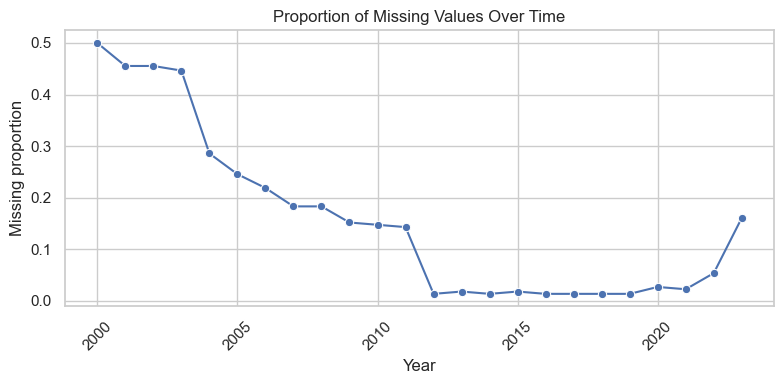

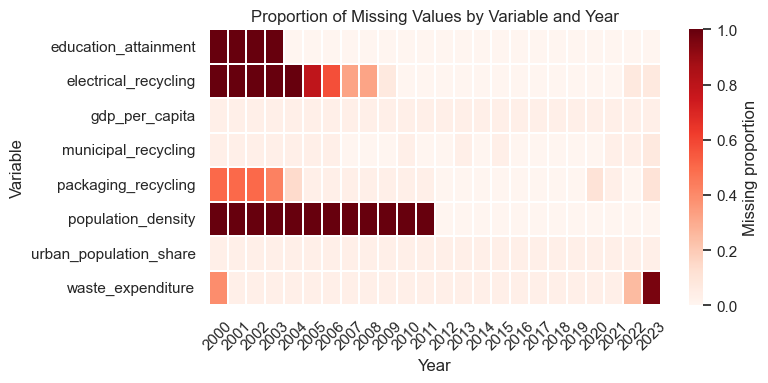

In [409]:
df_long = df_merged.melt(
    id_vars=["country", "year"],
    var_name="variable",
    value_name="value"
)
missing_by_year = (
    df_long
    .groupby("year")["value"]
    .apply(lambda x: x.isna().mean())
    .reset_index(name="missing")
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.lineplot(
    data=missing_by_year,
    x="year",
    y="missing",
    marker="o"
)

plt.title("Proportion of Missing Values Over Time")
plt.xlabel("Year")
plt.ylabel("Missing proportion")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

missing_var_year = (
    df_long
    .groupby(["variable", "year"])["value"]
    .apply(lambda x: x.isna().mean())
    .reset_index(name="missing")
)
heatmap_var_year = missing_var_year.pivot(
    index="variable",
    columns="year",
    values="missing"
)
plt.figure(figsize=(8, 4))

sns.heatmap(
    heatmap_var_year,
    cmap="Reds",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Missing proportion"}
)

plt.title("Proportion of Missing Values by Variable and Year")
plt.xlabel("Year")
plt.ylabel("Variable")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [410]:
missing_by_year = (
    df_merged
    .groupby("year")
    .apply(lambda x: x.isna().mean().mean() * 100)
)

missing_by_year

year
2000    40.000000
2001    36.428571
2002    36.428571
2003    35.714286
2004    22.857143
2005    19.642857
2006    17.500000
2007    14.642857
2008    14.642857
2009    12.142857
2010    11.785714
2011    11.428571
2012     1.071429
2013     1.428571
2014     1.071429
2015     1.428571
2016     1.071429
2017     1.071429
2018     1.071429
2019     1.071429
2020     2.142857
2021     1.785714
2022     4.285714
2023    12.857143
dtype: float64

By the two plots above it is clear, that the variales are not missing at random, but mostly either at the beginning or at the end of the time series. This could be because some variables were only started to be measured after a certain time point or for the end of the series the value might not have been reported yet.
In 200 nearly half of all the values were missing, as 5 variables only started to be measured later.  

In a second step we analyzed the missings by country, which can be seen below.

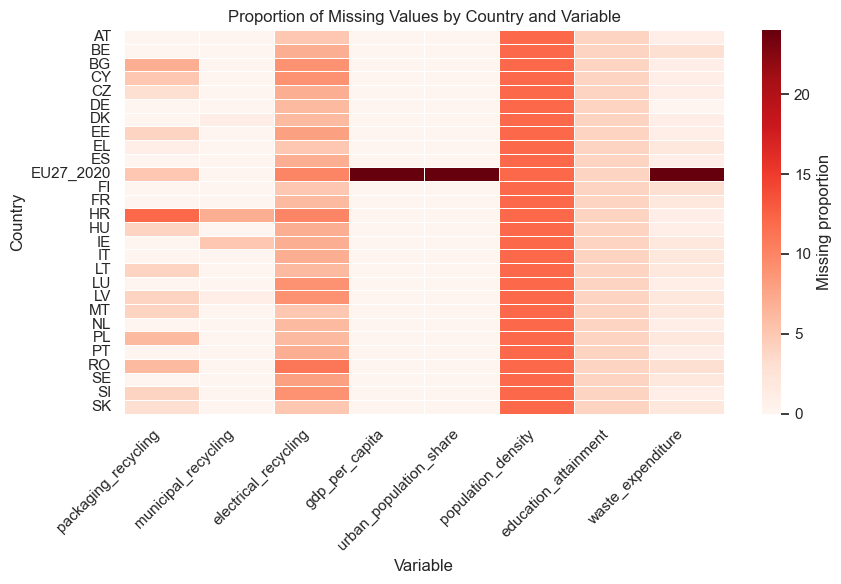

In [411]:
missing_by_country = (
    df_merged
    .groupby("country")
    .apply(lambda x: x.isna().sum())
)
missing_by_country = missing_by_country.drop(["country", "year"], axis = 1)
missing_by_country

plt.figure(figsize=(9, 6))
sns.heatmap(
    missing_by_country,
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Missing proportion"}
)

plt.title("Proportion of Missing Values by Country and Variable")
plt.xlabel("Variable")
plt.ylabel("Country")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [412]:
missing_by_country = (
    df_merged
    .groupby("country")
    .apply(lambda x: x.isna().mean().mean() * 100)
    .sort_values(ascending=False)
)

missing_by_country.head(10)

country
EU27_2020    42.916667
HR           19.166667
RO           15.000000
BG           13.750000
LV           13.333333
CY           12.916667
SI           12.500000
IE           12.500000
PL           12.500000
EE           12.083333
dtype: float64

Based on the plot above plot, it can be seen that most countries have a similar amount of missing values per variable. The biggest difference is in packaging recycling. This is probably since it was not recorded for all countries at the beginning as could be seen in the plot from before. EU27_2020 somethimes has a high number of missings, but that is because the aggregate values does not exist for all of the variables.
Croatia and Romania are the countries with the highest amout of missing values. These two countries along with some others on the top of the list were some of the last countries to join the EU. This might be one reason, why before it was not reported so much.

## 4.7. Data Transformation
waste_expenditure was transformed since it was given in decimals while all other percentage variables were given in percentage directly. This way all variables are uniform. Otherwise, no data transformation was needed.

In [413]:
df_merged['waste_expenditure'] = df_merged['waste_expenditure']*100
df_merged_all['waste_expenditure'] = df_merged_all['waste_expenditure']*100

In [414]:
df_merged

,country,year,packaging_recycling,municipal_recycling,electrical_recycling,gdp_per_capita,urban_population_share,population_density,education_attainment,waste_expenditure
0,AT,2000,69.4,63.4,NaN,53599.610,60.213,NaN,NaN,5.562567
1,AT,2001,64.3,64.3,NaN,54098.027,59.934,NaN,NaN,5.696860
2,AT,2002,65.9,62.5,NaN,54631.600,59.655,NaN,NaN,5.821767
3,AT,2003,64.2,64.2,NaN,54986.742,59.375,NaN,NaN,5.681384
4,AT,2004,66.2,57.4,NaN,56048.480,59.094,NaN,15.8,5.112889
...,...,...,...,...,...,...,...,...,...,...
667,SK,2019,67.5,38.5,91.2,37194.137,53.729,112.0,23.1,34.564973
668,SK,2020,70.8,45.3,92.6,36201.414,53.760,112.0,23.9,46.338775
669,SK,2021,73.9,48.9,92.5,38346.094,53.820,112.1,24.7,36.495568
670,SK,2022,71.8,49.5,90.9,38623.670,53.909,111.5,26.0,37.664891


## 4.8. Analyzing outliers

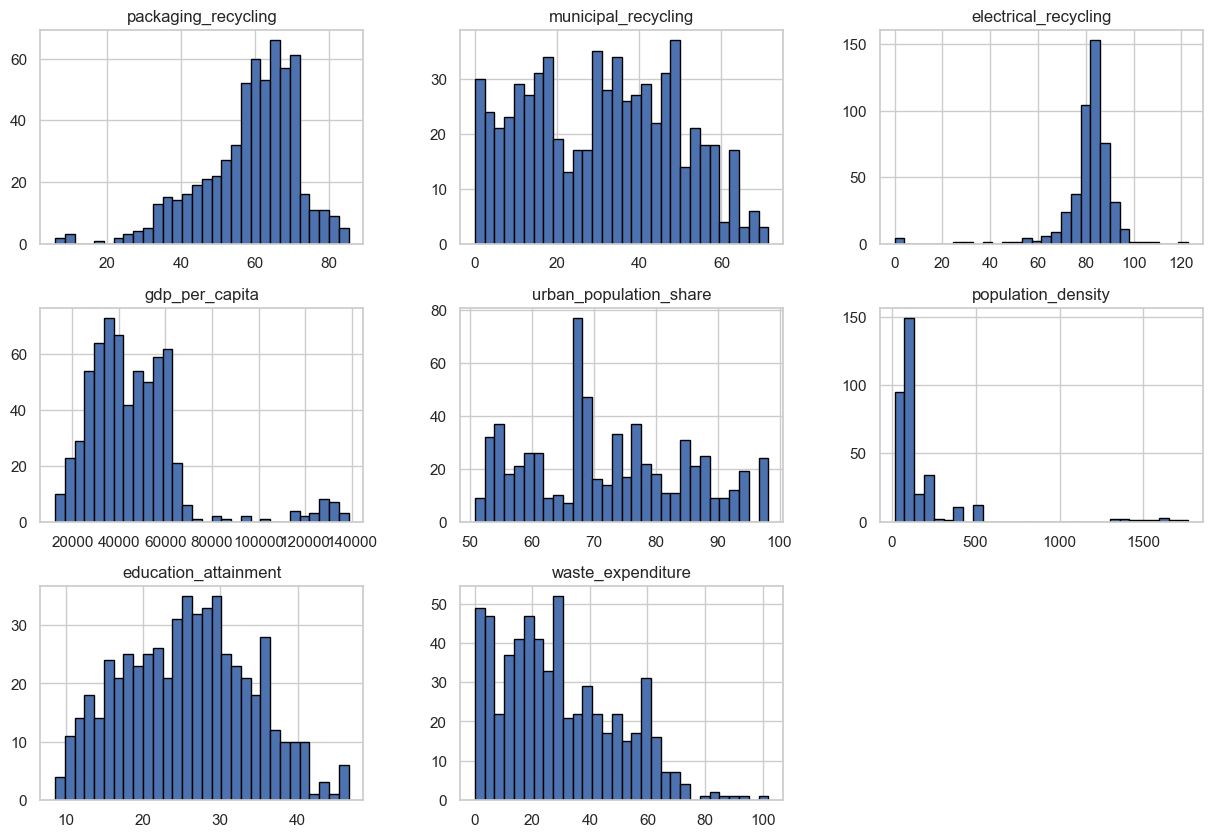

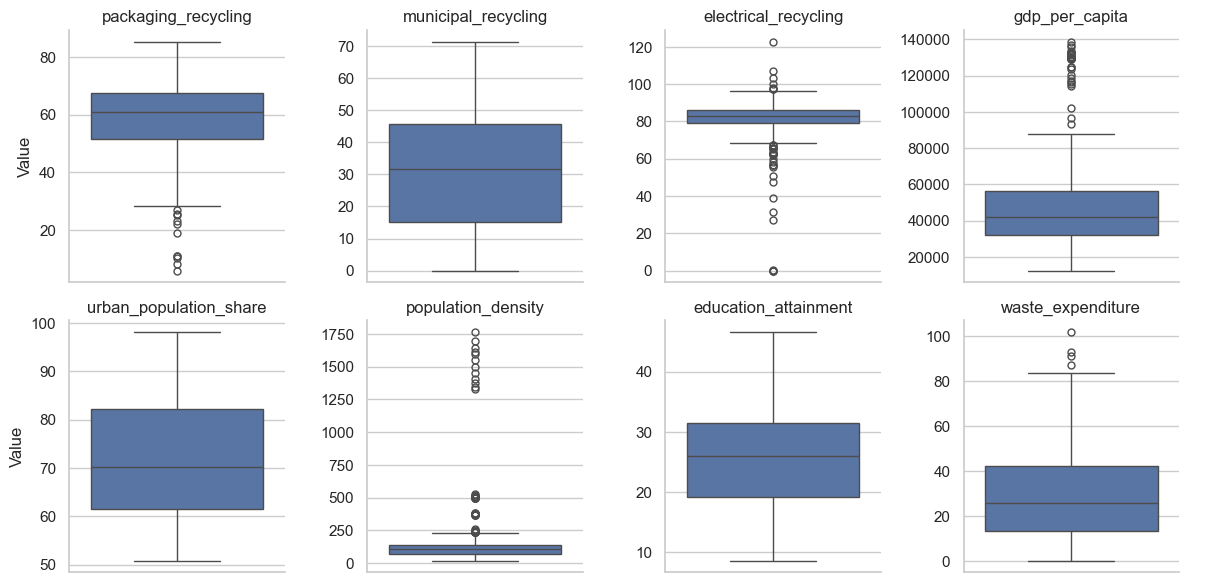

In [415]:
numeric_vars = (
    df_merged
    .select_dtypes(include=[np.number])
    .drop(["year"], axis = 1)
)
numeric_vars.hist(
    bins=30,
    figsize=(15, 10),
    edgecolor="black"
);

df_long = df_merged.melt(
    value_vars=numeric_vars,
    var_name="variable",
    value_name="value"
)

g = sns.catplot(
    data=df_long,
    y="value",
    kind="box",
    col="variable",
    col_wrap=4,
    sharey=False,
    height=3
)

g.set_titles("{col_name}")
g.set_axis_labels("", "Value")

# REMOVE x-axis
for ax in g.axes.flat:
    ax.set_xticks([])
    ax.set_xlabel("")

As we can see in the boxplots, all variables have some outliers. Most of them still seem reasonable, but for recycling of electrical waste, lead batteries and vahocales the numbers go above 100% which should be further analyzed.

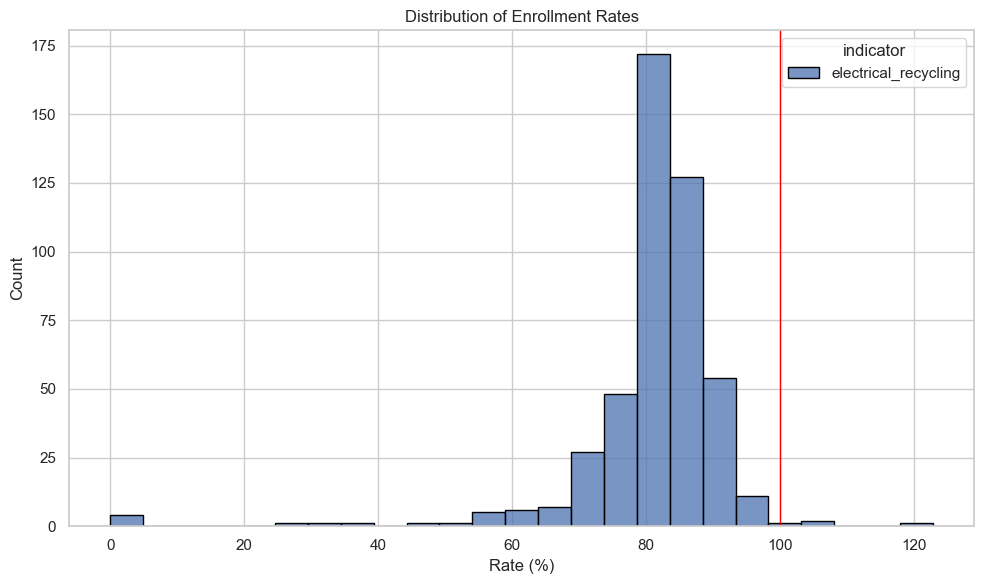

In [416]:
rate_indicators = ["electrical_recycling"]

rates_long = df_merged.melt(
    id_vars=[],                 
    value_vars=rate_indicators, 
    var_name="indicator",
    value_name="value"
)
rates_long["indicator"] = rates_long["indicator"].astype(str)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=rates_long,
    x="value",
    hue="indicator",
    multiple="dodge",
    binwidth=5,
    edgecolor="black",
    legend=True  
)

# Vertical line at 100
plt.axvline(x=100, color="red", linewidth=1, linestyle="solid")

plt.title("Distribution of Enrollment Rates")
plt.xlabel("Rate (%)")
plt.ylabel("Count")


plt.tight_layout()
plt.show()


In [417]:

countries_over_100_elec = df_merged.loc[
    df_merged["electrical_recycling"] > 100,
    ["country", "year", "electrical_recycling"]
].sort_values("electrical_recycling", ascending=False)
print("Electrical recycling")
print(df_merged[df_merged["electrical_recycling"] > 100].groupby("country").size().sort_values(ascending=False))
print(countries_over_100_elec)

Electrical recycling
country
MT    3
dtype: int64
    country  year  electrical_recycling
491      MT  2011                 122.8
494      MT  2014                 107.1
496      MT  2016                 103.4


For recycling of electrical waste only Malta has values higher than 100%.  
For recycling of batteries only hungary has higher values than 100%.  
And for vehicle recycling Czechia, poland and Slovenia have higher values then 100%.

| Metric | Typical Range | Trend | Stability |
| :--- | :--- | :--- | :--- |
| **Municipal** | 10% – 70% | Consistent Growth | High |
| **Packaging** | 40% – 85% | Stagnant / Fluctuating | Moderate |
| **E-Waste** | 60% – 100%+ | High but Volatile | Low (Data Outliers) |
 
There is one country showing an E-Waste recycling rate of 120%. This is due to the hoarding effect.

In [418]:
outlier_summary = {}

for col in numeric_vars.columns:
    Q1 = df_merged[col].quantile(0.25)
    Q3 = df_merged[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_merged[(df_merged[col] < lower) | (df_merged[col] > upper)]

    outlier_summary[col] = {
        "n_outliers": outliers.shape[0],
        "percent": outliers.shape[0] / df_merged.shape[0] * 100
    }
display(outlier_summary)

#-----#
z_scores = df_merged[numeric_vars.columns].apply(zscore)
z_outliers = (z_scores.abs() > 3)
z_outlier_counts = z_outliers.sum().sort_values(ascending=False)
print(z_outlier_counts)


summary_stats = df_merged[numeric_vars.columns].agg(
    ["mean", "median"]
).T

print(summary_stats)


{'packaging_recycling': {'n_outliers': 11, 'percent': 1.636904761904762},
 'municipal_recycling': {'n_outliers': 0, 'percent': 0.0},
 'electrical_recycling': {'n_outliers': 33, 'percent': 4.910714285714286},
 'gdp_per_capita': {'n_outliers': 30, 'percent': 4.464285714285714},
 'urban_population_share': {'n_outliers': 0, 'percent': 0.0},
 'population_density': {'n_outliers': 48, 'percent': 7.142857142857142},
 'education_attainment': {'n_outliers': 0, 'percent': 0.0},
 'waste_expenditure': {'n_outliers': 4, 'percent': 0.5952380952380952}}

packaging_recycling       0
municipal_recycling       0
electrical_recycling      0
gdp_per_capita            0
urban_population_share    0
population_density        0
education_attainment      0
waste_expenditure         0
dtype: int64
                                mean       median
packaging_recycling        58.722000     61.00000
municipal_recycling        30.871277     31.80000
electrical_recycling       81.218723     82.70000
gdp_per_capita          46426.745449  42238.86500
urban_population_share     72.262645     70.18550
population_density        176.234524    105.75000
education_attainment       25.678214     25.95000
waste_expenditure          28.998058     25.60555


Outliers were examined using both the 1.5×IQR criterion and z-scores. The IQR method identified several extreme observations, while no observations exceeded ±3 standard deviations. This discrepancy reflects skewed and heavy-tailed distributions, which inflate the standard deviation and reduce the sensitivity of z-scores. As the identified values were plausible and consistent with distributional patterns, all observations were retained.
The mean and the median differens alot for population_density, otherwise the values are similar, meaning that population density has high outliers.

## 4.9. Correlation-Analysis

To gain an initial overview of the relationships between variables, pooled Pearson correlations are computed using all available country–year observations. These correlations reflect average associations across EU countries and years, without accounting for country-specific or time-specific effects.

In addition, pairwise correlations between the predictor variables used in later analysis are examined to assess potential multicollinearity and to better understand the relationships among the explanatory variables. For this purpose, correlations are calculated separately within each country using over-time variation and are then summarized across countries. High correlations may indicate redundant information among predictors.
Absolute correlation coefficients are used to assess the strength of associations between predictors, as the objective is to identify potential multicollinearity. Averaging signed correlations could mask strong but oppositely signed relationships across countries.

##  4.9.1.Pooled Pearson Correlations

                        packaging_recycling  municipal_recycling  \
packaging_recycling                1.000000             0.719617   
municipal_recycling                0.719617             1.000000   
electrical_recycling               0.337610             0.179969   
urban_population_share             0.236743             0.361476   
education_attainment               0.431705             0.472820   
waste_expenditure                 -0.082956            -0.128881   
population_density                -0.310562            -0.135265   

                        electrical_recycling  urban_population_share  \
packaging_recycling                 0.337610                0.236743   
municipal_recycling                 0.179969                0.361476   
electrical_recycling                1.000000               -0.154873   
urban_population_share             -0.154873                1.000000   
education_attainment                0.136545                0.401644   
waste_expenditure      

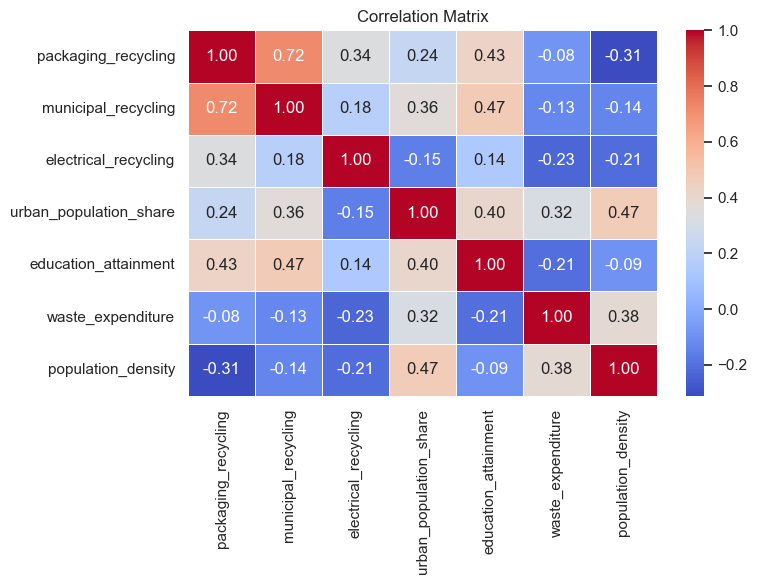

In [419]:

selected_vars = [
    "packaging_recycling", "municipal_recycling", "electrical_recycling", 
    "urban_population_share", "education_attainment", "waste_expenditure", "population_density"
]
corr = df_merged[selected_vars].corr()
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()




The correlation analysis shows the following:
- Packaging and municipal recycling are strongly correlated (r ≈ 0.72), suggesting that countries that perform well in one type tend to perform well in the other.

- Packaging and municipal recycling are also positively correlated with higher GDP per capita, higher education attainment, and higher urban population share.
    - For example, packaging recycling correlates with GDP per capita (r ≈ 0.36), education (r ≈ 0.43), and urban population share (r ≈ 0.24).
    - Municipal recycling shows even stronger correlations with GDP (r ≈ 0.60), education (r ≈ 0.47), and urban population (r ≈ 0.36).

- Population density shows a negative correlation with packaging (r ≈ -0.31) and electrical recycling (r ≈ -0.21), suggesting that denser countries tend to recycle less in these categories.

- Waste expenditure does not show strong correlations with any of the recycling types.

- Furthermore, explanatory variables are themselves correlated. GDP per capita, education attainment, and urban population share are positively correlated with each other.


## 4.9.2.Mean Predictor Correlations


Pairwise Correlation Summary (across all countries):

Variable 1                Variable 2                Mean |r|   High in % of countries
urban_population_share    education_attainment      0.92            85.19%
gdp_per_capita            urban_population_share    0.83            55.56%
gdp_per_capita            education_attainment      0.83            66.67%
population_density        education_attainment      0.81            66.67%
urban_population_share    population_density        0.80            66.67%
gdp_per_capita            population_density        0.79            59.26%
urban_population_share    waste_expenditure         0.42             7.41%
gdp_per_capita            waste_expenditure         0.41             3.70%
population_density        waste_expenditure         0.40             3.70%
waste_expenditure         education_attainment      0.40             3.70%


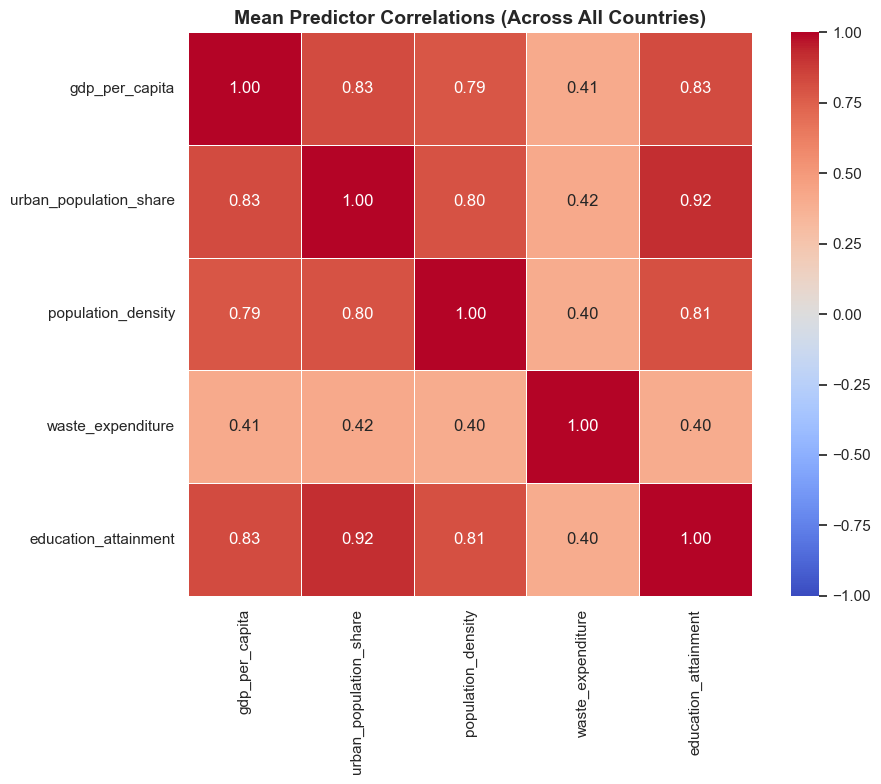

In [420]:

selected_predictors = ['gdp_per_capita', 'urban_population_share', 'population_density',  'waste_expenditure', 'education_attainment']  
# drop rows with missing keys and set MultiIndex
panel_df = df_merged.dropna(subset=['country', 'year']).copy()
panel_df = panel_df.loc[panel_df['country'] != 'EU27_2020']  # Exclude EU aggregate
panel_df['year'] = panel_df['year'].astype(int)
panel_df = panel_df.set_index(['country', 'year']).sort_index()
panel_df.head(3)

# Threshold for "high correlation"
CORR_THRESHOLD = 0.80

country_correlations = {}
# Extract unique countries from the MultiIndex (first level)
for country in panel_df.index.get_level_values(0).unique():
    country_data = panel_df.loc[country, selected_predictors].dropna() 
    if len(country_data) > 1:  # Need at least 2 observations for corr.
        country_correlations[country] = country_data.corr()

# Extract all unique pairs
all_pairs = {}
for i in range(len(selected_predictors)):
    for j in range(i+1, len(selected_predictors)):
        var1 = selected_predictors[i]
        var2 = selected_predictors[j]
        pair_key = (var1, var2)
        all_pairs[pair_key] = []

# Collect correlation values for each pair across all countries
for country, corr_mat in country_correlations.items():
    for i in range(len(selected_predictors)):
        for j in range(i+1, len(selected_predictors)):
            var1 = selected_predictors[i]
            var2 = selected_predictors[j]
            pair_key = (var1, var2)
            r = abs(corr_mat.loc[var1, var2])
            all_pairs[pair_key].append(r)


print("\nPairwise Correlation Summary (across all countries):\n")
print(f"{'Variable 1':<25} {'Variable 2':<25} {'Mean |r|':<10} {'High in % of countries':<10}")

high_corr_pairs = []

for (var1, var2), corr_values in sorted(all_pairs.items(), key=lambda x: np.mean(x[1]), reverse=True):
    mean_r = np.mean(corr_values)
    pct_high = 100 * sum(1 for r in corr_values if r > CORR_THRESHOLD) / len(corr_values)
    
    print(f"{var1:<25} {var2:<25} {mean_r:<10.2f} {pct_high:10.2f}%")


# Draw mean coorrelation heatmap
mean_corr_matrix = pd.DataFrame(0.0, index=selected_predictors, columns=selected_predictors)
for (var1, var2), corr_values in all_pairs.items():
    mean_r = np.mean(corr_values)
    mean_corr_matrix.loc[var1, var2] = mean_r
    mean_corr_matrix.loc[var2, var1] = mean_r

# Fill diagonal
for v in selected_predictors:
    mean_corr_matrix.loc[v, v] = 1.0

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(mean_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Mean Predictor Correlations (Across All Countries)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The pairwise correlation analysis across EU countries shows that many socio-economic predictors are strongly related within countries over time. In particular, the following variables are highly correlated:
- Urban population share and education attainment (|r| = 0.92, high in 85% of countries)
- GDP per capita and urban population (|r| = 0.83) 
- GDP per capita and education attainment (|r| = 0.83)
- Population density and education attainment (|r| = 0.81)
- Population density and urban population share (|r| = 0.80)
- Population density and GDP per capita (|r| = 0.79)

In contrast, waste expenditure shows relatively weak correlations with the other predictors. 
These results indicate that many of the country-level characteristics are closely related.

Why these correlations are higher than pooled correlations:
These correlations were calculated within each country over time and then averaged across countries using absolute values. This preserves the strength of associations even if the direction of correlation differs across countries, and avoids cancellation of opposing trends. 

# 5. Treating of missing values and outliers  
All identified outliers could be plausibly explained and were therefore not treated or removed from the dataset. Instead, they were retained in their original form.

Missing values were handled depending on their position within the time series. When values were missing in the middle of a series, linear interpolation was applied. For missing values at the beginning or end of a time series, backward and forward filling was used. While backward and forward filling can introduce bias, the gaps in the data were generally short, making this a practical and simple solution.

For the waste-related variables, missing values were not imputed. Imputing these values could have introduced artificial patterns, which would be problematic given that these variables are later used for prediction.

In [421]:
num_cols = [
    'gdp_per_capita',
    'urban_population_share',
    'population_density',
    'education_attainment',
    'waste_expenditure'
]
df_merged_miss = df_merged.copy()

# Interpolations if some variables are missing in the middle of the time series
df_merged_miss[num_cols] = df_merged_miss.groupby("country")[num_cols].transform(
    lambda x: x.interpolate(method="linear", limit_area="inside")
)
#Forward and backwardsfill
df_merged_miss[num_cols] = df_merged_miss.groupby("country")[num_cols].bfill()
df_merged_miss[num_cols] = df_merged_miss.groupby("country")[num_cols].ffill()

df_merged_miss_all = df_merged_all.copy()

# Interpolations if some variables are missing in the middle of the time series
df_merged_miss_all[num_cols] = df_merged_miss_all.groupby("country")[num_cols].transform(
    lambda x: x.interpolate(method="linear", limit_area="inside")
)
#Forward and backwardsfill
df_merged_miss_all[num_cols] = df_merged_miss_all.groupby("country")[num_cols].bfill()
df_merged_miss_all[num_cols] = df_merged_miss_all.groupby("country")[num_cols].ffill()



# 6. Recycling Development

## 6.1. How has the amount of recycling of waste developed in the EU overall over time?
 
 
To answer this question comprehensively, we analyze the **EU27_2020 aggregate** (representing the 27-member European Union in its current composition) along two key dimensions:
 
1. **Efficiency (Recycling Rates in %)**: How effectively is waste being recycled? We examine three waste streams:
   - **Municipal Waste**: Household and similar commercial waste
   - **Packaging Waste**: Materials like paper, glass, metal, and plastic packaging
   - **E-Waste**: Electronic equipment waste (treatment efficiency of collected devices)
 
2. **Absolute Volume (Mass in Tonnes)**: What is the actual composition of waste treatment? We track:
   - **Recycling** (material recovery + composting) – most desirable
   - **Energy Recovery** (incineration with heat/electricity generation) – recovery operation
   - **Incineration** (without energy recovery) – disposal
   - **Landfill** – least desirable disposal method
   - **Waste Treatment** the overall treatment of waste
   - **Waste Generation** the overall generation of waste
 
 
**Methodological Note on Data Measurement:** For packaging waste, Eurostat implemented a stricter measurement methodology starting from reference year 2020. This change results in lower but more accurate recycling rates.
- Packaging waste by waste management operations (env_waspac):  
  https://ec.europa.eu/eurostat/cache/metadata/en/env_waspac_esms.htm
 
 
 
 
 
Packaging waste by waste management operations (env_waspac)

First we analyze the development by plots before using a kruskal-wallis test and a spearman test.
 

,geo,TIME_PERIOD,recycling_rate_municipal_pc,flag_municipal,recycling_rate_packaging_pc,flag_packaging,recycling_rate_ewaste_pc,flag_ewaste,waste_incinerated_kg_capita,waste_incinerated_tonnes,...,waste_energy_recovery_kg_capita,waste_energy_recovery_tonnes,waste_recycled_total_kg_capita,waste_recycled_total_tonnes,waste_composted_kg_capita,waste_composted_tonnes,waste_recycled_material_kg_capita,waste_recycled_material_tonnes,waste_treated_total_kg_capita,waste_treated_total_tonnes
0,EU27_2020,2000,27.3,i,NaN,NaN,NaN,NaN,37.0,16076.0,...,47.0,20009.0,140.0,60174.0,53.0,22656.0,87.0,37518.0,486.0,208655.0
1,EU27_2020,2001,28.7,i,NaN,NaN,NaN,NaN,37.0,16054.0,...,49.0,21096.0,146.0,62744.0,54.0,23148.0,92.0,39596.0,483.0,207300.0
2,EU27_2020,2002,30.4,i,NaN,NaN,NaN,NaN,38.0,16276.0,...,52.0,22267.0,157.0,67437.0,57.0,24470.0,100.0,42967.0,488.0,209929.0
3,EU27_2020,2003,31.1,i,NaN,NaN,NaN,NaN,36.0,15505.0,...,54.0,23166.0,156.0,67560.0,57.0,24437.0,100.0,43123.0,475.0,205106.0
4,EU27_2020,2004,31.8,i,NaN,NaN,NaN,NaN,38.0,16390.0,...,58.0,24947.0,159.0,68997.0,59.0,25550.0,100.0,43447.0,469.0,203368.0
5,EU27_2020,2005,32.5,i,54.7,i,NaN,NaN,41.0,17997.0,...,61.0,26635.0,164.0,71598.0,59.0,25702.0,105.0,45896.0,469.0,204088.0
6,EU27_2020,2006,33.2,i,56.8,i,NaN,NaN,41.0,17885.0,...,70.0,30513.0,170.0,74239.0,61.0,26802.0,109.0,47437.0,482.0,210674.0
7,EU27_2020,2007,35.2,NaN,59.1,i,NaN,NaN,37.0,16235.0,...,75.0,32729.0,182.0,79817.0,64.0,27861.0,119.0,51956.0,493.0,216041.0
8,EU27_2020,2008,36.6,NaN,60.4,i,NaN,NaN,36.0,15822.0,...,80.0,35079.0,189.0,83147.0,69.0,30385.0,120.0,52762.0,495.0,217522.0
9,EU27_2020,2009,37.3,NaN,62.6,i,NaN,NaN,35.0,15553.0,...,82.0,36166.0,190.0,83803.0,67.0,29516.0,123.0,54287.0,493.0,217266.0


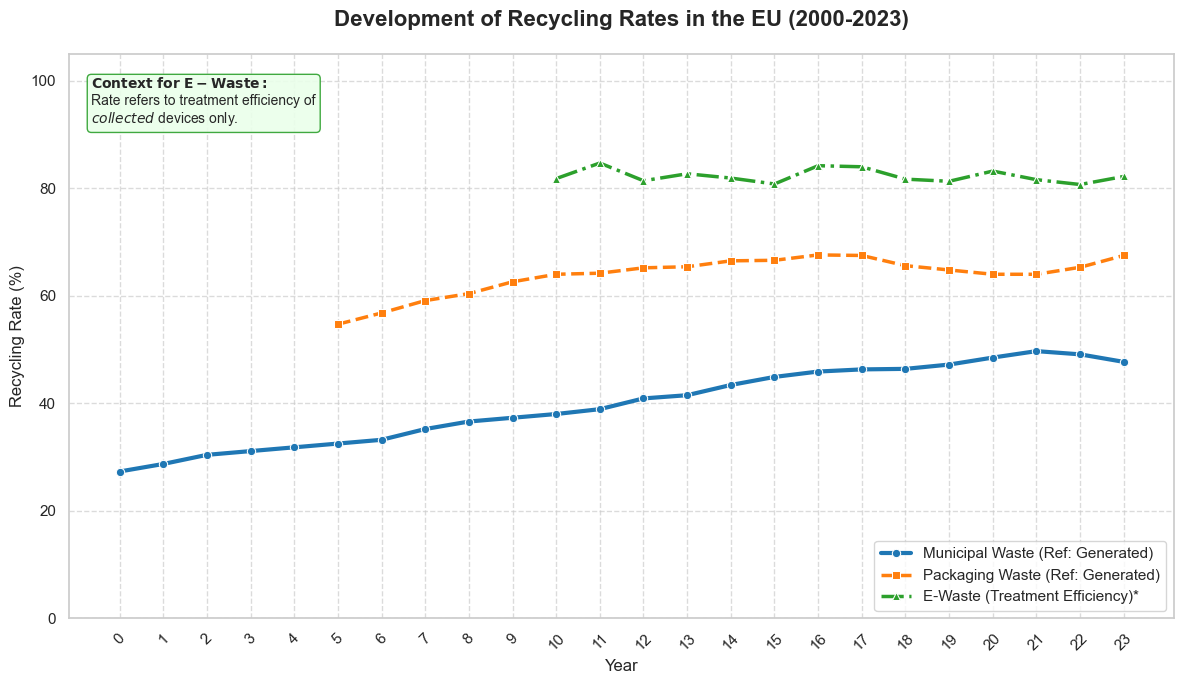

In [422]:
# Final waste dataset narrowed down to EU27
df_final_copy = df_final_waste.copy()
df_final_waste_eu_27 = df_final_copy.loc[['EU27_2020']].copy().reset_index()
display(df_final_waste_eu_27)
 
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
 
 
# 1. Municipal Waste
sns.lineplot(ax=ax, data=df_final_waste_eu_27, x=df_final_waste_eu_27.index, y='recycling_rate_municipal_pc',
             label='Municipal Waste (Ref: Generated)', color='#1f77b4', linewidth=3, marker='o')
 
# 2. Packaging Waste
sns.lineplot(ax=ax, data=df_final_waste_eu_27, x=df_final_waste_eu_27.index, y='recycling_rate_packaging_pc',
             label='Packaging Waste (Ref: Generated)', color='#ff7f0e', linewidth=2.5, linestyle='--', marker='s')
 
# 3. E-Waste
sns.lineplot(ax=ax, data=df_final_waste_eu_27, x=df_final_waste_eu_27.index, y='recycling_rate_ewaste_pc',
             label='E-Waste (Treatment Efficiency)*', color='#2ca02c', linewidth=2.5, linestyle='-.', marker='^')
 
 
ax.set_title('Development of Recycling Rates in the EU (2000-2023)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Recycling Rate (%)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylim(0, 105) # Etwas Platz oben für die Textbox
ax.grid(True, linestyle='--', alpha=0.7)
 
# X-Axis: Show every year
ax.set_xticks(df_final_waste_eu_27.index)
ax.set_xticklabels(df_final_waste_eu_27.index, rotation=45)
 
# Box for explanation of the E-Waste rate
textstr = (
    r'$\bf{Context\ for\ E-Waste:}$' + '\n'
    'Rate refers to treatment efficiency of\n'
    r'$\it{collected}$ devices only.'
)
props = dict(boxstyle='round', facecolor='#eaffea', alpha=0.9, edgecolor='#2ca02c')
ax.text(0.02, 0.96, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
 
# Legend positioning
ax.legend(loc='lower right', fontsize=11, frameon=True)
 
plt.tight_layout()
plt.show()

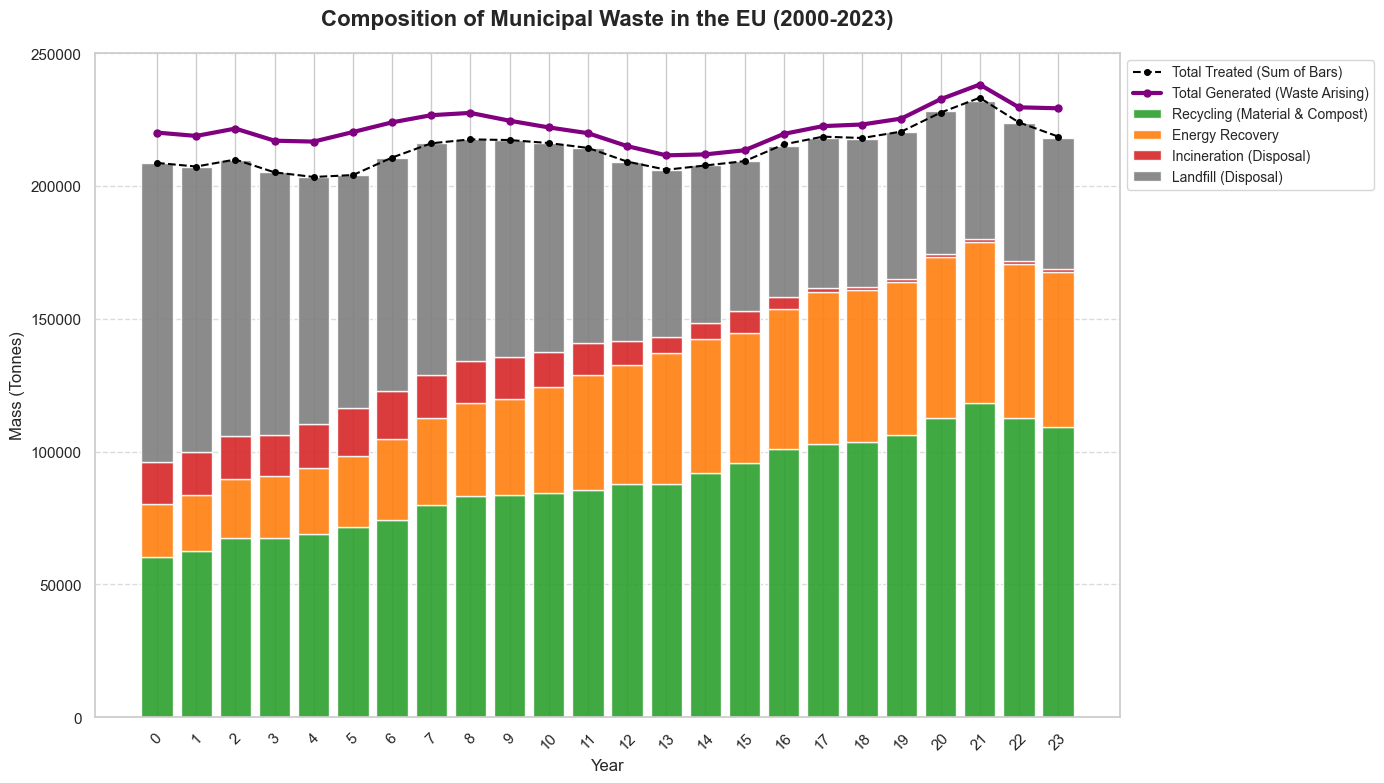

Detailed table: treatment shares (%)


,Recycling (%),Energy Recovery (%),Incineration (%),Landfill (%),Total Treated (Tonnes)
TIME_PERIOD,,,,,
2000,28.8,9.6,7.7,53.9,208655
2001,30.3,10.2,7.7,51.8,207300
2002,32.1,10.6,7.8,49.5,209929
2003,32.9,11.3,7.6,48.2,205106
2004,33.9,12.3,8.1,45.7,203368
2005,35.1,13.1,8.8,43.0,204088
2006,35.2,14.5,8.5,41.8,210674
2007,36.9,15.1,7.5,40.4,216041
2008,38.2,16.1,7.3,38.4,217522


In [423]:

# 1. Setup Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))
 
# 2. Prepare Data
years = df_final_waste_eu_27.index
rec = df_final_waste_eu_27['waste_recycled_total_tonnes'].fillna(0)
energy = df_final_waste_eu_27['waste_energy_recovery_tonnes'].fillna(0)
incineration = df_final_waste_eu_27['waste_incinerated_tonnes'].fillna(0)
landfill = df_final_waste_eu_27['waste_landfill_tonnes'].fillna(0)
total_treated = df_final_waste_eu_27['waste_treated_total_tonnes']
total_generated = df_final_waste_eu_27['waste_generated_tonnes']
 
# 3. Plotting: Stacked Bars
p1 = ax.bar(years, rec, label='Recycling (Material & Compost)', color='#2ca02c', alpha=0.9, edgecolor='white')
p2 = ax.bar(years, energy, bottom=rec, label='Energy Recovery', color='#ff7f0e', alpha=0.9, edgecolor='white')
p3 = ax.bar(years, incineration, bottom=rec+energy, label='Incineration (Disposal)', color='#d62728', alpha=0.9, edgecolor='white')
p4 = ax.bar(years, landfill, bottom=rec+energy+incineration, label='Landfill (Disposal)', color='#7f7f7f', alpha=0.9, edgecolor='white')
 
# 4. Plotting: Reference Lines
ax.plot(years, total_treated, color='black', linestyle='--', linewidth=1.5, marker='o', markersize=4,
        label='Total Treated (Sum of Bars)')
ax.plot(years, total_generated, color='purple', linestyle='-', linewidth=3, marker='o', markersize=5,
        label='Total Generated (Waste Arising)')
 
# 5. Formatting
ax.set_title('Composition of Municipal Waste in the EU (2000-2023)', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Mass (Tonnes)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend(loc='upper left', fontsize=10, frameon=True, bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
 
plt.tight_layout()
plt.show()
 
 
# 1) Set index and clean

df_final_waste_eu_27.set_index('TIME_PERIOD', inplace=True)
df_final_waste_eu_27.index = pd.to_numeric(df_final_waste_eu_27.index, errors='coerce')
df_final_waste_eu_27.sort_index(inplace=True)
 
# 2) Define tonnes columns
cols_mass = [
    'waste_recycled_total_tonnes',
    'waste_energy_recovery_tonnes',
    'waste_incinerated_tonnes',
    'waste_landfill_tonnes'
]
 
# 3) Define total tonnes
total_col = 'waste_treated_total_tonnes'
 
# 4) Create result table
df_table = pd.DataFrame(index=df_final_waste_eu_27.index)
 
# 5) Calculate shares (%)
labels = ['Recycling (%)', 'Energy Recovery (%)', 'Incineration (%)', 'Landfill (%)']
 
for col, label in zip(cols_mass, labels):
    df_table[label] = (df_final_waste_eu_27[col] / df_final_waste_eu_27[total_col]) * 100
 
# 6) Round values
df_table = df_table.round(1)
 
# 7) Add total tonnes
df_table['Total Treated (Tonnes)'] = df_final_waste_eu_27[total_col].round(0).astype('Int64', errors='ignore')
 
# 8) Show table
print("Detailed table: treatment shares (%)")
display(df_table)

# 9) Reset index
df_final_waste_eu_27.reset_index(inplace=True)

#10) Save table
df_table.to_csv("data/df_table_eu_27.csv", sep=",", index=True)


 
 
 

In [424]:
def plot_mean_std(metric_col: str, title: str):
    """
    Plot yearly mean ±1 std across EU countries (excl. EU27_2020) for the given metric column.
    """
    df_plot = df_final_waste.reset_index().query("geo != 'EU27_2020'").copy()
    df_plot["TIME_PERIOD"] = df_plot["TIME_PERIOD"].astype("Int64")

    stats = (
        df_plot.groupby("TIME_PERIOD")[metric_col]
        .agg(["mean", "std"])
        .reset_index()
    )
    stats['EU27_2020'] = df_final_waste.reset_index().query("geo == 'EU27_2020'")[['TIME_PERIOD', metric_col]].set_index('TIME_PERIOD')[metric_col].values


    plt.figure(figsize=(10, 5))
    sns.lineplot(data=stats, x="TIME_PERIOD", y="mean", marker="o", color="blue", label="Mean")
    sns.lineplot(data=stats, x="TIME_PERIOD", y="EU27_2020", marker="o", color="red", label="EU27_2020")
    plt.fill_between(
        stats["TIME_PERIOD"],
        stats["mean"] - stats["std"],
        stats["mean"] + stats["std"],
        color="blue",
        alpha=0.2,
        label="±1 std"
    )
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel("Recycling Rate (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

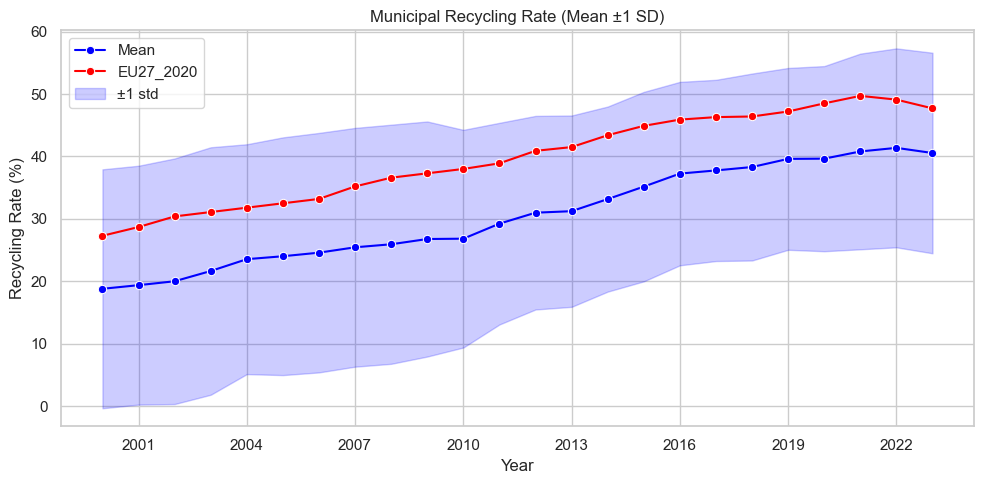

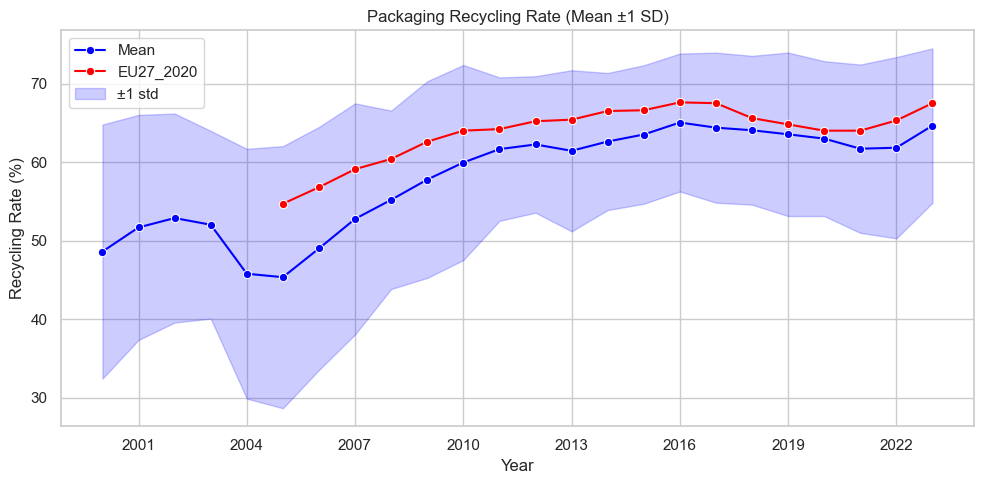

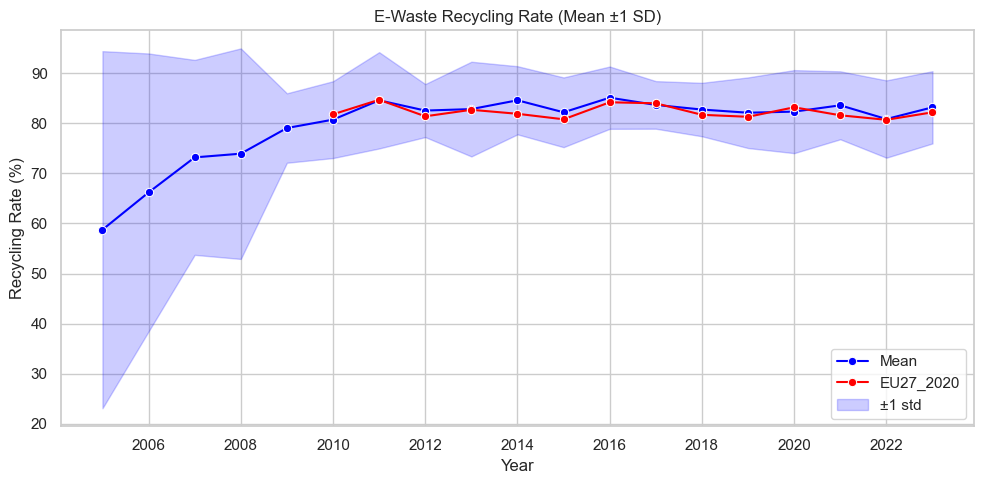

In [425]:
plot_mean_std("recycling_rate_municipal_pc", "Municipal Recycling Rate (Mean ±1 SD)")
plot_mean_std("recycling_rate_packaging_pc", "Packaging Recycling Rate (Mean ±1 SD)")
plot_mean_std("recycling_rate_ewaste_pc", "E-Waste Recycling Rate (Mean ±1 SD)")

## Analysis:

- **Municipal waste (blue line)**  
  The municipal recycling rate in the EU27_2020 increased steadily from **27.3% in 2000 to 47.7% in 2023**, but growth has slowed and plateaued in recent years.

- **Packaging waste (orange line)**  
  For packaging waste, the recycling rate rose from **54.7% in 2005 to 67.5% in 2023**, which reflects well‑established collection systems for packaging materials.

- **E‑waste (green line)**  
  The e‑waste indicator shows a **high and stable reuse and recycling rate of separately collected waste**, fluctuating only between **80.7% and 84.7% during 2010–2023**,  meaning that most of the e‑waste that reaches official collection and treatment facilities is successfully prepared for recycled. There is no trend or big changes over the years. (Important the e-waste rate does only show the reuse of collected e-waste, not the reuse of e-waste that is not collected. Therefore is the remark in the plot.)

- **Time series line plots for municipal waste treatment, packaging waste treatment and e-waste treatment** show that for municipal and packaging waste the eu27_2020 recycling rate is constantly higher than the mean. For e-waste the eu27_2020 is really close to the mean. For municipal waste and for packaging waste the standard deviation is also higher than for e-waste. This means that the municipal and packaging waste recycling rate is more variable than the e-waste recycling rate.

- **Total municipal waste treatment**  
  The stacked bars and table for municipal waste reveal a **strong structural shift in treatment methods**. The share of **recycling and energy recovery together increased from 38.4% of treated waste in 2000 to 76.6% in 2023**, while **landfilling and incineration without energy fell from 61.6% to 23.2%**. In absolute terms, recycled municipal waste rose from **60,174 tonnes to 109,383 tonnes**, energy recovery from **36,085 tonnes to 59,163 tonnes**, landfilled waste declined from **112,365 tonnes to 49,590 tonnes** and incineration declined from **16,076 tonnes to 14,966 tonnes**, showing that the EU has largely replaced disposal with recovery. The **recyling rate** rose consantely over the years from **28.8% in 2000** over **39.0% 10 years later** to **50.0% in 2023**. Even though **total treated municipal waste increased only moderately** (from **208,655 to 218,600 tonnes**) over the same period.


In [426]:
df_merged_bins = df_merged.copy()
df_merged_bins["period"] = pd.cut(
    df_merged["year"],
    bins=[1999, 2007, 2015, 2024],
    labels=["2000–2007", "2008–2015", "2016–2023"],
    ordered = True
)

In [427]:
def kruskal_per_country(df, variable):
    """
    Kruskal–Wallis test for a given numeric variable per country over fixed year periods.
    """
    # 1. Copy and create period bins
    df_bins = df.copy()
    df_bins["period"] = pd.cut(
        df_bins["year"],
        bins=[1999, 2007, 2015, 2024],
        labels=["2000–2007", "2008–2015", "2016–2023"],
        ordered=True
    )
    
    # 2. Overall Kruskal–Wallis across all countries
    overall_groups = [
        df_bins.loc[df_bins["period"] == p, variable].dropna()
        for p in df_bins["period"].cat.categories
    ]
    
    overall_stat, overall_p = kruskal(*overall_groups)
    print(f"Overall Kruskal–Wallis test for {variable} across all countries:")
    print(f"KW statistic = {overall_stat:.3f}, p-value = {overall_p:.6f}\n")
    
    # 3. Kruskal–Wallis per country
    kw_results = []
    for country, g in df_bins.groupby("country"):
        groups = [
            g.loc[g["period"] == p, variable].dropna()
            for p in g["period"].cat.categories
        ]
        # Only run if all groups have at least 2 observations
        if all(len(gr) > 1 for gr in groups):
            stat, pval = kruskal(*groups)
            kw_results.append({
                "country": country,
                "kw_pvalue": pval
            })
    
    df_kw = pd.DataFrame(kw_results)
    
    # 4. Holm-adjusted p-values
    if not df_kw.empty:
        df_kw["kw_p_adj"] = multipletests(df_kw["kw_pvalue"], method="holm")[1]
        # Print summary
        print(f"For the variable '{variable}':")
        print(f"- Number of countries with KW p-value < 0.05: {(df_kw['kw_pvalue'] < 0.05).sum()} out of {len(df_kw)} countries")
        print(f"- Number of countries with Holm-adjusted p-value < 0.05: {(df_kw['kw_p_adj'] < 0.05).sum()} out of {len(df_kw)} countries\n")
    else:
        print(f"No countries had enough data to run Kruskal–Wallis for {variable}.\n")
    
    return df_kw

In [428]:
# Example for municipal recycling
df_kw_municipal = kruskal_per_country(df_merged, "municipal_recycling")

# Example for electrical recycling
df_kw_electrical = kruskal_per_country(df_merged, "electrical_recycling")

# Example for packaging recycling
df_kw_packaging = kruskal_per_country(df_merged, "packaging_recycling")

Overall Kruskal–Wallis test for municipal_recycling across all countries:
KW statistic = 99.135, p-value = 0.000000

For the variable 'municipal_recycling':
- Number of countries with KW p-value < 0.05: 25 out of 27 countries
- Number of countries with Holm-adjusted p-value < 0.05: 24 out of 27 countries

Overall Kruskal–Wallis test for electrical_recycling across all countries:
KW statistic = 25.851, p-value = 0.000002

For the variable 'electrical_recycling':
- Number of countries with KW p-value < 0.05: 10 out of 12 countries
- Number of countries with Holm-adjusted p-value < 0.05: 5 out of 12 countries

Overall Kruskal–Wallis test for packaging_recycling across all countries:
KW statistic = 107.469, p-value = 0.000000

For the variable 'packaging_recycling':
- Number of countries with KW p-value < 0.05: 27 out of 27 countries
- Number of countries with Holm-adjusted p-value < 0.05: 17 out of 27 countries



Overall, there are significant differences in recycling rates across the three time periods in most countries.

For municipal recycling, the overall Kruskal–Wallis test across all countries was significant (p < 0.001). 25 out of 27 countries showed significant differences, and after Holm adjustment, 24 countries stayed significant.

For electrical recycling, the overall KW test was also significant (p < 0.001), but fewer countries showed significant differences individually: 10 out of 12 countries before adjustment and 5 after Holm correction. 

For packaging recycling, the overall test was highly significant (p < 0.001), with 27 out of 27 countries significant before adjustment and 17 after Holm correction.

To see in which direction the change happend we did a spearman test. As the plots above already confirmed, the recycling rate increases over time.

In [429]:

def spearman_trend(df, variable, min_years=8, p_adjust_method="holm"):
    """
    Compute Spearman trend between year and a numeric variable per country.
    """
    results = []

    for country, g in df.groupby("country"):
        g = g.dropna(subset=["year", variable])
        if len(g) >= min_years:
            rho, pval = spearmanr(g["year"], g[variable])
            results.append({
                "country": country,
                "spearman_rho": rho,
                "pvalue": pval
            })

    df_spearman = pd.DataFrame(results)
    
    # Adjust p-values because of multiple testing
    if not df_spearman.empty:
        df_spearman["p_adj"] = multipletests(df_spearman["pvalue"], method=p_adjust_method)[1]
    
        summary = {
            "sig_raw": (df_spearman["pvalue"] < 0.05).sum(),
            "sig_adj": (df_spearman["p_adj"] < 0.05).sum(),
            "sig_positive_adj": ((df_spearman["p_adj"] < 0.05) & (df_spearman["spearman_rho"] > 0)).sum()
        }
    else:
        summary = {"sig_raw": 0, "sig_adj": 0, "sig_positive_adj": 0}
    
    return df_spearman, summary


In [430]:
# Municipal recycling trends
df_municipal_spearman, summary_municipal = spearman_trend(df_merged, "municipal_recycling")
print(summary_municipal)

# Electrical recycling trends
df_electrical_spearman, summary_electrical = spearman_trend(df_merged, "electrical_recycling")
print(summary_electrical)

# Packaging recycling trends
df_packaging_spearman, summary_packaging = spearman_trend(df_merged, "packaging_recycling")
print(summary_packaging)


{'sig_raw': np.int64(25), 'sig_adj': np.int64(25), 'sig_positive_adj': np.int64(25)}
{'sig_raw': np.int64(13), 'sig_adj': np.int64(6), 'sig_positive_adj': np.int64(6)}
{'sig_raw': np.int64(23), 'sig_adj': np.int64(19), 'sig_positive_adj': np.int64(19)}


The spearmantest indicates that for all countries, were there was a significant change, the recycling rate increased for all of the waste types.

## 6.2. How does recycling compare across countries in the EU and How does it compare for specific types of waste?
We now examine country-level trends to compare how recycling rates have evolved across EU member states. We started by doing some statistical tests. While the Kruskall-Wallis test should normally be used, when the data is independent from eahc other, we still use it since for us it is only for exploratory data analysis.

In [431]:
def kruskal_overall(df, variable):
    """
    Kruskal-Wallis test across all countries for a single variable.
    """
    # Prepare the list of groups (one per country)
    groups = [
        df.loc[df["country"] == c, variable].dropna()
        for c in df["country"].unique()
        if len(df.loc[df["country"] == c, variable].dropna()) > 0
    ]
    
    if len(groups) < 2:
        raise ValueError("Not enough countries with data to run Kruskal-Wallis test.")
    
    # Run KW test
    stat, p = kruskal(*groups)
    
    print(f"Overall Kruskal-Wallis test for {variable} across all countries:")
    print(f"KW statistic = {stat:.3f}, p-value = {p:.6f}\n")
    
    return stat, p

In [432]:
# Municipal recycling
kruskal_overall(df_merged, "municipal_recycling")

# Electrical recycling
kruskal_overall(df_merged, "electrical_recycling")

# Packaging recycling
kruskal_overall(df_merged, "packaging_recycling")

Overall Kruskal-Wallis test for municipal_recycling across all countries:
KW statistic = 452.188, p-value = 0.000000

Overall Kruskal-Wallis test for electrical_recycling across all countries:
KW statistic = 172.266, p-value = 0.000000

Overall Kruskal-Wallis test for packaging_recycling across all countries:
KW statistic = 298.908, p-value = 0.000000



(np.float64(298.9084810161701), np.float64(1.198713057862917e-47))

The kruskal-wallis test shows that at least one country has a different late then the others, so the rates differ from each other for al waste types.

In [433]:
df_long = df_merged.melt(
    id_vars=["country", "year"],
    value_vars=["municipal_recycling", "electrical_recycling", "packaging_recycling"],
    var_name="waste_type",
    value_name="recycling_rate"
)
kw_results = []

for country, g in df_long.groupby("country"):
    groups = [g.loc[g["waste_type"] == wt, "recycling_rate"].dropna()
              for wt in ["municipal_recycling", "electrical_recycling", "packaging_recycling"]]
    
    # Only run if all groups have at least 2 observations
    if all(len(gr) > 1 for gr in groups):
        stat, pval = kruskal(*groups)
        kw_results.append({
            "country": country,
            "kw_stat": stat,
            "pvalue": pval
        })

df_kw_waste = pd.DataFrame(kw_results)
df_kw_waste["p_adj"] = multipletests(df_kw_waste["pvalue"], method="holm")[1]
print((df_kw_waste["p_adj"] < 0.05).sum())


28


In [434]:
dunn_results = []

for country, g in df_long.groupby("country"):
    # Only include countries with enough data
    if all(g.loc[g["waste_type"] == wt, "recycling_rate"].dropna().shape[0] > 1
           for wt in ["municipal_recycling", "electrical_recycling", "packaging_recycling"]):
        
        dunn = sp.posthoc_dunn(
            g,
            val_col="recycling_rate",
            group_col="waste_type",
            p_adjust="holm"
        )
        
        dunn_results.append({
            "country": country,
            "dunn_pvalues": dunn
        })

# Convert to DataFrame for easy access
df_dunn = pd.DataFrame(dunn_results)
# Example: check one country's pairwise p-values
df_dunn.loc[0, "dunn_pvalues"]

,electrical_recycling,municipal_recycling,packaging_recycling
electrical_recycling,1.000000e+00,5.185502e-12,0.000747
municipal_recycling,5.185502e-12,1.000000e+00,0.000179
packaging_recycling,7.468434e-04,1.786931e-04,1.000000


We also tested wheater the recycling rate were different from each other. The Kruskall-Wallis Test confirmed that at leat one wayte type recycling rate was significanntly different then the other waaste type recycling rates for all 27 countries plus the EU-aggragate.
Next we did some plots to analyze the trend more visually.

In [435]:
def plot_each_country(type_of_waste, type_of_waste_label):
    sns.set(style="whitegrid")
    df_plot = df_final.reset_index().copy()
    df_plot["TIME_PERIOD"] = df_plot["TIME_PERIOD"].astype("Int64")  # avoid floats like 2012.5
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=df_plot,
        x="TIME_PERIOD",
        y="recycling_rate_" + type_of_waste + "_pc",
        hue="geo",
        marker="o",
    )
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.title(type_of_waste_label + " Recycling Rates Over Time by Country")
    plt.xlabel("Year")
    plt.ylim(bottom=-2)
    plt.ylabel("Recycling Rate (%)")
    plt.legend(title="Country", bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=6)
    plt.tight_layout()
    plt.show()




The following plots are only to see the overall treands in all countries, since there are too many countries to look at them individually. For that the later plots will help.

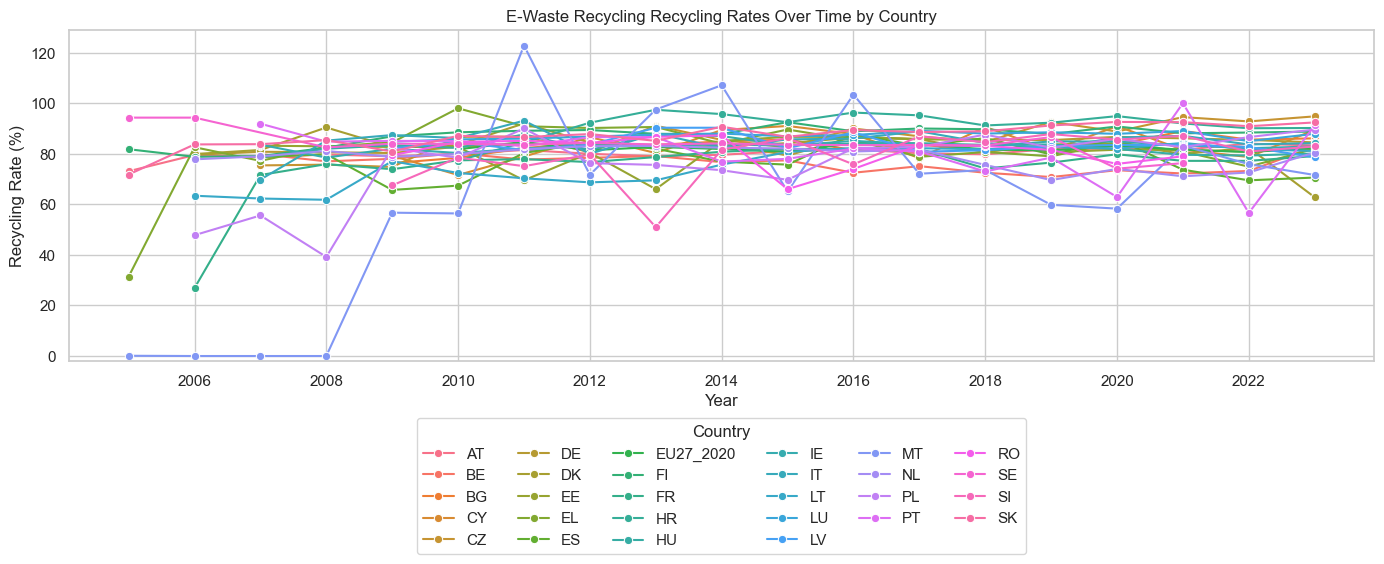

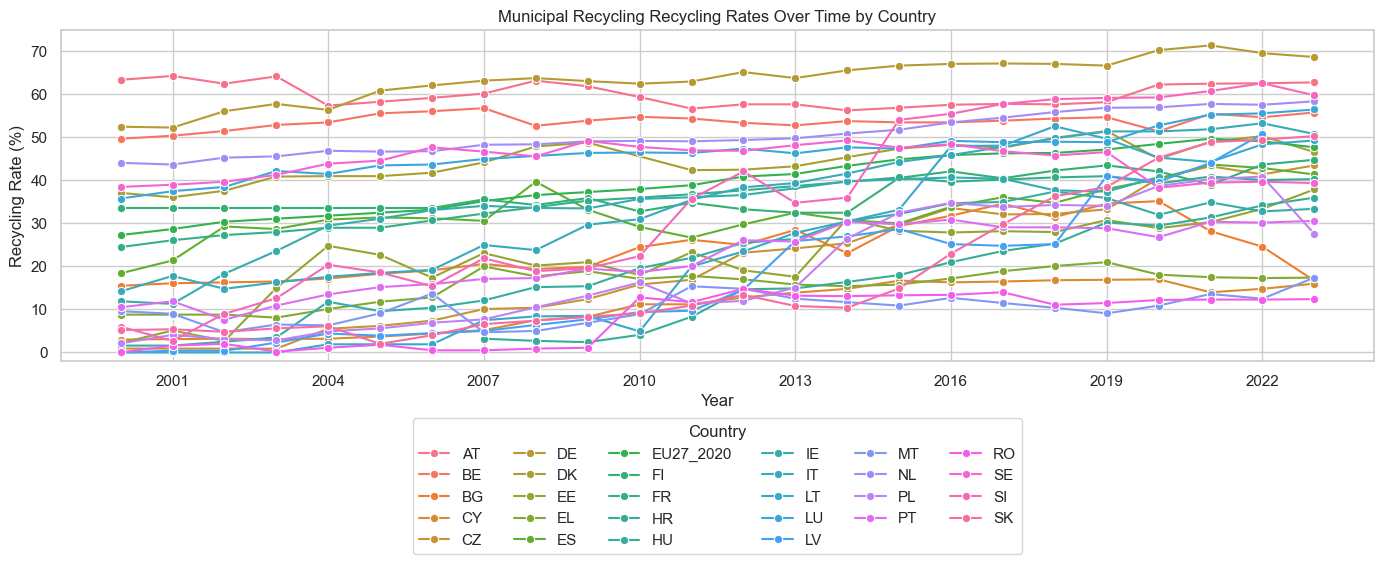

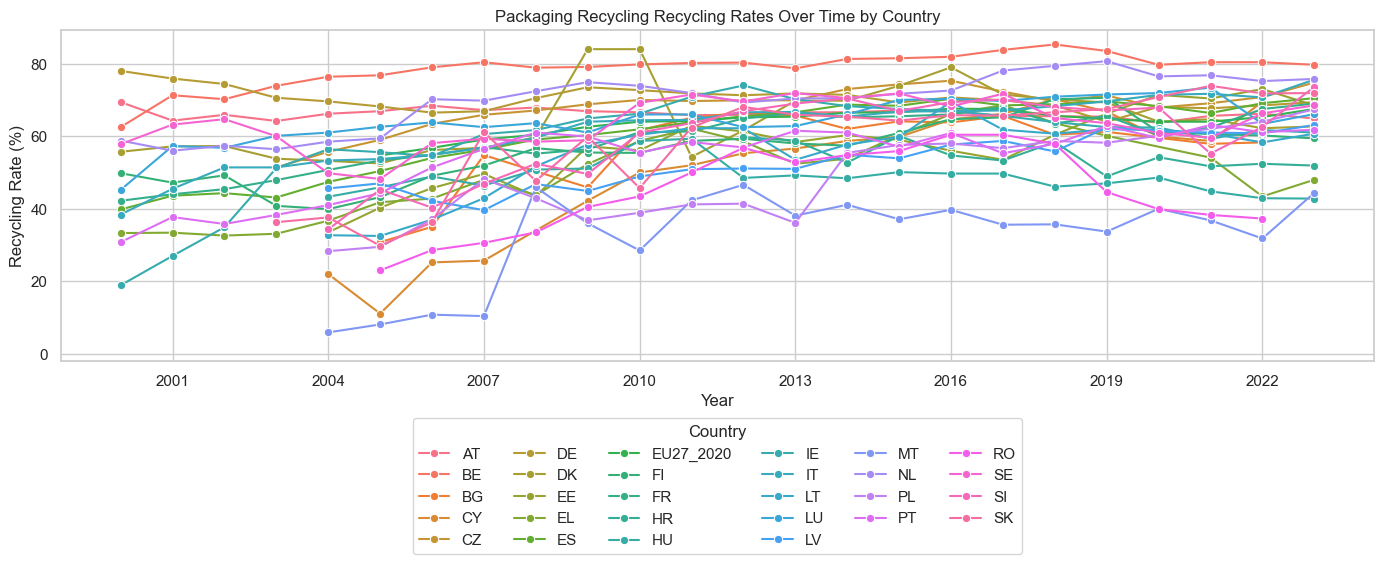

In [436]:
plot_each_country('ewaste', 'E-Waste Recycling')
plot_each_country('municipal', 'Municipal Recycling')
plot_each_country('packaging', 'Packaging Recycling')

Let's have a look at the most interesting countries e.g. those, that show the highest improvements and those which have shown declining recycling rates.

In [437]:
def plot_top_bottom_countries(type_of_waste, type_of_waste_label, top_n=3):
    sns.set(style="whitegrid")
    df_plot = df_final.reset_index().copy()
    df_plot["TIME_PERIOD"] = df_plot["TIME_PERIOD"].astype("Int64")

    # Calculate improvement using each country's first and last available data points
    improvements = {}
    improvement_details = []
    
    for country in df_plot['geo'].unique():
        data_country = df_plot[df_plot['geo'] == country]
        
        # Get data for this country and waste type, sorted by year
        country_data = data_country[['TIME_PERIOD', 'recycling_rate_' + type_of_waste + '_pc']].dropna()
        
        if len(country_data) >= 2:  # Need at least 2 data points
            country_data = country_data.sort_values('TIME_PERIOD')
            
            start_year = country_data.iloc[0]['TIME_PERIOD']
            start_value = country_data.iloc[0]['recycling_rate_' + type_of_waste + '_pc']
            
            end_year = country_data.iloc[-1]['TIME_PERIOD']
            end_value = country_data.iloc[-1]['recycling_rate_' + type_of_waste + '_pc']
            
            improvement = end_value - start_value
            improvements[country] = improvement
            
            # Store details for summary table
            improvement_details.append({
                'Country': eu_countries_map.get(country, country),
                'Code': country,
                'Start Year': int(start_year),
                'Start Rate (%)': round(start_value, 2),
                'End Year': int(end_year),
                'End Rate (%)': round(end_value, 2),
                'Absolute Change (pp)': round(improvement, 2),
                'Relative Change (%)': round((improvement / start_value) * 100, 2) if start_value > 0 else None
            })

    # Sort countries by improvement
    sorted_countries = sorted(improvements.items(), key=lambda x: x[1], reverse=True)
    top_countries = [country for country, _ in sorted_countries[:top_n]]
    bottom_countries = [country for country, _ in sorted_countries[-top_n:]]

    selected_countries = top_countries + bottom_countries

    # Create summary table for selected countries
    summary_df = pd.DataFrame(improvement_details)
    summary_df = summary_df[summary_df['Code'].isin(selected_countries)]
    
    # Sort to show top performers first, then bottom performers
    summary_df['Order'] = summary_df['Code'].map({code: i for i, code in enumerate(top_countries + bottom_countries)})
    summary_df = summary_df.sort_values('Order').drop('Order', axis=1)
    
    # Add category column
    summary_df['Category'] = summary_df['Code'].apply(
        lambda x: 'Top Performer' if x in top_countries else 'Bottom Performer'
    )
    summary_df = summary_df[['Category', 'Country', 'Code', 'Start Year', 'Start Rate (%)', 
                             'End Year', 'End Rate (%)', 'Absolute Change (pp)', 'Relative Change (%)']]

    # Plot
    plt.figure(figsize=(14, 6))
    sns.lineplot(
        data=df_plot[df_plot['geo'].isin(selected_countries)],
        x="TIME_PERIOD",
        y="recycling_rate_" + type_of_waste + "_pc",
        hue="geo",
        marker="o",
    )
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.title(f"Top {top_n} and Bottom {top_n} Countries in {type_of_waste_label} Recycling Rates Over Time")
    plt.xlabel("Year")
    plt.ylim(bottom=-2)
    plt.ylabel("Recycling Rate (%)")
    plt.legend(title="Country", bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=6)
    plt.tight_layout()
    plt.show()
    
    # Display summary table
    print(f"\n=== PERFORMANCE SUMMARY: {type_of_waste_label} Recycling ===\n")
    display(summary_df.reset_index(drop=True))
    
    return None

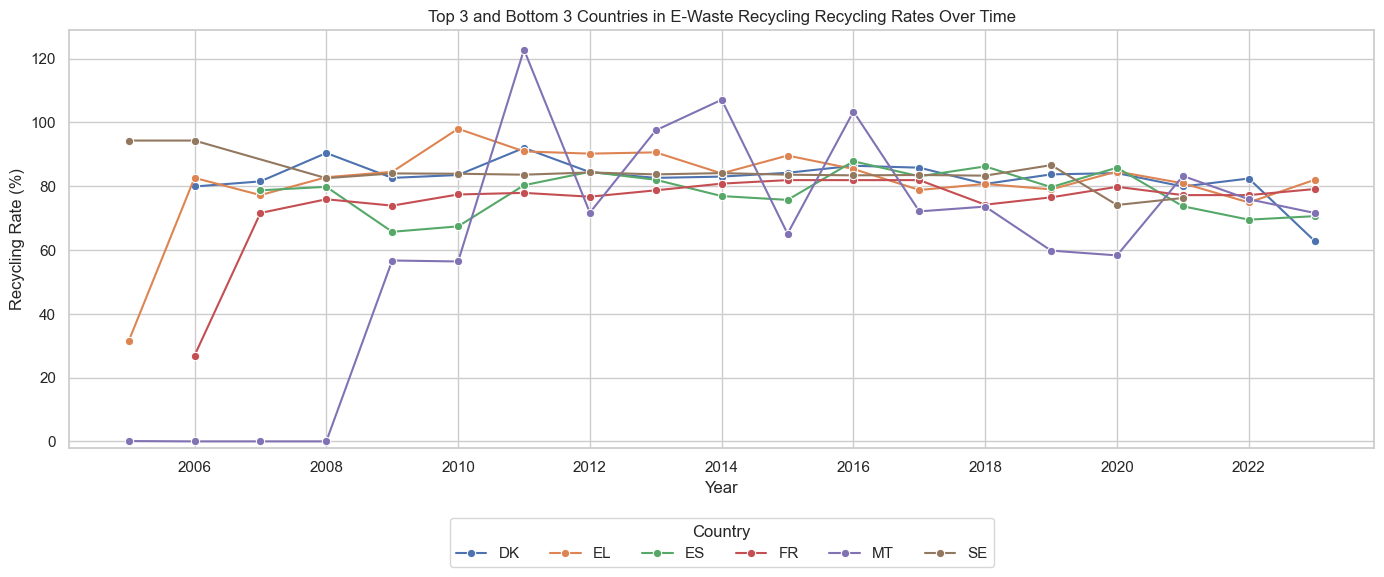


=== PERFORMANCE SUMMARY: E-Waste Recycling Recycling ===



,Category,Country,Code,Start Year,Start Rate (%),End Year,End Rate (%),Absolute Change (pp),Relative Change (%)
0,Top Performer,Malta,MT,2005,0.1,2023,71.6,71.5,71500.00
1,Top Performer,France,FR,2006,26.9,2023,79.1,52.2,194.05
2,Top Performer,Greece,EL,2005,31.4,2023,82.0,50.6,161.15
3,Bottom Performer,Spain,ES,2007,78.7,2023,70.6,-8.1,-10.29
4,Bottom Performer,Denmark,DK,2006,79.9,2023,62.8,-17.1,-21.40
5,Bottom Performer,Sweden,SE,2005,94.3,2021,76.3,-18.0,-19.09


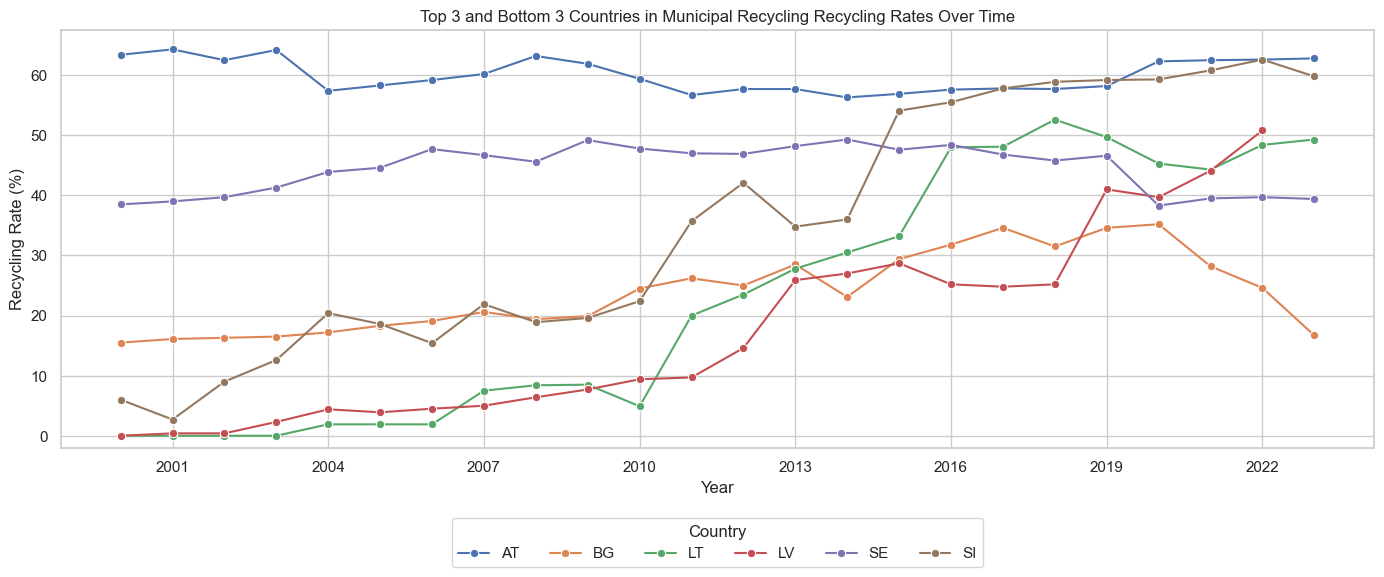


=== PERFORMANCE SUMMARY: Municipal Recycling Recycling ===



,Category,Country,Code,Start Year,Start Rate (%),End Year,End Rate (%),Absolute Change (pp),Relative Change (%)
0,Top Performer,Slovenia,SI,2000,6.0,2023,59.8,53.8,896.67
1,Top Performer,Latvia,LV,2000,0.0,2022,50.8,50.8,NaN
2,Top Performer,Lithuania,LT,2000,0.0,2023,49.3,49.3,NaN
3,Bottom Performer,Bulgaria,BG,2000,15.5,2023,16.7,1.2,7.74
4,Bottom Performer,Sweden,SE,2000,38.5,2023,39.4,0.9,2.34
5,Bottom Performer,Austria,AT,2000,63.4,2023,62.8,-0.6,-0.95


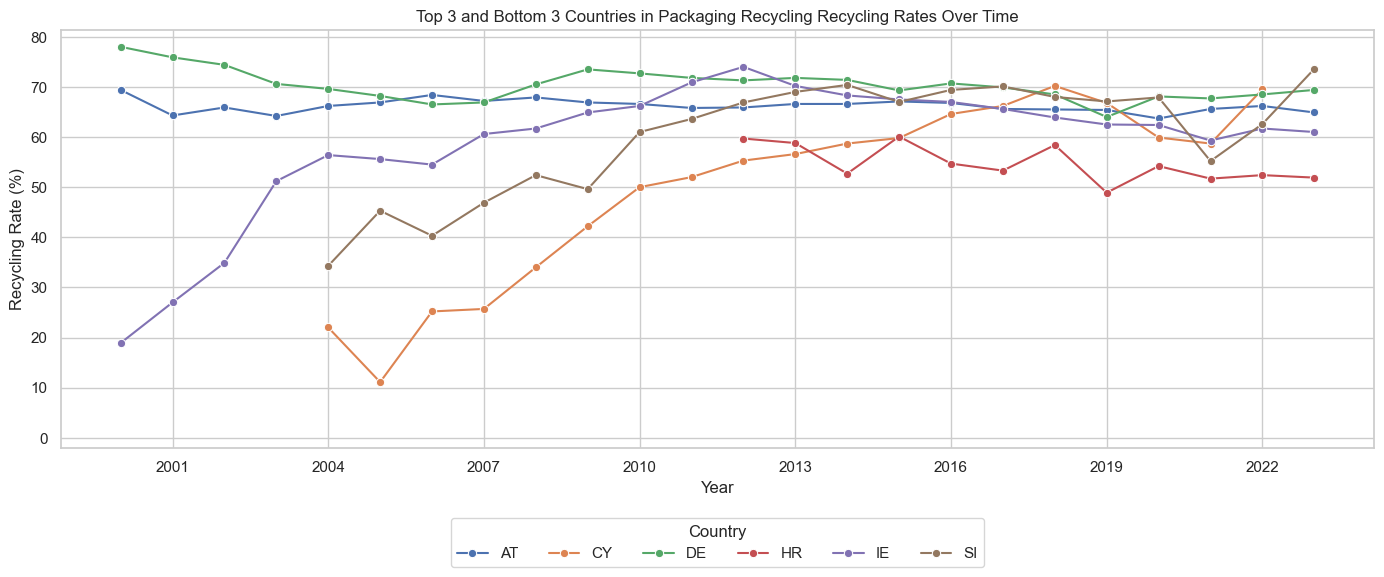


=== PERFORMANCE SUMMARY: Packaging Recycling Recycling ===



,Category,Country,Code,Start Year,Start Rate (%),End Year,End Rate (%),Absolute Change (pp),Relative Change (%)
0,Top Performer,Cyprus,CY,2004,22.0,2022,69.5,47.5,215.91
1,Top Performer,Ireland,IE,2000,18.9,2023,61.0,42.1,222.75
2,Top Performer,Slovenia,SI,2004,34.3,2023,73.6,39.3,114.58
3,Bottom Performer,Austria,AT,2000,69.4,2023,64.9,-4.5,-6.48
4,Bottom Performer,Croatia,HR,2012,59.7,2023,51.9,-7.8,-13.07
5,Bottom Performer,Germany,DE,2000,78.0,2023,69.4,-8.6,-11.03


In [438]:
plot_top_bottom_countries('ewaste', 'E-Waste Recycling')
plot_top_bottom_countries('municipal', 'Municipal Recycling')
plot_top_bottom_countries('packaging', 'Packaging Recycling')

### 6.3. Target Analysis
While a deep dive into every individual regulation is outside our current scope, we can examine the "big picture" laws that correlate with the most significant shifts in waste recycling rates across the top and bottom performer nations. The goal is to find out which policies work best to propose rolling them out in other countries as well. Further, we want to explain the bottom performers problems as well to prevent mistakes in other countries.
 
#### Municipal Waste
| Country       | Policy/External Factor                            | Implementation Year    | Effect                                                                                                                                                                                                                            | Source (URL)                                                                                                                                                                                                             |
| :-----------: | :------------------------------------------------ | :--------------------: | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Austria(*)**   | Landfill Ordinance (*Deponieverordnung*)          | 1989, Full Ban: 2004         | Banned the disposal of untreated municipal waste, which forced a shift to thermal/biological treatment and led to the aggressive rollout of separate bio-waste collection systems.                                                | [Landfill Tax, Incineration Tax and Landfill Ban in Austriai](https://ieep.eu/wp-content/uploads/2022/12/AT-Landfill-Tax-final.pdf)                                                                                      |
| **Slovenia**  | Door-to-Door Collection & Pay-As-You-Throw (PAYT) | 2014 (Ljubljana Model) | Inverted the convenience hierarchy and introduced volume-based pricing for residual waste, driving behavioral change and resulting in a 95% decrease in residual waste sent to landfill in the capital.                           | [Zero-waste strategy: Ljubljana, Slovenia](https://www.ebrdgreencities.com/policy-tool/zero-waste-strategy-ljubljana-slovenia/)                                                                                          |
| **Lithuania** | Deposit Return System (DRS)                       | 2016                   | A technology-enabled system with a uniform €0.10 deposit and "return-to-retail" mandate, which delivered a profound and immediate increase in plastic bottle collection rates from 34% to over 90%.                               | [Race towards Deposit Return Systems](https://fairresourcefoundation.org/en/race-towards-deposit-return-systems/)                                                                                                        |
| **Latvia**    | Natural Resources Tax (NRT) Escalator             | Started around 2017    | Legislated a steep, multi-year increase in the landfill tax (up to €110/tonne by 2024), which served as "shock therapy" to price landfilling out of the market and drive material diversion.                                      | [Latvia - European Environment Agency](https://www.eea.europa.eu/en/topics/in-depth/waste-and-recycling/municipal-and-packaging-waste-management-country-profiles-2025/lv-municipal-waste-factsheet.pdf/@@download/file) |
| **Sweden**    | Landfill Bans on Combustible & Organic Waste      | 2002 & 2005            | Effectively eliminated the landfilling of municipal solid waste, leading to the rapid construction of Waste-to-Energy plants and creating an "incineration trap" that presents a structural barrier to higher material recycling. | [Municipal waste management in Sweden](https://www.eea.europa.eu/publications/managing-municipal-solid-waste/sweden-municipal-waste-management)                                                                          |
| **Bulgaria**  | Statistical Pivot (EU Decision 2019/1004)         | Effective Post-2020    | A change in EU calculation methodology requiring reporting of *net* waste entering final recycling, which caused a statistical "drop" that exposed lower-than-claimed actual material recycling capacity.                         | [Bulgaria - European Environment Agency](https://www.eea.europa.eu/publications/many-eu-member-states/bulgaria)                                                                                                          |
 
(*) While Austria maintains high recycling rates (over 60%), its plateauing performance, particularly in plastic recycling (The Plastic Gap), stems from a reliance on incineration similar to Sweden's "Incineration Trap," a challenge it is adressing now via the National Circular Economy Strategy in December 2022, aiming to increase the circularity rate of the economy from 9.7% to 18% by 2030.
[Impact story: from the CGR Austria to the first National Circular Economy Strategy](https://www.circularity-gap.world/updates-collection/impact-story-from-the-cgr-austria-to-the-first-national-circular-economy-strategy)
 
#### Packaging Waste
Note, a methodological purification mandated by the EU in 2019 forced countries to measure recycling at the final reprocessing input, thereby removing statistical buffers and leading to a structural decline or stagnation in reported rates.
[Commission Implementing Decision (EU) 2019/665](https://eur-lex.europa.eu/eli/dec_impl/2019/665/oj/eng)
 
| Country     | Policy/External Factor                                                            | Implementation Year | Effect                                                                                                                                                                                   | Source (URL)                                                                                                                                                                                                             |
| :---------- | :-------------------------------------------------------------------------------- | :------------------ | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Poland**  | "Garbage Revolution" (Act on Maintaining Cleanliness and Order in Municipalities) | 2013                | Break in series; massive jump in reported collection due to nationalization of waste ownership, bringing previously 'invisible' waste into the formal system.                            | [EEA Factsheet](https://www.eea.europa.eu/en/topics/in-depth/waste-and-recycling/country-profiles-on-waste-prevention-2025/poland_waste-prevention-factsheet-2024/@@download/file)                                       |
| **Romania** | DNA Investigation into OIREP Fraud                                                | 2016                | Catastrophic drop (correction) in reported rates as widespread fraud within the Producer Responsibility Organization (OIREP) system was exposed and fake data was removed.               | [Eurostat - Packaging waste statistics](https://ec.europa.eu/eurostat/statistics-explained/index.php/Packaging_waste_statistics)                                                                                         |
| **Romania** | RetuRO Deposit Return System                                                      | 2023                | Expected sharp increase in beverage container recycling due to the implementation of a new, transparent, and digitally traceable closed-loop collection system.                          | [The Guardian](https://www.theguardian.com/environment/2025/nov/27/we-like-it-a-lot-how-romania-created-the-largest-deposit-return-scheme-in-the-world)                                                                  |
| **Ireland** | EPA Reclassification of Cement Kiln Fuel                                          | \~2012-14           | Decrease/Stagnation in reported rates as the use of waste fuel in cement kilns was reclassified from "recycling" to "energy recovery," removing it from the recycling statistics.        | [Ireland - European Environment Agency](https://www.eea.europa.eu/publications/many-eu-member-states/ireland)                                                                                                            |
| **Greece**  | EOAN Audits & "Blue Bin" Correction                                               | 2017-19             | Decline/Stagnation as stricter regulatory audits enforced the deduction of high impurity/residue rates (often 40-50%) from the total Blue Bin collected tonnage.                         | [Greece - European Environment Agency](https://www.eea.europa.eu/en/topics/in-depth/waste-and-recycling/municipal-and-packaging-waste-management-country-profiles-2025/lv-municipal-waste-factsheet.pdf/@@download/file) |
| **Latvia**  | Natural Resources Tax (NRT) & Exemptions                                          | Ongoing             | High sustained rates due to a punitive tax on non-compliant producers, creating a powerful "tax-or-recycle" financial motive to ensure high collection and recycling via PROs.           | [Latvia - European Environment Agency](https://www.eea.europa.eu/en/topics/in-depth/waste-and-recycling/municipal-and-packaging-waste-management-country-profiles-2025/lv-municipal-waste-factsheet.pdf/@@download/file)                                                                                                              |
| **Cyprus**  | Stockpiling & Export timing (Statistical Anomaly)                                 | 2022                | Artificial spike in steel recycling due to a one-time export of accumulated metal scrap, which was recorded in that year's statistics, decoupling the rate from current-year generation. | [Cyprus - European Environment Agency](https://www.eea.europa.eu/en/topics/in-depth/waste-and-recycling/municipal-and-packaging-waste-management-country-profiles-2025/lv-municipal-waste-factsheet.pdf/@@download/file)                                                                                                              |
 
 
 
#### E-Waste
| Country     | Policy/External Factor                      | Implementation Year | Effect (in essence)                                                                                                                               | Source (URL)                                                                                                                                                                                    |
| :---------: | :-----------------------------------------: | :-----------------: | :-----------------------------------------------------------------------------------------------------------------------------------------------: | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------: |
| **Sweden**  | Phased Landfill Ban                         | 2002                | Forced the rapid development of rigorous upstream separation streams for WEEE and fueled Waste-to-Energy networks.                                | [Waste incineration in the Nordic countries](https://pub.norden.org/temanord2024-524/3-synthesis-of-results.html)                                                                               |
| **Denmark** | Statutory Clearing House Model (DPA-System) | Post-2002           | Mathematically allocates WEEE collection responsibility among schemes, preventing "cherry-picking" and ensuring geographic equity.                | [WEEE system setup](https://www.diva-portal.org/smash/get/diva2:1552417/FULLTEXT01.pdf)                                                                                                         |
| **France**  | Visible Fee (Eco-participation)             | 2005                | Secured a ring-fenced revenue stream for Producer Responsibility Organizations (PROs) and drove immediate public awareness of recycling costs.    | [WEEE Compliance](https://fr.commscope.com/corporate-responsibility-and-sustainability/environment/weee-recycling-in-france/)                                                                   |
| **France**  | "1-for-0" Take-Back Obligations             | 2014                | Mandated large retailers to accept small WEEE (\<25 cm) without a new purchase, drastically increasing the density of the collection network.     | [Assessment of WEEE collection systems and their effectiveness in other European countries](https://dts.valpak.co.uk/Content/Documents/Eunomia%20Valpak%20DTS%20Report%202019.pdf)              |
| **Spain**   | Royal Decree 110/2015                       | 2015                | Mandated a centralized electronic platform for data traceability to combat the loss of WEEE to the informal "grey market."                        | [In-depth review of the WEEE Collection Rates and Targets - SCYCLE](https://www.scycle.info/wp-content/uploads/2020/11/In-depth-review_WEEE-Collection-Targets-and-Rates_UNITAR_2020_Final.pdf) |
| **Greece**  | 2008-2014 Financial Crisis                  | 2010                | Caused a "Denominator Collapse" (precipitous drop in new sales/POM), which statistically distorted collection rates and led to consumer hoarding. | [Update of WEEE Collection Rates, Targets, Flows, and Hoarding – 2021](https://weee-forum.org/wp-content/uploads/2022/12/Update-of-WEEE-Collection_web_final_nov_29.pdf)                        |
| **Malta**   | Civic Amenity Sites Infrastructure Rollout  | 2007                | Acted as a "release valve" for decades of hoarded historical WEEE, causing collection volumes and reported rates to occasionally exceed 100%.     | [Update of WEEE Collection Rates, Targets, Flows, and Hoarding – 2021](https://weee-forum.org/wp-content/uploads/2022/12/Update-of-WEEE-Collection_web_final_nov_29.pdf)                        |
 
#### Conclusion
Those countries that show stagnation are usually on a very high level and face certain limitations of their previously implemented policies. Most of the declines can be explained by a methodological shift or external factor (E.g. rapid change of E-Waste recycling in Malta can be explained by the hoarding effect) - careful analysis required. Also a huge part of municipal waste is packaging waste which is the reason why those policies are very similar.
 
What seems to have worked best for **municipal waste** is the
- landfill tax (see Austria).
- residual waste tax (see Slovenia).
- deposit return system (see Lithuania).
 
However, note that in combination they are most effective (e.g. landfill tax promotes incineration (results in incineration trap e.g. Austria, Sweden); to fight incineration trap you could introduce a deposit return system.)
 
For **packaging waste** (highly correlated with municipal waste):
- give ownership to the municipalities (this applies not only to the packaing waste but Poland has shown great performance of recycling increase in packaging waste due to this policy).
- deposit system (see Romania, Latvia)
 
 

#### Target Gap Analysis
Building on the EU targets outlined earlier, we now examine how individual member countries are performing against these benchmarks.

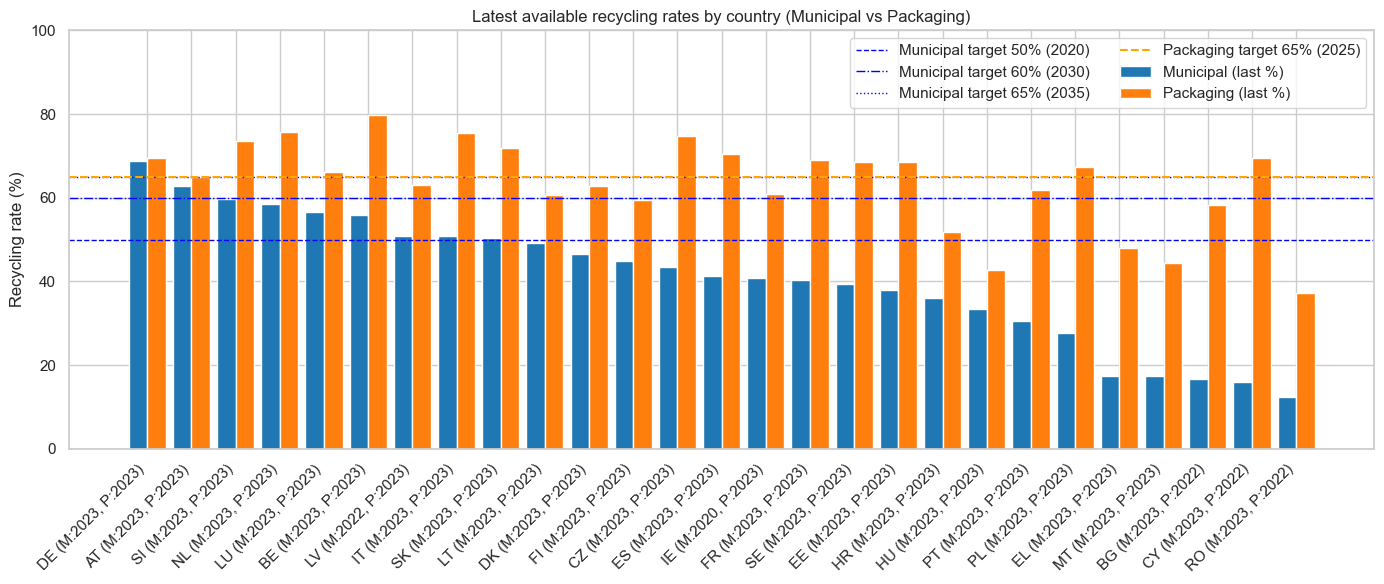

,geo,municipal_pc,municipal_year,packaging_pc,packaging_year
5,DE,68.7,2023,69.4,2023
0,AT,62.8,2023,64.9,2023
25,SI,59.8,2023,73.6,2023
20,NL,58.4,2023,75.8,2023
17,LU,56.5,2023,66.1,2023
1,BE,55.8,2023,79.7,2023
18,LV,50.8,2022,63.1,2023
15,IT,50.8,2023,75.6,2023
26,SK,50.3,2023,71.9,2023
16,LT,49.3,2023,60.7,2023


In [439]:
def plot_latest_recycling_bars(df_final):
    """
    Side-by-side bar chart of the last available recycling % per country
    for municipal and packaging waste, with EU target lines.
    Returns a small summary DataFrame of the used values/years.
    """
    df = df_final.reset_index()

    # EU27 countries (ISO codes), exclude EU27_2020 aggregate
    eu_iso = sorted([code for code in eu_countries_map.keys() if code != 'EU27_2020'])

    df = df[df['geo'].isin(eu_iso)]

    def last_metric(metric):
        tmp = (df[['geo','TIME_PERIOD',metric]]
               .dropna(subset=[metric])
               .sort_values(['geo','TIME_PERIOD']))
        last = tmp.groupby('geo').last(numeric_only=False).reset_index()
        last.rename(columns={metric: f'{metric}_val', 'TIME_PERIOD': f'{metric}_year'}, inplace=True)
        return last

    m_last = last_metric('recycling_rate_municipal_pc')
    p_last = last_metric('recycling_rate_packaging_pc')

    latest = pd.merge(m_last, p_last, on='geo', how='outer')

    # Sort by municipal values (fallback to packaging if municipal missing)
    sort_key = latest['recycling_rate_municipal_pc_val'].fillna(latest['recycling_rate_packaging_pc_val'])
    latest = latest.loc[sort_key.sort_values(ascending=False).index]

    # Plot
    sns.set(style='whitegrid')
    fig, ax = plt.subplots(figsize=(14, 6))
    x = range(len(latest))
    width = 0.42

    ax.bar([i - width/2 for i in x],
           latest['recycling_rate_municipal_pc_val'],
           width=width, color='#1f77b4', label='Municipal (last %)')

    ax.bar([i + width/2 for i in x],
           latest['recycling_rate_packaging_pc_val'],
           width=width, color='#ff7f0e', label='Packaging (last %)')

    # X labels with last years per metric
    labels = []
    for _, row in latest.iterrows():
        m_year = row.get('recycling_rate_municipal_pc_year')
        p_year = row.get('recycling_rate_packaging_pc_year')
        if pd.notna(m_year) and pd.notna(p_year):
            labels.append(f"{row['geo']} (M:{int(m_year)}, P:{int(p_year)})")
        elif pd.notna(m_year):
            labels.append(f"{row['geo']} (M:{int(m_year)})")
        elif pd.notna(p_year):
            labels.append(f"{row['geo']} (P:{int(p_year)})")
        else:
            labels.append(row['geo'])
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha='right')

    # EU targets (from your description)
    ax.axhline(50, color='blue', linestyle='--', linewidth=1, label='Municipal target 50% (2020)')
    ax.axhline(60, color='blue', linestyle='-.', linewidth=1, label='Municipal target 60% (2030)')
    ax.axhline(65, color='blue', linestyle=':', linewidth=1, label='Municipal target 65% (2035)')
    ax.axhline(65, color='orange', linestyle='--', linewidth=1.5, label='Packaging target 65% (2025)')

    ax.set_ylim(0, 100)
    ax.set_ylabel('Recycling rate (%)')
    ax.set_title('Latest available recycling rates by country (Municipal vs Packaging)')
    ax.legend(ncol=2, bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()

    return latest[['geo',
                   'recycling_rate_municipal_pc_val','recycling_rate_municipal_pc_year',
                   'recycling_rate_packaging_pc_val','recycling_rate_packaging_pc_year']].rename(columns={
        'recycling_rate_municipal_pc_val':'municipal_pc',
        'recycling_rate_municipal_pc_year':'municipal_year',
        'recycling_rate_packaging_pc_val':'packaging_pc',
        'recycling_rate_packaging_pc_year':'packaging_year'
    })

# Usage
latest_summary = plot_latest_recycling_bars(df_final)
display(latest_summary)

#  7. Are there characteristics of countries that could lead to increased recycling?
Three methods are used to explore possible answers to this question: a regression model that reflects the datas panel structure, PCA and Hierarchical Clustering.
For this, the previously established merged_dataset for the EU 27 countries is used. 

In [440]:
# drop rows with missing keys and set MultiIndex
panel_df = df_merged.dropna(subset=['country', 'year']).copy()
panel_df = panel_df.loc[panel_df['country'] != 'EU27_2020']  # Exclude EU aggregate
panel_df['year'] = panel_df['year'].astype(int)
panel_df = panel_df.set_index(['country', 'year']).sort_index()
panel_df.head(3)

packaging_recycling  municipal_recycling  electrical_recycling  \
country year                                                                   
AT      2000                 69.4                 63.4                   NaN   
        2001                 64.3                 64.3                   NaN   
        2002                 65.9                 62.5                   NaN   

              gdp_per_capita  urban_population_share  population_density  \
country year                                                               
AT      2000       53599.610                  60.213                 NaN   
        2001       54098.027                  59.934                 NaN   
        2002       54631.600                  59.655                 NaN   

              education_attainment  waste_expenditure  
country year                                           
AT      2000                   NaN           5.562567  
        2001                   NaN           5.696860  
        2002                   NaN           5.821767

In [441]:
selected_outcomes = ['packaging_recycling', 'municipal_recycling', 'electrical_recycling']  
selected_predictors = ['gdp_per_capita', 'urban_population_share', 'population_density', 'education_attainment', 'waste_expenditure'] 

## 7.1. Panel Regression
To examine whether country characteristics are associated with increased recycling, a two-way fixed-effects panel regression model is employed. The dataset consists of multiple EU countries observed over several years. The panel regression allows to investigate the following: When a country’s characteristics change, does its recycling rate change, when compared to that same country in other years?

The analysis focuses on within-country changes over time, estimating how changes in country characteristics are associated with changes in recycling outcomes, while controlling for unobserved, time-invariant country-specific factors. These factors are captured through country fixed effects.

In addition, year fixed effects are included to account for common shocks and trends affecting all countries in a given year, such as EU-wide policy changes.

Separate regressions are estimated for each recycling outcome. All predictors are standardized to allow for comparability across variables. Standard errors are clustered at the country level.

Observations with missing values in either the dependent variable or any of the predictor variables are excluded prior to estimating the panel regression models, since panel regression requires complete observations.

### Multivariate Panel Regression with different Lags
We investigate whether GDP, education attainment, and waste expenditure have delayed rather than immediate effects on recycling rates. Therefore, we test 1-year and 3-year lagged versions of these variables and compare them to current (non-lagged) values.

In [442]:
# Create lagged versions of each variable
panel_df_lags = panel_df.copy()
panel_df_lags['gdp_lag1'] = panel_df_lags.groupby(level=0)['gdp_per_capita'].shift(1)
panel_df_lags['gdp_lag3'] = panel_df_lags.groupby(level=0)['gdp_per_capita'].shift(3)
panel_df_lags['educ_lag1'] = panel_df_lags.groupby(level=0)['education_attainment'].shift(1)
panel_df_lags['educ_lag3'] = panel_df_lags.groupby(level=0)['education_attainment'].shift(3)
panel_df_lags['waste_lag1'] = panel_df_lags.groupby(level=0)['waste_expenditure'].shift(1)
panel_df_lags['waste_lag3'] = panel_df_lags.groupby(level=0)['waste_expenditure'].shift(3)

# Run regressions for current and lagged versions

results_current = {}
results_gdp_lag1 = {}
results_gdp_lag3 = {}
results_educ_lag1 = {}
results_educ_lag3 = {}
results_waste_lag1 = {}
results_waste_lag3 = {}

for outcome in selected_outcomes:
    # Current values
    y = panel_df[outcome]
    X = panel_df[selected_predictors].copy()
    valid = (~y.isna()) & (~X.isna().any(axis=1))
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X[valid]), index=y[valid].index, columns=X.columns)
    results_current[outcome] = PanelOLS(y[valid], X_scaled, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
    
    # GDP lag1
    X_temp = panel_df_lags[['gdp_lag1', 'urban_population_share', 'population_density', 'education_attainment', 'waste_expenditure']].copy()
    valid = (~y.isna()) & (~X_temp.isna().any(axis=1))
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_temp[valid]), index=y[valid].index, columns=X_temp.columns)
    results_gdp_lag1[outcome] = PanelOLS(y[valid], X_scaled, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
    
    # GDP lag3
    X_temp = panel_df_lags[['gdp_lag3', 'urban_population_share', 'population_density', 'education_attainment', 'waste_expenditure']].copy()
    valid = (~y.isna()) & (~X_temp.isna().any(axis=1))
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_temp[valid]), index=y[valid].index, columns=X_temp.columns)
    results_gdp_lag3[outcome] = PanelOLS(y[valid], X_scaled, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
    
    # Education lag1
    X_temp = panel_df_lags[['gdp_per_capita', 'urban_population_share', 'population_density', 'educ_lag1', 'waste_expenditure']].copy()
    valid = (~y.isna()) & (~X_temp.isna().any(axis=1))
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_temp[valid]), index=y[valid].index, columns=X_temp.columns)
    results_educ_lag1[outcome] = PanelOLS(y[valid], X_scaled, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
    
    # Education lag3
    X_temp = panel_df_lags[['gdp_per_capita', 'urban_population_share', 'population_density', 'educ_lag3', 'waste_expenditure']].copy()
    valid = (~y.isna()) & (~X_temp.isna().any(axis=1))
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_temp[valid]), index=y[valid].index, columns=X_temp.columns)
    results_educ_lag3[outcome] = PanelOLS(y[valid], X_scaled, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
    
    # Waste lag1
    X_temp = panel_df_lags[['gdp_per_capita', 'urban_population_share', 'population_density', 'education_attainment', 'waste_lag1']].copy()
    valid = (~y.isna()) & (~X_temp.isna().any(axis=1))
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_temp[valid]), index=y[valid].index, columns=X_temp.columns)
    results_waste_lag1[outcome] = PanelOLS(y[valid], X_scaled, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)
    
    # Waste lag3
    X_temp = panel_df_lags[['gdp_per_capita', 'urban_population_share', 'population_density', 'education_attainment', 'waste_lag3']].copy()
    valid = (~y.isna()) & (~X_temp.isna().any(axis=1))
    X_scaled = pd.DataFrame(StandardScaler().fit_transform(X_temp[valid]), index=y[valid].index, columns=X_temp.columns)
    results_waste_lag3[outcome] = PanelOLS(y[valid], X_scaled, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity=True)

# Compare t-statistics

print("All lag specifications (t-statistics):\n")

for outcome in selected_outcomes:
    print(f"{outcome}:")
    
    # GDP
    t_curr = results_current[outcome].tstats.get('gdp_per_capita', 0)
    t_lag1 = results_gdp_lag1[outcome].tstats.get('gdp_lag1', 0)
    t_lag3 = results_gdp_lag3[outcome].tstats.get('gdp_lag3', 0)
    print(f"  GDP:     current t={t_curr:6.2f}, lag1 t={t_lag1:6.2f}, lag3 t={t_lag3:6.2f}")
    
    # Education Attainment
    t_curr = results_current[outcome].tstats.get('education_attainment', 0)
    t_lag1 = results_educ_lag1[outcome].tstats.get('educ_lag1', 0)
    t_lag3 = results_educ_lag3[outcome].tstats.get('educ_lag3', 0)
    print(f"  Educ:    current t={t_curr:6.2f}, lag1 t={t_lag1:6.2f}, lag3 t={t_lag3:6.2f}")
    
    # Waste Expenditure
    t_curr = results_current[outcome].tstats.get('waste_expenditure', 0)
    t_lag1 = results_waste_lag1[outcome].tstats.get('waste_lag1', 0)
    t_lag3 = results_waste_lag3[outcome].tstats.get('waste_lag3', 0)
    print(f"  Waste:   current t={t_curr:6.2f}, lag1 t={t_lag1:6.2f}, lag3 t={t_lag3:6.2f}\n")

All lag specifications (t-statistics):

packaging_recycling:
  GDP:     current t= -4.81, lag1 t= -4.37, lag3 t= -3.47
  Educ:    current t=  0.88, lag1 t=  0.54, lag3 t=  0.16
  Waste:   current t=  0.51, lag1 t=  0.04, lag3 t= -1.18

municipal_recycling:
  GDP:     current t= -0.45, lag1 t= -0.12, lag3 t=  0.34
  Educ:    current t=  0.87, lag1 t=  0.70, lag3 t=  0.68
  Waste:   current t= -1.56, lag1 t= -0.75, lag3 t= -0.81

electrical_recycling:
  GDP:     current t=  0.80, lag1 t=  1.09, lag3 t=  1.10
  Educ:    current t=  0.17, lag1 t=  0.55, lag3 t=  1.25
  Waste:   current t= -1.66, lag1 t=  0.28, lag3 t= -1.11




- Packaging recycling:
  - GDP: all strongly significant; no lag effect
  - Education: current is best
  - Waste: all |t| < 1.96 (not significant)

- Municipal recycling:
  - GDP/education/waste: all |t| < 1.96; lags don’t help

- Electrical recycling:
  - GDP: all |t| < 1.96; no lag effect
  - Education: all |t| < 1.96; no lag effect
  - Waste: lag1 has largest |t| but still weak



Since current (non-lagged) values are as strong or stronger for almost all cases, we decided not to use lagged variables in the final model. This suggests that the effects of GDP, education, and waste expenditure on recycling rates operate with minimal time delays, or that any delayed effects are absorbed by the country and year fixed effects in our panel regression model.

Note: Statistical significance at 5% (|t| >= 1.96)

In [443]:
results = {}

# Scale predictors 
scaler = StandardScaler()

for outcome in selected_outcomes:
    y = panel_df[outcome]
    X = panel_df[selected_predictors].copy()

    # Drop rows with missing outcome or predictors
    valid_idx = (~y.isna()) & (~X.isna().any(axis=1))
    y2 = y.loc[valid_idx]
    X2 = X.loc[valid_idx]

    # Scale predictors
    X2_scaled = pd.DataFrame(
        scaler.fit_transform(X2.values),
        index=X2.index,
        columns=X2.columns,
    )
    
    mod = PanelOLS(y2, X2_scaled, entity_effects=True, time_effects=True)
    res = mod.fit(cov_type='clustered', cluster_entity=True)
    results[outcome] = res
    print(f"\n=== {outcome} ===")
    print(res.summary)

# Summarize which predictors are significant
print("="*80)
print("Significant Predictors by Waste Type (p < 0.05)")
print("="*80)

for outcome in selected_outcomes:
    if outcome in results:
        res = results[outcome]
        print(f"\n{outcome}:")
        
        sig_found = False
        for predictor in selected_predictors:
            if predictor in res.pvalues.index:
                pval = res.pvalues[predictor]
                if pval < 0.05:
                    coef = res.params[predictor]
                    tstat = res.tstats[predictor]
                    print(f"  {predictor:<30} coef={coef:>7.3f}, t={tstat:>6.2f}, p={pval:.4f}")
                    sig_found = True



=== packaging_recycling ===
                           PanelOLS Estimation Summary                           
Dep. Variable:     packaging_recycling   R-squared:                        0.0886
Estimator:                    PanelOLS   R-squared (Between):             -0.1964
No. Observations:                  288   R-squared (Within):               0.0068
Date:                 Wed, Jan 07 2026   R-squared (Overall):             -0.2008
Time:                         15:29:49   Log-likelihood                   -794.46
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      4.7608
Entities:                           27   P-value                           0.0004
Avg Obs:                        10.667   Distribution:                   F(5,245)
Min Obs:                        9.0000                                           
Max Obs:                        12.000   F-statistic (robust):       

Since urban population share never has a significant effect on the different recycling types, and it has high correlations with gdp_per_capita and  population_density, we drop it from the model.

### Reduced Model:
To handle missing values in the dataset, we investigate two strategies:
- Deletion of missing values
- Imputation of missing values

For imputation, the following approach is applied:
- Linear interpolation for missing values in the middle of a country’s time series
- Forward and backward filling for small gaps at the beginning or end of a series
- Replacement of any remaining missing values with the within-country mean

We compare results from both approaches to assess the influence of the explanatory variables on recycling rates.

In [444]:

reduced_predictors = ['gdp_per_capita', 'population_density', 'education_attainment', 'waste_expenditure']  

results_deletion = {}
scaler_reduced = StandardScaler()

for outcome in selected_outcomes:
    y = panel_df[outcome]
    X = panel_df[reduced_predictors].copy()

    valid_idx = (~y.isna()) & (~X.isna().any(axis=1))
    y2 = y.loc[valid_idx]
    X2 = X.loc[valid_idx]

    X2_scaled = pd.DataFrame(
        scaler_reduced.fit_transform(X2.values),
        index=X2.index,
        columns=X2.columns,
    )
    
    mod = PanelOLS(y2, X2_scaled, entity_effects=True, time_effects=True)
    res_del = mod.fit(cov_type='clustered', cluster_entity=True)
    results_deletion[outcome] = res_del
    #print(f"\n=== {outcome} (deletion) ===")
    #print(res_del.summary)

In [445]:


df_cy = panel_df.copy()

## Imputate missing values in training set ##
# Interpolations if some variables are missing in the middle of the time series
df_cy[reduced_predictors] = df_cy.groupby("country")[reduced_predictors].transform(
    lambda x: x.interpolate(method="linear", limit_area="inside")
)
#Forward and backwardsfill, if we have some small gaps at the beginning and the end
df_cy[reduced_predictors] = df_cy.groupby("country")[reduced_predictors].ffill(limit=3)
df_cy[reduced_predictors] = df_cy.groupby("country")[reduced_predictors].bfill(limit=3)

#Impute remaining missing values with within-country mean
for col in reduced_predictors:
    df_cy[col + "_missing"] = df_cy[col].isna().astype(int)
    country_means = df_cy.groupby("country")[col].transform("mean")
    df_cy[col] = df_cy[col].fillna(country_means)

results_imputation = {}

for outcome in selected_outcomes:
    y = df_cy[outcome]
    X = df_cy[reduced_predictors].copy()

    valid_idx = ~y.isna()
    y2 = y.loc[valid_idx]
    X2 = X.loc[valid_idx]

    X2_scaled = pd.DataFrame(
        scaler_reduced.fit_transform(X2.values),
        index=X2.index,
        columns=X2.columns,
    )
    
    mod = PanelOLS(y2, X2_scaled, entity_effects=True, time_effects=True)
    res_imp = mod.fit(cov_type='clustered', cluster_entity=True)
    results_imputation[outcome] = res_imp
    #print(f"\n=== {outcome} (imputation) ===")
    #print(res_imp.summary)




In [446]:
waste_types = selected_outcomes  
rows = []

for waste in waste_types:
    # Deletion
    res_del = results_deletion[waste]
    del_df = pd.DataFrame({
        'Variable': res_del.params.index,
        'b_del': res_del.params.values,
        'StdErr_del': res_del.std_errors.values,
        't_del': res_del.tstats.values,
        'p_del': res_del.pvalues.values
    })

    # Imputation
    res_imp = results_imputation[waste]
    imp_df = pd.DataFrame({
        'Variable': res_imp.params.index,
        'b_imp': res_imp.params.values,
        'StdErr_imp': res_imp.std_errors.values,
        't_imp': res_imp.tstats.values,
        'p_imp': res_imp.pvalues.values
    })

    merged = pd.merge(del_df, imp_df, on='Variable')
    merged.insert(0, 'Waste type', waste)

    rows.append(merged)

comparison_table = pd.concat(rows, ignore_index=True)

comparison_table[comparison_table.select_dtypes(include='number').columns] = comparison_table.select_dtypes(include='number').round(3)

display(comparison_table)


,Waste type,Variable,b_del,StdErr_del,t_del,p_del,b_imp,StdErr_imp,t_imp,p_imp
0,packaging_recycling,gdp_per_capita,-4.921,1.500,-3.280,0.001,-1.748,2.034,-0.859,0.390
1,packaging_recycling,population_density,-5.831,2.669,-2.185,0.030,-3.406,2.564,-1.329,0.185
2,packaging_recycling,education_attainment,2.162,2.951,0.733,0.464,3.053,3.797,0.804,0.422
3,packaging_recycling,waste_expenditure,0.277,1.540,0.180,0.857,0.027,1.647,0.016,0.987
4,municipal_recycling,gdp_per_capita,0.152,4.265,0.036,0.972,6.634,5.984,1.109,0.268
5,municipal_recycling,population_density,-14.919,4.997,-2.986,0.003,-13.022,5.053,-2.577,0.010
6,municipal_recycling,education_attainment,2.768,3.723,0.744,0.458,4.209,3.872,1.087,0.277
7,municipal_recycling,waste_expenditure,-3.252,2.239,-1.452,0.148,0.876,1.876,0.467,0.641
8,electrical_recycling,gdp_per_capita,1.631,1.816,0.898,0.370,4.033,4.535,0.889,0.374
9,electrical_recycling,population_density,-19.892,2.940,-6.766,0.000,-20.465,6.014,-3.403,0.001


1. Packaging Recycling:

- Deletion results:

    - gdp_per_capita: significant negative effect (b = -4.92, t = -3.28, p = 0.001) → higher GDP associated with lower packaging recycling
    - population_density: significant negative effect (b = -5.83, t = -2.19, p = 0.03) → denser populations slightly reduce packaging recycling
    - education_attainment and waste_expenditure: not significant (p > 0.4)

- Imputation results:
    - None of the predictors are significant (all p > 0.1)
    - Coefficients are smaller in magnitude 

Imputation increased sample size and smoothed missing data, which reduced the apparent significance of GDP and population density for packaging recycling.


2. Municipal recycling:

- Deletion results:
    - population_density: significant negative effect (-14.92, t = -2.99, p = 0.003) → denser populations have lower municipal recycling
    - Other variables (gdp_per_capita, education_attainment, waste_expenditure): not significant

- Imputation results:
    - population_density: remains significant 
    - Other predictors: still not significant.

Population density consistently affects municipal recycling, regardless of missing value handling.


3. Electrical recycling: 

- Deletion results:
    - population_density: strongly negative and highly significant (b = -19.89, t = -6.77, p < 0.001) → denser populations recycle less electrical waste
    - waste_expenditure: slightly significant negative effect (b = -5.12, t = -2.07, p = 0.039)
    - gdp_per_capita and education_attainment: not significant

- Imputation results:
    - population_density: still significant 
    - Other predictors: not significant

Population density is the strongest and most robust predictor for electrical recycling.

Overall Patterns: 

- Population density consistently shows negative effects for municipal and electrical recycling; its effect on packaging recycling is only significant in the deletion case.

- GDP and education are generally not significant once imputation is applied.

- Waste expenditure shows weak or inconsistent effects.



### 7.2. Principal Component Analysis (PCA)
PCA is chosen due to it's dimension reduction, allowing for visualization of the similarities between the countries. Since there is correlation between the variables, this method should give some exploratory insights to see which variables are correlated, and what seperates the different country characteristics. 

In contrast to the regression above, this analysis looks at countries characteristics as a whole, also in aggregated form. This aims to compare between different countries, rather than focusing on influences within countries.

Since there are many missing values for both battery and vehicle recycling, these variables are dropped and the analysis focuses on the three main parts of the above analysis (Questions 1-3) as well: municipal, packaging and e-waste recycling. Furthermore, all rows with missing data are dropped. While this leads considerable information loss, since this is an exploratory anaylisis using a method that cannot handle missing values, it is not deemed a major issue. It is important to note here, that this can introduce potential bias towards countries that have more complete data.

#### PCA keeping time dimension unchanged
Unsure of how to deal with the time-series nature of the data in this analysis, several approaches are explored. First, the year variable is introduced as its own variable in the PCA. This results in multiple scores for the same country, but it also allows the influence of time to be shown in the components.

In [447]:
merged_data_PCA = df_merged.copy()

features = merged_data_PCA.columns.tolist
merged_data_PCA = merged_data_PCA.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(merged_data_PCA.drop("country", axis=1))

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "explained_variance": explained_var,
    "cumulative_variance": np.cumsum(explained_var)
})

pca_summary

,PC,explained_variance,cumulative_variance
0,PC1,0.309677,0.309677
1,PC2,0.214552,0.524229
2,PC3,0.117757,0.641986
3,PC4,0.107537,0.749522
4,PC5,0.096051,0.845573
5,PC6,0.072750,0.918324
6,PC7,0.034077,0.952401
7,PC8,0.026933,0.979333
8,PC9,0.020667,1.000000


The first two principal components explain around 50% of the total variance - approximately six principal components would be necessary to explain 90% of the variance. Still, the first two PCs allow for a meaningful visualization of the data.

In [448]:
numeric_features = [
    "year",
    "packaging_recycling",
    "municipal_recycling",
    "electrical_recycling",
    "gdp_per_capita",
    "urban_population_share",
    "population_density",
    "education_attainment",
    "waste_expenditure"
]

loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
year,0.196516,0.073770,0.782793,-0.008099,0.490503,-0.104860,0.034900,0.022437,-0.299664
packaging_recycling,0.403163,-0.176512,-0.386016,-0.400823,0.291512,0.107105,0.049077,0.560464,-0.289235
municipal_recycling,0.473490,-0.115886,-0.119076,-0.163899,0.219944,-0.514251,-0.302789,-0.330984,0.455275
electrical_recycling,-0.036842,-0.287343,-0.221959,0.746125,0.506139,0.157659,-0.139925,0.070385,0.067403
gdp_per_capita,0.473724,0.133692,-0.097827,0.342336,-0.158260,-0.167384,0.753233,-0.094036,-0.041016
urban_population_share,0.297327,0.518986,-0.239344,0.094071,0.007135,0.258557,-0.369409,-0.404688,-0.457140
population_density,-0.060191,0.613199,-0.024490,0.236132,-0.041266,-0.411717,-0.202115,0.577134,0.137325
education_attainment,0.449243,0.056506,0.290860,0.068143,-0.228152,0.594023,-0.148956,0.211485,0.483647
waste_expenditure,-0.234586,0.448308,-0.150754,-0.263185,0.539465,0.266419,0.343877,-0.142998,0.388967


Looking at the loadings can give a hint as to what contributes to each principal component. The first principal component is most strongly influenced by packaging and municipal recycling, GDP/capita and education attainment. In contrast, the urban population share, population density and waste expenditure of the countries contribute most strongly to the second principal component. 

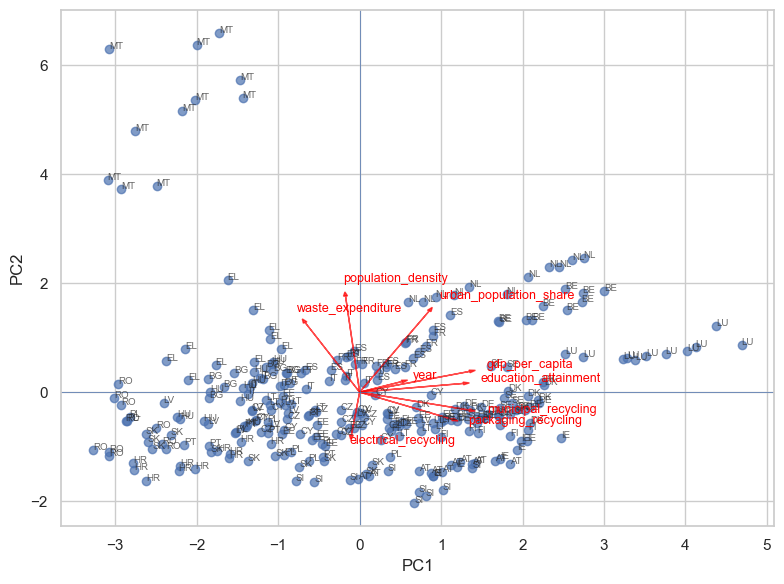

In [449]:
def pca_biplot(X_pca, loadings, labels, scale=3):
    
    plt.figure(figsize=(8, 6))

    # Scores
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)

    for i, label in enumerate(labels):
        plt.text(
            X_pca[i, 0],
            X_pca[i, 1],
            label,
            fontsize=7,
            alpha=0.7
        )

    # Loadings
    for var in loadings.index:
        x = loadings.loc[var, "PC1"] * scale
        y = loadings.loc[var, "PC2"] * scale

        plt.arrow(
            0, 0, x, y,
            color="red",
            alpha=0.7,
            head_width=0.05,
            length_includes_head=True
        )
        plt.text(
            x * 1.1,
            y * 1.1,
            var,
            color="red",
            fontsize=9
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.tight_layout()
    plt.show()


pca_biplot(
    X_pca,
    loadings,
    merged_data_PCA["country"].values
)

The visualization of the first two principal components can be seen in the biplot. Countries are represented by multiple scores, as the year variable is not explicitly handled, so each point represents the countries in a certain year. From the plot one can read that GDP/capita and education attainment are positively correlated with packaging and municipal recycling. Population density and waste expenditure are also positively correlated. 

No clear clusters emerge from the plot with the exception of Malta (MT), which differs strongly from the other countries along the second principal coponent. This suggests differences in population density, urban population share and waste expenditure. A small cluster could also be seen in the Netherlands (NL), Belgium (BE) and Luxembourg (LU), however it is not as clear as with Malta.

#### PCA aggregated over every 5 years
In order to reduce the time dimension, the data are aggregated into five-year periods for each country. As this approach still results in a number of missing values, rows with incomplete data are dropped prior to the PCA. This is argued to be finein this context, as the analysis is exploratory and aims to find similarities between countries that have high recycling numbers. 

In [450]:
merged_data_PCA = df_merged.copy()

merged_data_PCA["period_start"] = 2000 + ((merged_data_PCA["year"] - 2000)//5) *5
merged_data_PCA["period_end"] = merged_data_PCA["period_start"] + 4
merged_data_PCA["country_period"] = (
    merged_data_PCA["country"] + "_" +
    merged_data_PCA["period_end"].astype(str)
) # only attach period end for readability in plot

numeric_features = [
    "packaging_recycling",
    "municipal_recycling",
    "electrical_recycling",
    "gdp_per_capita",
    "urban_population_share",
    "population_density",
    "education_attainment",
    "waste_expenditure"
]

merged_data_PCA = (
    merged_data_PCA
    .groupby("country_period", as_index=False)[numeric_features]
    .mean()
)

merged_data_PCA = merged_data_PCA.dropna()

features = [
    "packaging_recycling",
    "municipal_recycling",
    "electrical_recycling",
    "gdp_per_capita",
    "urban_population_share",
    "population_density",
    "education_attainment",
    "waste_expenditure"
]
X = merged_data_PCA.loc[:,features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "explained_variance": explained_var,
    "cumulative_variance": np.cumsum(explained_var)
})

pca_summary

,PC,explained_variance,cumulative_variance
0,PC1,0.348441,0.348441
1,PC2,0.243044,0.591485
2,PC3,0.118996,0.710480
3,PC4,0.115753,0.826234
4,PC5,0.076484,0.902718
5,PC6,0.037649,0.940366
6,PC7,0.031883,0.972249
7,PC8,0.027751,1.000000


Aggregating over the years leads to the first two principal components being able to account for almost 60% of the explained variance, now only 5 PCs are required to explain 90% of the variability. 

In [451]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
packaging_recycling,0.435116,-0.144579,0.326175,-0.503102,0.020566,-0.013022,-0.084821,0.649986
municipal_recycling,0.486334,-0.092541,0.222579,-0.203448,-0.470760,-0.084024,0.355698,-0.555686
electrical_recycling,-0.057577,-0.342342,0.698356,0.503705,0.277395,-0.147116,0.198046,0.015944
gdp_per_capita,0.473271,0.101538,0.031292,0.450239,-0.088329,0.671700,-0.320718,0.012957
urban_population_share,0.296145,0.524334,0.178957,0.041872,0.261536,-0.512090,-0.474142,-0.219419
population_density,-0.060683,0.598756,0.097753,0.299238,-0.437394,-0.130609,0.393481,0.418940
education_attainment,0.445645,0.065640,-0.400270,0.108647,0.568069,-0.043968,0.545498,0.053565
waste_expenditure,-0.238473,0.453081,0.391906,-0.382051,0.332861,0.488588,0.216784,-0.204414


The loadings present a similar picture as to the previous analysis. The first principal component is again influenced mostly by packaging and municipal recycling, GDP/capita and education attainment. Again, the second principal component is impacted mostly by urban population share, population densityand waste expenditure, but also shows a notable contribution from electrical recycling.

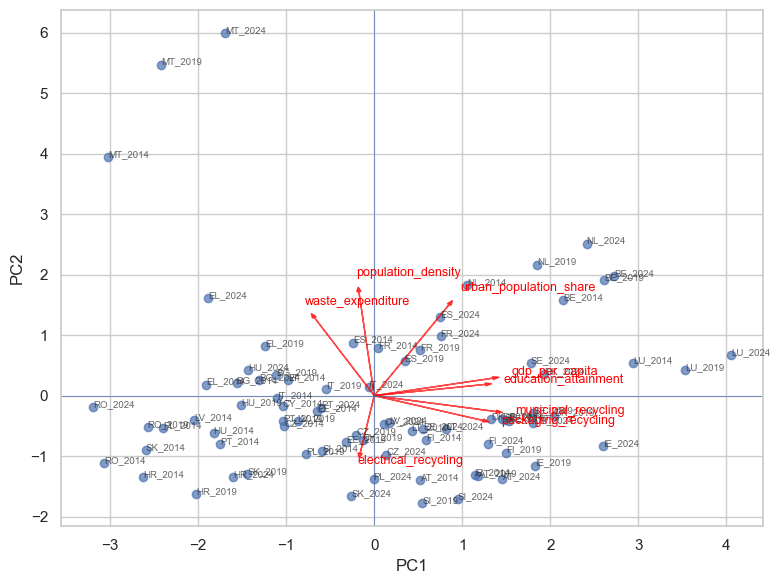

In [452]:
pca_biplot(
    X_pca,
    loadings,
    merged_data_PCA["country_period"].values
)

The five year aggregated data yield a biplot that is broadly comparable to the non-aggregated version. Here, Malta (MT), Romania (RO), Slowakia (SK) and Portugal (PT) in the early periods (2010-2014), Hungary (HU), Latvia (LV) and Croatia (HR) make up the lower end of PC1, indicating lower municipal and packaging recycling rates, as well as lower GDP per capita and education attainment. These counrties are also on the lower side of PC2, hinting at lower population density, waste expenditure and urban population share. In contrast, Luxembourg (LU), Belgium (BE), as well as the Netherlands (NL) and Ireland (IE) in the later periods (2020-2024) positioned at the higher end of PC1, while differing more strongly along PC2. These countries are characterized by higher GDP/capita and education attainment, along side higher municipal and packaging recycling rates.

Nevertheless, the first two principal components still account for only around 60% of the cumulative explained variance, and the interpretation of these patterns should therefore be treated with appropriate caution.

#### PCA aggregated over all years
Finally, this data is also considered without an explicit time dimension by aggregating over the years 2000-2024. This is a large time span, however it seems appropriate to consider country-level averages in this conrtext as well. This should also increase the number of countries included in the PCA, as fewer observations are lost due to missing values. Additionally, this will get rid of multiple scores per country in the biplot, potentially making the interpretation clearer. 

In [453]:
merged_data_PCA = df_merged.copy()

merged_data_PCA = (
    merged_data_PCA
    .groupby("country", as_index=False)[numeric_features]
    .mean()
)

merged_data_PCA = merged_data_PCA.dropna()
merged_data_PCA

,country,packaging_recycling,municipal_recycling,electrical_recycling,gdp_per_capita,urban_population_share,population_density,education_attainment,waste_expenditure
0,AT,66.233333,60.033333,80.300000,60049.088917,58.462167,106.441667,23.135,5.260878
1,BE,78.541667,53.737500,76.294118,56546.365750,97.698875,375.183333,32.695,41.025805
2,BG,57.000000,23.866667,83.233333,22667.619292,72.794875,63.875000,22.200,50.956340
3,CY,49.921053,10.566667,83.720000,41975.575000,67.550917,95.391667,35.430,24.084347
4,CZ,68.052381,20.445833,86.129412,39934.423833,73.681292,137.558333,17.610,29.542087
5,DE,70.383333,63.462500,83.561111,56859.953875,76.716542,232.058333,24.120,17.558741
6,DK,64.304167,44.591304,82.772222,62449.496208,86.892542,136.241667,30.210,3.878023
7,EE,57.360000,22.375000,81.337500,34264.182250,68.753583,30.591667,31.860,21.512037
8,EL,49.895652,15.508333,81.478947,34852.646292,76.752500,82.191667,24.040,59.427445
9,ES,60.200000,32.708333,78.082353,43454.330875,78.803125,93.541667,31.060,50.475434


In [454]:
X = merged_data_PCA.loc[:,features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "explained_variance": explained_var,
    "cumulative_variance": np.cumsum(explained_var)
})

pca_summary

,PC,explained_variance,cumulative_variance
0,PC1,0.373790,0.373790
1,PC2,0.302127,0.675917
2,PC3,0.116857,0.792774
3,PC4,0.080809,0.873583
4,PC5,0.068064,0.941647
5,PC6,0.031696,0.973343
6,PC7,0.015323,0.988666
7,PC8,0.011334,1.000000


When considering the countries over the entire time span the first two principal components already make up for almost 70% of the cumulative explained variance.

In [455]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
packaging_recycling,0.476340,-0.058333,-0.479149,0.014980,-0.312856,-0.061761,0.375610,-0.545081
municipal_recycling,0.498408,0.096601,-0.248978,-0.376538,-0.276689,0.013167,-0.210203,0.646198
electrical_recycling,0.185754,-0.487380,-0.265301,0.276486,0.558329,0.248559,0.318315,0.326022
gdp_per_capita,0.450425,0.165871,0.140751,-0.211396,0.636498,-0.426887,-0.245465,-0.239770
urban_population_share,0.255928,0.495831,-0.012271,0.337841,0.106306,0.684750,-0.274550,-0.137130
population_density,-0.153015,0.560246,-0.003159,-0.365211,0.215394,0.095319,0.675899,0.130394
education_attainment,0.386916,0.103958,0.575647,0.494321,-0.217128,-0.242959,0.332967,0.216161
waste_expenditure,-0.220646,0.389465,-0.535444,0.494969,0.062159,-0.463682,-0.100347,0.197494


Looking at the loadings can give a hint as to what contributes to each principal component. The first principal component is influenced most strongly by packaging and municipal recycling, GDP/capita and education attainment. In comparison the urban population share, population density and waste expenditure of the countries influence the second principal component most. 

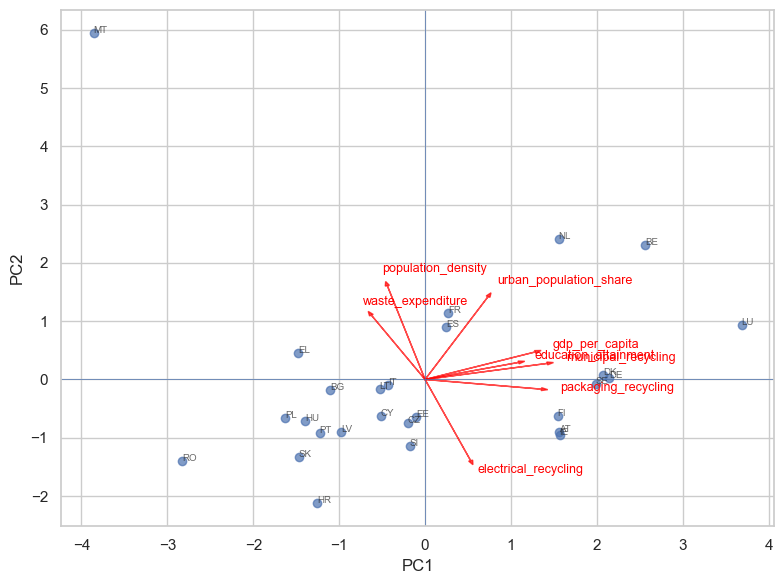

In [456]:
def pca_biplot(X_pca, loadings, labels, scale=3):
    
    plt.figure(figsize=(8, 6))

    # Scores
    plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)

    for i, label in enumerate(labels):
        plt.text(
            X_pca[i, 0],
            X_pca[i, 1],
            label,
            fontsize=7,
            alpha=0.7
        )

    # Loadings
    for var in loadings.index:
        x = loadings.loc[var, "PC1"] * scale
        y = loadings.loc[var, "PC2"] * scale

        plt.arrow(
            0, 0, x, y,
            color="red",
            alpha=0.7,
            head_width=0.05,
            length_includes_head=True
        )
        plt.text(
            x * 1.1,
            y * 1.1,
            var,
            color="red",
            fontsize=9
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.tight_layout()
    plt.show()


pca_biplot(
    X_pca,
    loadings,
    merged_data_PCA["country"].values
)

Here we can see the visualization of the first two principal components in a Bi-plot. Countries are represented by multiple scores, as the year variable is not handled, so each point represents the countries in a certain year. From the plot one can read that GDP/capita and education attainment are positively correlated with packaging and municipal recycling. Population density and waste expenditure are also positively correlated. 

No clear clusters emerge from the plot with the exception of MT (Malta) which differs strongly from the other group along PC2, so it differs in population density, urban population share and waste expenditure from the others. A small cluster could also be seen in the Netherlands (NL), Belgium (BE) and Luxemburg (LU), however it is not as clear as with Malta.

#### PCA aggregated over every 5 years
In order to reduce the time dimensions, all the countries are aggregated over every five years. Since this still produces quite a few missing values which is a problem for PCA, the rows with missing values are dropped. This is argued to be fine, since this is an exploratory attempt to find similarities between countries that have high recycling numbers. 

In [457]:
merged_data_PCA = df_merged.copy()

merged_data_PCA["period_start"] = 2000 + ((merged_data_PCA["year"] - 2000)//5) *5
merged_data_PCA["period_end"] = merged_data_PCA["period_start"] + 4
merged_data_PCA["country_period"] = (
    merged_data_PCA["country"] + "_" +
    merged_data_PCA["period_end"].astype(str)
) # only attach period end for readability in plot

numeric_features = [
    "packaging_recycling",
    "municipal_recycling",
    "electrical_recycling",
    "gdp_per_capita",
    "urban_population_share",
    "population_density",
    "education_attainment",
    "waste_expenditure"
]

merged_data_PCA = (
    merged_data_PCA
    .groupby("country_period", as_index=False)[numeric_features]
    .mean()
)

merged_data_PCA = merged_data_PCA.dropna()

features = [
    "packaging_recycling",
    "municipal_recycling",
    "electrical_recycling",
    "gdp_per_capita",
    "urban_population_share",
    "population_density",
    "education_attainment",
    "waste_expenditure"
]
X = merged_data_PCA.loc[:,features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "explained_variance": explained_var,
    "cumulative_variance": np.cumsum(explained_var)
})

pca_summary

,PC,explained_variance,cumulative_variance
0,PC1,0.348441,0.348441
1,PC2,0.243044,0.591485
2,PC3,0.118996,0.710480
3,PC4,0.115753,0.826234
4,PC5,0.076484,0.902718
5,PC6,0.037649,0.940366
6,PC7,0.031883,0.972249
7,PC8,0.027751,1.000000


Aggregating over the years has lead to the first two principal components being able to account for almost 60% of the explained variance, now only 5 PCs would be needed in order to explain 90% of the variability. 

In [458]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
packaging_recycling,0.435116,-0.144579,0.326175,-0.503102,0.020566,-0.013022,-0.084821,0.649986
municipal_recycling,0.486334,-0.092541,0.222579,-0.203448,-0.470760,-0.084024,0.355698,-0.555686
electrical_recycling,-0.057577,-0.342342,0.698356,0.503705,0.277395,-0.147116,0.198046,0.015944
gdp_per_capita,0.473271,0.101538,0.031292,0.450239,-0.088329,0.671700,-0.320718,0.012957
urban_population_share,0.296145,0.524334,0.178957,0.041872,0.261536,-0.512090,-0.474142,-0.219419
population_density,-0.060683,0.598756,0.097753,0.299238,-0.437394,-0.130609,0.393481,0.418940
education_attainment,0.445645,0.065640,-0.400270,0.108647,0.568069,-0.043968,0.545498,0.053565
waste_expenditure,-0.238473,0.453081,0.391906,-0.382051,0.332861,0.488588,0.216784,-0.204414


The loadings paint a similar picture as before, PC1 is influenced mostly by packaging and municipal recycling, GDP/capita and education attainment. Again, PC2 is influenced by urban population share, population density, waste expenditure but also electrical recycling. 

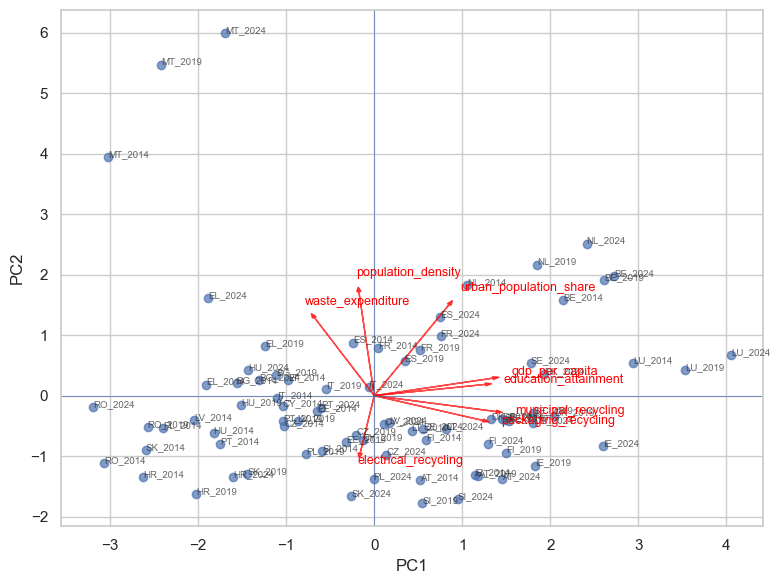

In [459]:
pca_biplot(
    X_pca,
    loadings,
    merged_data_PCA["country_period"].values
)

The data aggregated over 5 years shows a similar Bi-plot as before for the data without the aggregation. Here, Malta, Romania (RO), Poland (PO), Hungary (HU), Latvia (LV) and Kroatia (HR) make up the lower end of PC1, meaning lower municipal and packaging recycling rates, but also lower GDP/capita, education attainment. These counrties are also on the lower side of PC2, hinting at lower population density, waste expenditure and urban population share. Luxemburg (LU), Belgium (BE), as well as the Netherlands (NL) and Ireland (IE) in the later years (2020-2024) are on the higher end of PC1, while differing quite a bit along PC2. These countries have a higher GDP/capita and education attainment, as well as higher municipal and packaging recycling rates. 

Again, the first principal components only make up around 60% of the cumulative explained variance, so these findings should be weighted accordingly. 

#### PCA aggregated over all years
Finally, this data is also considered without the time element, aggregating over the years 2000-2024. This is a large time span, however it seems appropriate to consider the averages as well - this should also increase the number of countries considered in the PCA, as less will fall away due to missing values. This will get rid of the multiple country scores in the plot, perhaps making the interpretation clearer. 

In [460]:
merged_data_PCA = df_merged.copy()

merged_data_PCA = (
    merged_data_PCA
    .groupby("country", as_index=False)[numeric_features]
    .mean()
)

merged_data_PCA = merged_data_PCA.dropna()
merged_data_PCA

,country,packaging_recycling,municipal_recycling,electrical_recycling,gdp_per_capita,urban_population_share,population_density,education_attainment,waste_expenditure
0,AT,66.233333,60.033333,80.300000,60049.088917,58.462167,106.441667,23.135,5.260878
1,BE,78.541667,53.737500,76.294118,56546.365750,97.698875,375.183333,32.695,41.025805
2,BG,57.000000,23.866667,83.233333,22667.619292,72.794875,63.875000,22.200,50.956340
3,CY,49.921053,10.566667,83.720000,41975.575000,67.550917,95.391667,35.430,24.084347
4,CZ,68.052381,20.445833,86.129412,39934.423833,73.681292,137.558333,17.610,29.542087
5,DE,70.383333,63.462500,83.561111,56859.953875,76.716542,232.058333,24.120,17.558741
6,DK,64.304167,44.591304,82.772222,62449.496208,86.892542,136.241667,30.210,3.878023
7,EE,57.360000,22.375000,81.337500,34264.182250,68.753583,30.591667,31.860,21.512037
8,EL,49.895652,15.508333,81.478947,34852.646292,76.752500,82.191667,24.040,59.427445
9,ES,60.200000,32.708333,78.082353,43454.330875,78.803125,93.541667,31.060,50.475434


In [461]:
X = merged_data_PCA.loc[:,features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_var))],
    "explained_variance": explained_var,
    "cumulative_variance": np.cumsum(explained_var)
})

pca_summary

,PC,explained_variance,cumulative_variance
0,PC1,0.373790,0.373790
1,PC2,0.302127,0.675917
2,PC3,0.116857,0.792774
3,PC4,0.080809,0.873583
4,PC5,0.068064,0.941647
5,PC6,0.031696,0.973343
6,PC7,0.015323,0.988666
7,PC8,0.011334,1.000000


When considering the countries over the entire time span, the first two principal components account for almost 70% of the cumulative variance.

In [462]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
packaging_recycling,0.476340,-0.058333,-0.479149,0.014980,-0.312856,-0.061761,0.375610,-0.545081
municipal_recycling,0.498408,0.096601,-0.248978,-0.376538,-0.276689,0.013167,-0.210203,0.646198
electrical_recycling,0.185754,-0.487380,-0.265301,0.276486,0.558329,0.248559,0.318315,0.326022
gdp_per_capita,0.450425,0.165871,0.140751,-0.211396,0.636498,-0.426887,-0.245465,-0.239770
urban_population_share,0.255928,0.495831,-0.012271,0.337841,0.106306,0.684750,-0.274550,-0.137130
population_density,-0.153015,0.560246,-0.003159,-0.365211,0.215394,0.095319,0.675899,0.130394
education_attainment,0.386916,0.103958,0.575647,0.494321,-0.217128,-0.242959,0.332967,0.216161
waste_expenditure,-0.220646,0.389465,-0.535444,0.494969,0.062159,-0.463682,-0.100347,0.197494


The interpretation of the loadings for the first two principal components stay largely unchanged. However, for the first principal component, the variables that had less influence in the previous cases now influence it more strongly. For the second principal component, urban population share and population density stay the most influencial variables, with electrical recycling and waste expenditure also playing an important role.

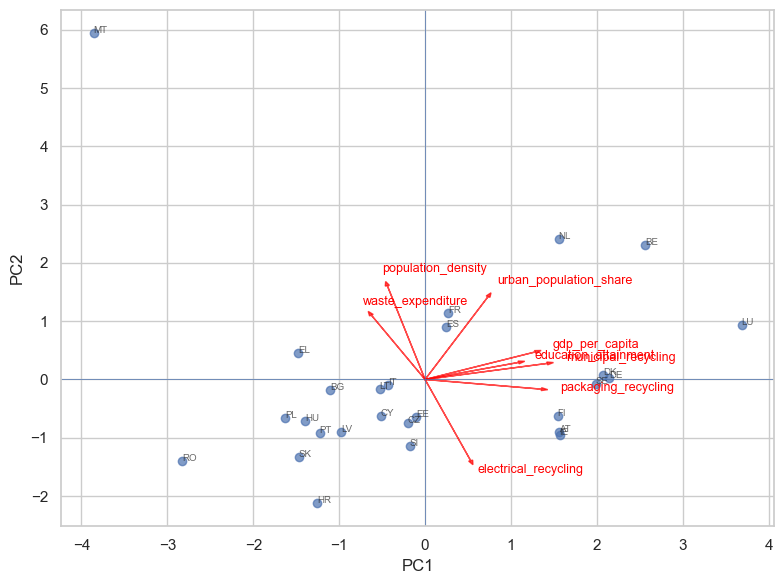

In [463]:
pca_biplot(
    X_pca,
    loadings,
    merged_data_PCA["country"].values
)

This final biplot suggest the presence of two groups (seperated mostly by PC1), though they are not clearly seperable, as well as a definite outlier, Malta (MT). The Netherlands (NL), Belgium (BE) and Luxembourg (LU) show one end of the spectrum, characterized by high GDP per capita, education attainment and municipal and packaging recycling rates, as well as a higher urban poplation share. On the other side of the spectrum are Romania (RO), Hungary (HU), Poland (PL), Slovakia (SK) and Kroatia (HR). Overall, the PCA allows for a nice visualization of the different characteristics across the countries and suggests that higher GDP/capita, education attainment and urban population share are positively correlated with municipal and packaging recycling rates, while population density and waste expenditure are negatively correlated with electrical recycling. 

This final biplot suggests the presence of two broad groups, separated primarily along the first principal component, although these groups are not clearly separable, as well as one distinct outlier, Malta (MT). The Netherlands (NL), Belgium (BE), and Luxembourg (LU) occupy one end of the spectrum, characterized by high GDP per capita, educational attainment, and municipal and packaging recycling rates, as well as a higher urban population share. On the opposite end are Romania (RO), Hungary (HU), Poland (PL), and Croatia (HR). Overall, the PCA allows for a clear visualization of cross-country differences and suggests that higher GDP per capita, educational attainment, and urban population share are positively correlated with municipal and packaging recycling rates, while population density and waste expenditure appear to be negatively correlated with electrical recycling.

### Summary
* GDP/capita, education attainment and urban population share are positively correlated to municipal and packaging recycling.
* PCA seperates countries along the first principal component, largely through GDP/capita, education attainment, municipal and packaging recycling and urban population share. Along the second principal component countries are seperated largely by population density, urban population share, waste expenditure and electrical recycling.
* PCA highlights cross-country heterogeneity, with higher-income and more urbanized countries tending to exhibit higher recycling rates.
* Malta differs highly from the other countries in its characteristics according to the PCA

### 7.3. Hierarchical Clustering
Hierarchical clustering appears to be an appropriate method to use alongside PCA. While PCA provides a continuous representation of similarities between countries, clustering allows for the identification of discrete groups with broadly similar characteristics. This may help to support assumptions about which structural characteristics are associated with higher recycling rates. For this analysis, the data aggregated over all years are used in order to retain as many countries as possible.

The clustering is performed using Ward’s method on the scaled original variables.

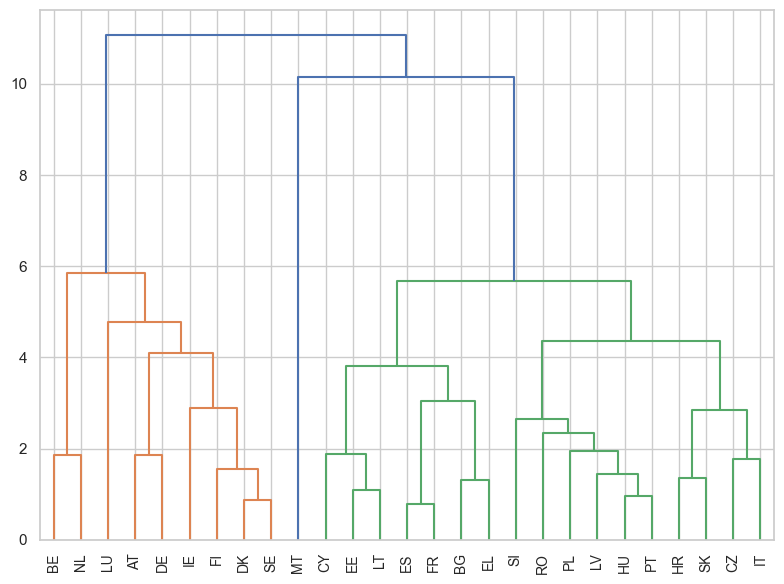

In [464]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(8, 6))
dendrogram(
    Z,
    labels=merged_data_PCA["country"].values,
    leaf_rotation=90
)
plt.tight_layout()
plt.show()

Upon first glance of the dendogram given from the hierarchical clustering shows three clusters. These broadly align with the patterns observed in the PCA, with Luxemburg (LU), the Netherlands (NL), Belgium (BE) etc. building one end of the spectrum and Romania (RO), Kroatia (HR) etc. building the other end of the spectrum. Seeing these clusters on the bi-plot (shown below) shows the similarity of the clusters found in the PCA analysis above.

In [465]:
merged_data_PCA["cluster"] = fcluster(Z, t=3, criterion="maxclust")

cluster_counts = ( 
    merged_data_PCA 
    .groupby("cluster") 
    .size() 
    .rename("n_observations") 
)
print(cluster_counts)

cluster_summary = (
    merged_data_PCA
    .select_dtypes(include="number")
    .groupby("cluster")
    .agg(["mean", "std"])
)
cluster_summary

cluster
1     9
2    17
3     1
Name: n_observations, dtype: int64


packaging_recycling           municipal_recycling             \
                       mean       std                mean        std   
cluster                                                                
1                 65.769444  6.672867           48.035900  10.211423   
2                 55.279972  5.932287           22.276019   8.123130   
3                 32.425000       NaN           10.325000        NaN   

        electrical_recycling           gdp_per_capita                \
                        mean       std           mean           std   
cluster                                                               
1                  82.556506  3.656143   68073.050208  23630.672578   
2                  81.898052  4.347654   35238.457510   7842.013856   
3                  61.857895       NaN   41810.897583           NaN   

        urban_population_share            population_density              \
                          mean        std               mean         std   
cluster                                                                    
1                    80.817829  12.927111         188.983333  165.260858   
2                    66.452686   8.590480          94.282353   41.348098   
3                    94.035292        NaN        1522.433333         NaN   

        education_attainment           waste_expenditure             
                        mean       std              mean        std  
cluster                                                              
1                  30.778889  4.475011         19.164017  20.016088  
2                  23.448235  6.541432         32.100164  14.718367  
3                  19.160000       NaN         65.963616        NaN

Examining the cluster-wise averages confirms the patterns suggested by the PCA. The two main clusters are of similar size, making a comparison of averages meaningful. Cluster 1, which includes Luxemburg, Belgium, Austria etc., sports higher average packaging recycling rates and approximately double the average municipal recycling rates compared to Cluster 2, which includes Romania, Croatia, Hungary etc. In terms of electrical recycling both clusters show similar averages. The countries in Cluster 1 also show almost double the average GDP/capita, as well as a higher average urban population share and education attainment. An unexpected result is the population density, which differs from what the PCA seemed to show, where the average is higher for Cluster 1 over Cluster 2. The standard deviations show that there is substancial variety and heterogeneity within the clusters as well.

The third cluster, which only contains Malta, differs quite heavily from the other groups - Malta shows significantly lower recycling rates across all three waste types. While its GDP/capita is not out of the ordinary for either clusters, it has a very high urban population share and population density likely due to its small land area. Another strong difference that destinguishes it from the other clusters is its waste expenditure, which is very high - this might be due it being a small island state, though this interpretation remains speculative.

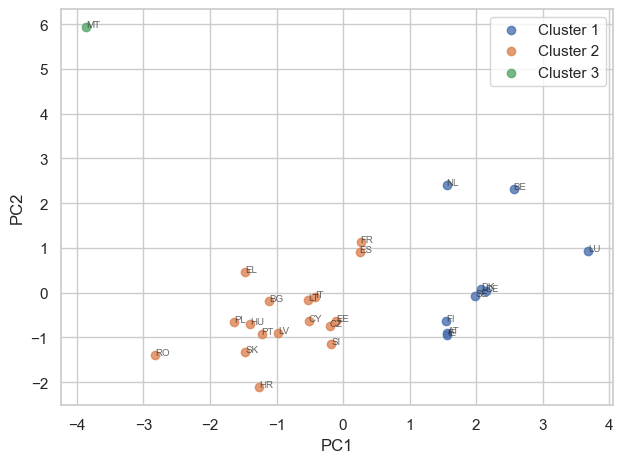

In [466]:
clusters = np.unique(merged_data_PCA["cluster"])
 
for cluster in clusters:
    mask = merged_data_PCA["cluster"] == cluster
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        alpha=0.8,
        label=f"Cluster {cluster}"
    )
 
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
 
for i, label in enumerate(merged_data_PCA["country"]):
    plt.text(
        X_pca[i, 0],
        X_pca[i, 1],
        label,
        fontsize=7,
        alpha=0.7
    )
    
plt.tight_layout()
plt.show()

### Summary
* From hierarcical clustering three clusters emerge. Cluster 1 is characterized by higher average recycling rates alongside higher GDP per capita, population density, urban population share and educational attainment, as well as lower waste expenditure.
* Malta emerges as a distinct outlier, with comparatively low recycling rates and very high waste expenditure, population density, and urban population share. 

While PCA and hierarchical clustering highlight across-country patterns in recycling within the EU, these methods are exploratory and descriptive, sensitive to scaling, variable selection, and data aggregation, and do not establish causal relationships, but they provide a clear summary of structural factors linked to recycling performance.

# 8. How well can thedevelopment of the amount of recycling be predicted?

In [467]:
df = df_merged_miss_all.copy()
policy_years_cols = ['WFD', 'WEEE_Directive_1', 'WEEE_Directive_2', 'WEEE_Directive_3', 'WEEE_Directive_4', 'RoHS_1', 'RoHS_2', 
                    'BL', 'EOLVD', 'LFD_1', 'LFD_2', 'SUP', 'CEAP_1', 'CEAP_2', 'CEAP_3', 'DRS', 'PT']
df["policy_count"] = (df[policy_years_cols] > 0).sum(axis=1)
df = df.drop(policy_years_cols, axis = 1)
df = df[df['country'] != "EU27_2020"]

df_mun = df.drop(['packaging_recycling', 'electrical_recycling'],axis = 1)
df_mun = df_mun.dropna(subset=["municipal_recycling"])
df_mun = df_mun.sort_values(["country", "year"]).copy()

df_elec = df.drop(['municipal_recycling', 'packaging_recycling'],axis = 1)
df_elec = df_elec.dropna(subset=["electrical_recycling"])
df_elec = df_elec.sort_values(["country", "year"]).copy()

df_pack = df.drop(['municipal_recycling', 'electrical_recycling'],axis = 1)
df_pack = df_pack.dropna(subset=["packaging_recycling"])
df_pack = df_pack.sort_values(["country", "year"]).copy()

## 8.2. Simple linear regression
We started by a simple linear regression. The plan was to later expand on that by doing a panel regression, but the results were a lot worse, so in this notebook we will only show the simple linear regression.
All years until 2018, are training years and I will try to predict the recycling rate for the later years.
I do start with a simple linear regression and I will build on that later.
I tried if it woulf have a big effect to remove the country and the year,

### 6.1.1.Creation of the models ###

In [468]:
num_cols = [
    'gdp_per_capita',
    'urban_population_share',
    'population_density',
    'education_attainment',
    'waste_expenditure'
]

In [469]:
def run_ols_three_specs(
    df,
    response_var,
    country_col="country",
    year_col="year",
    train_end_year=2018
):
    """
    Fits three OLS models:
    1) With country and year
    2) With country only (no year)
    3) With year only (no country)
    """

    
    # Create dummies for country
    df_cy = df.copy()
    df_cy = pd.get_dummies(
        df_cy,
        columns=[country_col],
        drop_first=True,
        dtype=int
    )

    # Train/test split
    train = df_cy[df_cy[year_col] <= train_end_year].copy()

   
   ### With country and year
    X_cy = train.drop(response_var, axis=1)
    y = train[response_var]

    X_cy = sm.add_constant(X_cy)
    model_cy = sm.OLS(y, X_cy).fit()

    
    ### Without year ###
    X_c = train.drop(
        columns=[response_var, year_col]
    )

    X_c = sm.add_constant(X_c)
    model_c = sm.OLS(y, X_c).fit()

    ### without country
    X_y = train.drop(
        columns=[response_var] +
        [c for c in train.columns if c.startswith(country_col)]
    )

    X_y = sm.add_constant(X_y)
    model_y = sm.OLS(y, X_y).fit()

    return model_cy, model_c, model_y

In [470]:
res_mun_cy, res_mun_c, res_mun_y = run_ols_three_specs(
    df_mun,
    response_var="municipal_recycling"
)

print(res_mun_cy.summary())
print(res_mun_c.summary())
print(res_mun_y.summary())


                             OLS Regression Results                            
Dep. Variable:     municipal_recycling   R-squared:                       0.916
Model:                             OLS   Adj. R-squared:                  0.910
Method:                  Least Squares   F-statistic:                     155.5
Date:                 Wed, 07 Jan 2026   Prob (F-statistic):          1.19e-229
Time:                         15:29:52   Log-Likelihood:                -1548.9
No. Observations:                  503   AIC:                             3166.
Df Residuals:                      469   BIC:                             3309.
Df Model:                           33                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const             

In [471]:
res_elec_cy, res_elec_c, res_elec_y = run_ols_three_specs(
    df_elec,
    response_var="electrical_recycling"
)

print(res_elec_cy.summary())
print(res_elec_c.summary())
print(res_elec_y.summary())

                             OLS Regression Results                             
Dep. Variable:     electrical_recycling   R-squared:                       0.384
Model:                              OLS   Adj. R-squared:                  0.314
Method:                   Least Squares   F-statistic:                     5.497
Date:                  Wed, 07 Jan 2026   Prob (F-statistic):           1.58e-16
Time:                          15:29:52   Log-Likelihood:                -1207.2
No. Observations:                   325   AIC:                             2482.
Df Residuals:                       291   BIC:                             2611.
Df Model:                            33                                         
Covariance Type:              nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const   

In [472]:
res_pack_cy, res_pack_c, res_pack_y = run_ols_three_specs(
    df_pack,
    response_var="packaging_recycling"
)
print(res_pack_cy.summary())
print(res_pack_c.summary())
print(res_pack_y.summary())

                             OLS Regression Results                            
Dep. Variable:     packaging_recycling   R-squared:                       0.774
Model:                             OLS   Adj. R-squared:                  0.756
Method:                  Least Squares   F-statistic:                     43.40
Date:                 Wed, 07 Jan 2026   Prob (F-statistic):          4.23e-114
Time:                         15:29:52   Log-Likelihood:                -1485.0
No. Observations:                  453   AIC:                             3038.
Df Residuals:                      419   BIC:                             3178.
Df Model:                           33                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const             

### Result comparison ###

In the training data, missing values were filled using backward filling, as the time series were generally short and missing values occurred primarily at the beginning of the series. This approach preserves the temporal structure of the data and avoids introducing artificial variability.

In the test data, missing values were handled using median imputation combined with missing-value indicators to avoid information leakage from future observations and to ensure stable model evaluation.

In [473]:
def result_analysis(
    test_set,
    response_var,
    results,
    continuous_vars=None
):
    """
    Evaluate OLS model on test data using a fitted statsmodels result.
    """

    test = test_set.copy()

    if continuous_vars is None:
        continuous_vars = [
            'gdp_per_capita',
            'urban_population_share',
            'population_density',
            'education_attainment',
            'waste_expenditure'
        ]

    # Missing-value handling
    for col in continuous_vars:
        if col in test.columns:
            test[col + "_missing"] = test[col].isna().astype(int)
            test[col] = test[col].fillna(test[col].median())

    # Prepare X and y
    y_test = test[response_var]
    X_test = test.drop(columns=[response_var])

    # Add constant
    X_test = sm.add_constant(X_test, has_constant="add")

    # Align columns with training design matrix
    X_test = X_test.reindex(
        columns=results.model.exog_names,
        fill_value=0
    )

    # Prediction
    y_pred = results.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics = pd.DataFrame({
        "RMSE": [rmse],
        "MAE": [mae],
        "R2": [r2]
    })

    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R²:   {r2:.3f}")

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Observed vs predicted
    axes[0].scatter(y_test, y_pred, alpha=0.6)
    axes[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--",
        color="red"
    )
    axes[0].set_xlabel("Observed values")
    axes[0].set_ylabel("Predicted values")
    axes[0].set_title("Observed vs Predicted")

    # Residuals vs fitted
    residuals = y_test - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.6)
    axes[1].axhline(0, linestyle="--", color="red")
    axes[1].set_xlabel("Predicted values")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title("Residuals vs Fitted")

    plt.tight_layout()
    plt.show()

    return metrics


RMSE: 10.91
MAE:  9.26
R²:   0.479


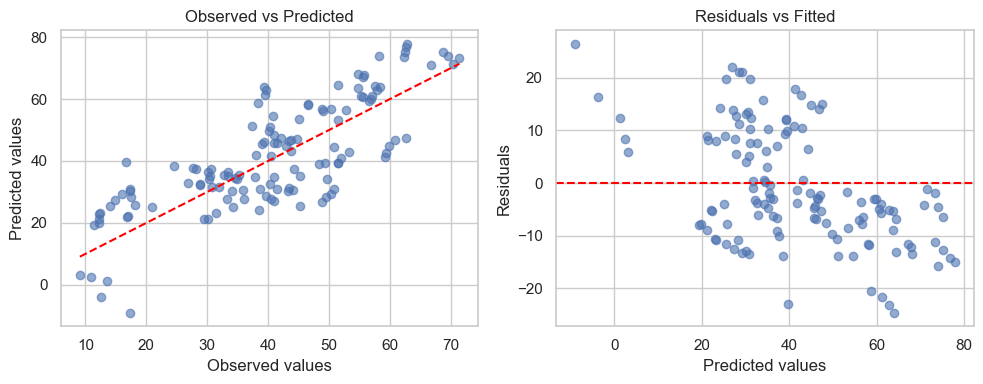

RMSE: 10.81
MAE:  9.23
R²:   0.489


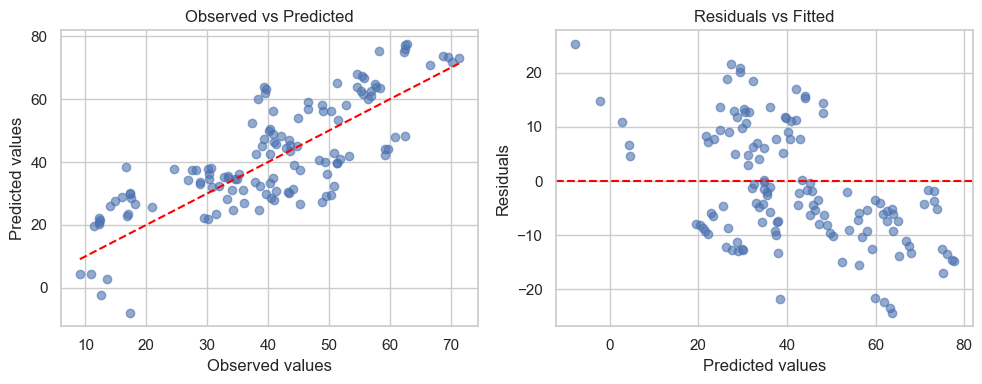

RMSE: 14.39
MAE:  11.73
R²:   0.094


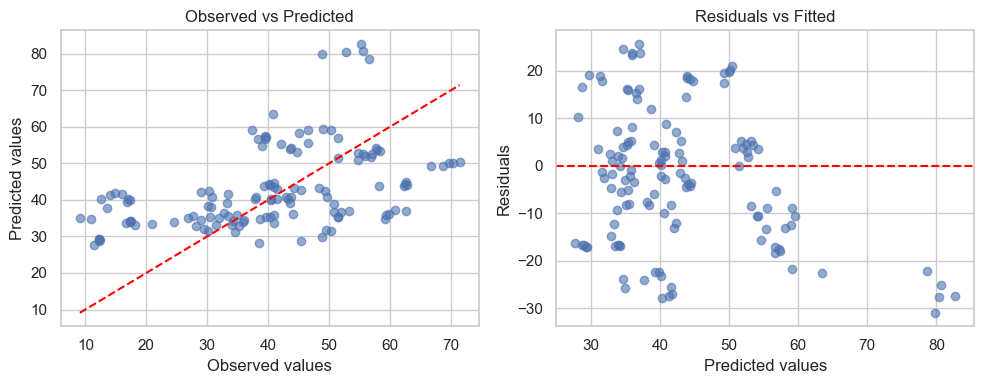

,RMSE,MAE,R2
0,14.391918,11.729924,0.093825


In [474]:
train_mun = df_mun[df_mun['year'] <= 2018].copy()
test_mun  = df_mun[df_mun['year'] > 2018].copy()
train_mun_dummy = pd.get_dummies(
    train_mun,
    columns=['country'],
    drop_first=True,
    dtype=int
)
test_mun_dummy = pd.get_dummies(
    test_mun,
    columns=['country'],
    drop_first=True,
    dtype=int
)
X_test = sm.add_constant(test_mun_dummy.drop('municipal_recycling', axis=1))
X_test = X_test.reindex(columns=res_mun_cy.model.exog_names, fill_value=0)

for col in train_mun_dummy.columns:
    if col.startswith("country_") and col not in test_mun_dummy.columns:
        test_mun_dummy[col] = 0  

for col in train_mun_dummy.columns:
    if col not in test_mun_dummy.columns:
        test_mun_dummy[col] = 0 

result_analysis(
    test_set=test_mun_dummy,
    response_var="municipal_recycling",
    results=res_mun_cy
)

result_analysis(
    test_set=test_mun_dummy,
    response_var="municipal_recycling",
    results=res_mun_c
)

result_analysis(
    test_set=test_mun_dummy,
    response_var="municipal_recycling",
    results=res_mun_y
)


RMSE: 11.70
MAE:  8.38
R²:   -1.535


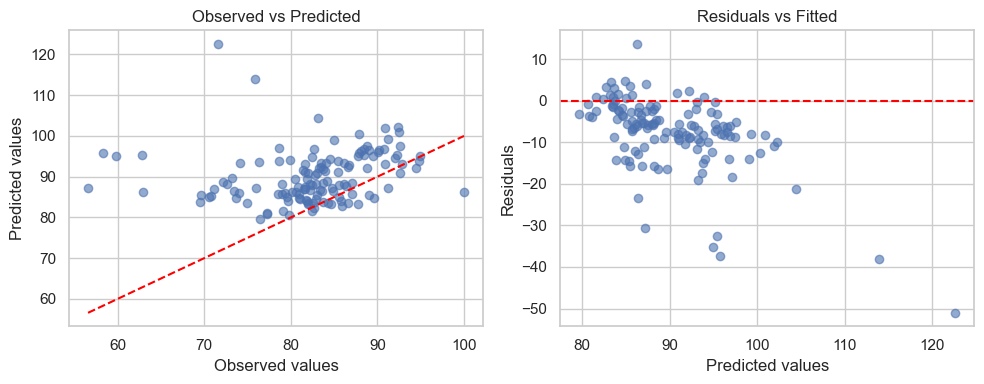

RMSE: 44.56
MAE:  40.22
R²:   -35.765


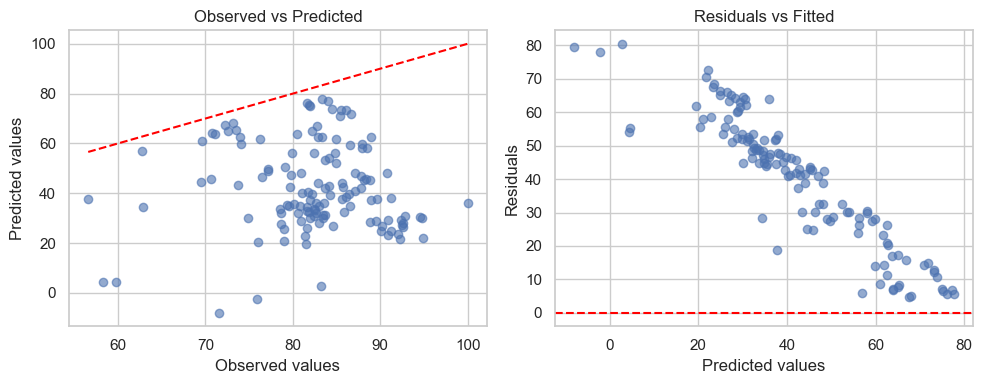

RMSE: 11.75
MAE:  10.02
R²:   -1.558


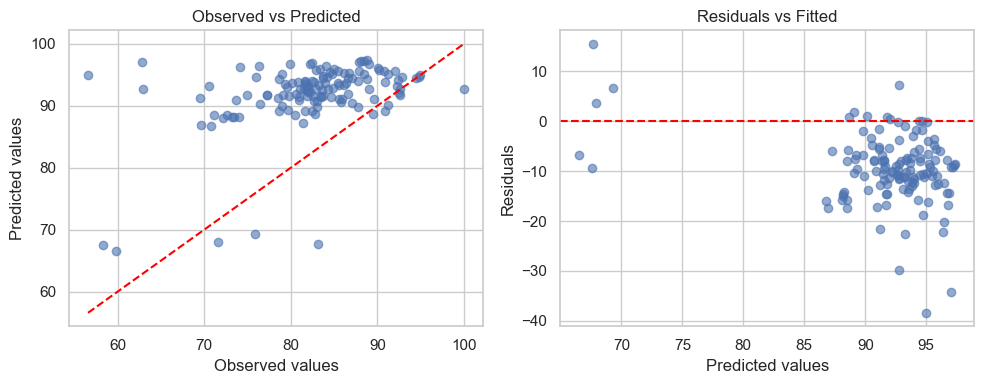

,RMSE,MAE,R2
0,11.753373,10.022237,-1.558073


In [475]:
train_elec = df_elec[df_elec['year'] <= 2018].copy()
test_elec  = df_elec[df_elec['year'] > 2018].copy()
train_elec_dummy = pd.get_dummies(
    train_elec ,
    columns=['country'],
    drop_first=True,
    dtype=int
)
test_elec_dummy = pd.get_dummies(
    test_elec ,
    columns=['country'],
    drop_first=True,
    dtype=int
)
X_test = sm.add_constant(test_elec_dummy.drop('electrical_recycling', axis=1))
X_test = X_test.reindex(columns=res_elec_cy.model.exog_names, fill_value=0)

for col in train_elec_dummy.columns:
    if col.startswith("country_") and col not in test_elec_dummy.columns:
        test_elec_dummy[col] = 0  

for col in train_elec_dummy.columns:
    if col not in test_elec_dummy.columns:
        test_elec_dummy[col] = 0 

result_analysis(
    test_set=test_elec_dummy,
    response_var="electrical_recycling",
    results=res_elec_cy
)

result_analysis(
    test_set=test_elec_dummy,
    response_var="electrical_recycling",
    results=res_mun_c
)

result_analysis(
    test_set=test_elec_dummy,
    response_var="electrical_recycling",
    results=res_elec_y
)

RMSE: 12.40
MAE:  10.53
R²:   -0.432


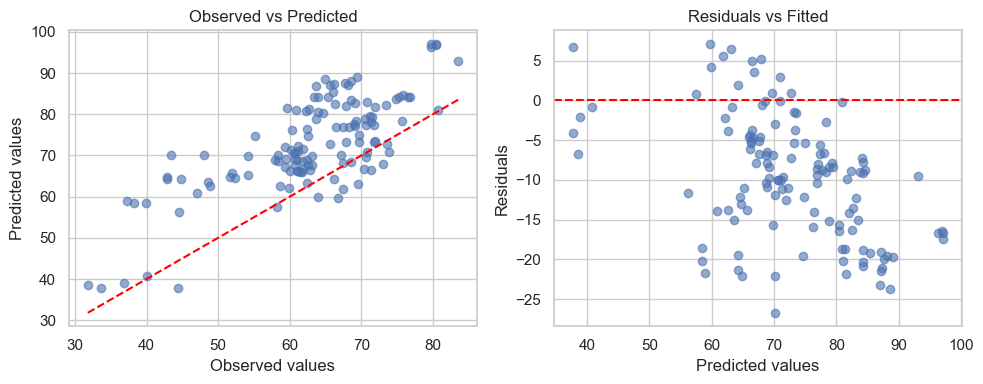

RMSE: 12.64
MAE:  10.88
R²:   -0.488


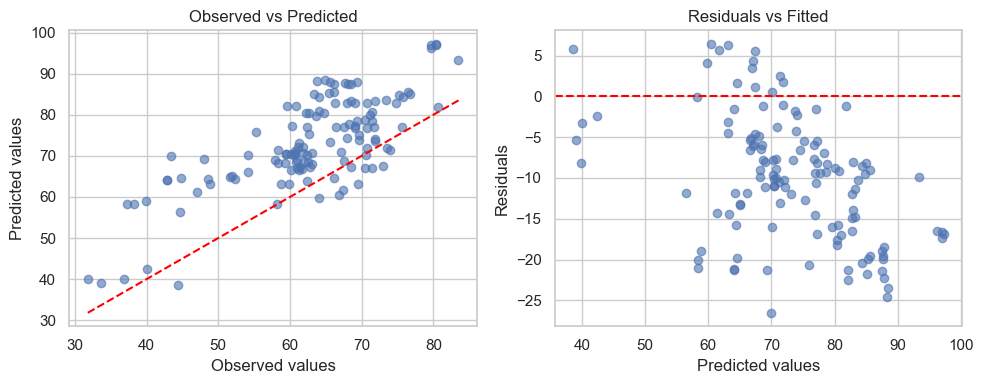

RMSE: 13.21
MAE:  10.59
R²:   -0.624


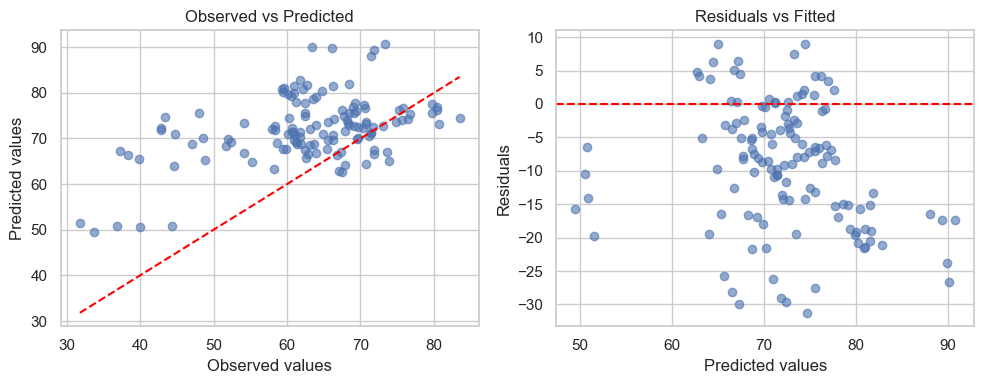

In [476]:
train_pack = df_pack[df_pack['year'] <= 2018].copy()
test_pack  = df_pack[df_pack['year'] > 2018].copy()

train_pack_dummy = pd.get_dummies(
    train_pack,
    columns=['country'],
    drop_first=True,
    dtype=int
)

test_pack_dummy = pd.get_dummies(
    test_pack,
    columns=['country'],
    drop_first=True,
    dtype=int
)

X_test = sm.add_constant(test_pack_dummy.drop('packaging_recycling', axis=1))
X_test = X_test.reindex(
    columns=res_pack_cy.model.exog_names,  
    fill_value=0
)

for col in train_pack_dummy.columns:
    if col.startswith("country_") and col not in test_pack_dummy.columns:
        test_pack_dummy[col] = 0

for col in train_pack_dummy.columns:
    if col not in test_pack_dummy.columns:
        test_pack_dummy[col] = 0


metrics_pack_cy = result_analysis(
    test_set=test_pack_dummy,
    response_var="packaging_recycling",
    results=res_pack_cy
)

metrics_pack_c = result_analysis(
    test_set=test_pack_dummy,
    response_var="packaging_recycling",
    results=res_pack_c
)

metrics_pack_y = result_analysis(
    test_set=test_pack_dummy,
    response_var="packaging_recycling",
    results=res_pack_y
)


Municipal waste and packaging_waste can be predicted decently well, while electrical waste does not work well. It is important to leave in the country as otherwise the results get worse. This could be because of other country specific characteristics that we did not include in the model. The fact that electrical waste is worse could be due to the fact that we have less data. I will now als test a time Series model where we forecast only based on the time series itself, to see if that improves the model or makes it worse.
For this I seperated by country. For Austri I will demonstate all of the steps with examples. For the other countries I will just calculate the final metrics.

## Time Series Models
for our time series models we check the stationarity, and the the ordes, before we calculate an ARIMA model. 

In [477]:
def check_stationarity(country, dataset, response_var, d=0):

    ### Select data ###
    df = dataset[dataset['country'] == country]
    mun_w = df[['year', response_var]]
    mun_w = mun_w.set_index('year')

    # Apply differencing if d > 0
    y = mun_w[response_var].copy()
    for _ in range(d):
        y = y.diff().dropna()

    ### Plot ###
    if d == 0:
        plt.figure(figsize=(4,3))
        plt.plot(y, marker='o')
        plt.ylim(0, 100)
        plt.xlabel('Year')
        plt.ylabel(f'{country} (%)')
        plt.title(f'Stationarity check (d={d})')
        plt.show()
    else:
        plt.figure(figsize=(4,3))
        plt.plot(y, marker='o')
        plt.ylim()
        plt.xlabel('Year')
        plt.ylabel(f'{country} (%)')
        plt.title(f'Stationarity check (d={d})')
        plt.show()

    ### Means & Variances ###
    values = y.values
    parts = int(len(values) / 3)

    part_1 = values[0:parts]
    part_2 = values[parts:2*parts]
    part_3 = values[2*parts:3*parts]

    mean_1, mean_2, mean_3 = part_1.mean(), part_2.mean(), part_3.mean()
    var_1, var_2, var_3 = part_1.var(), part_2.var(), part_3.var()

    print(f'mean1={mean_1:.4f}, mean2={mean_2:.4f}, mean3={mean_3:.4f}')
    print(f'var1={var_1:.4f}, var2={var_2:.4f}, var3={var_3:.4f}')

    ### Augmented Dickey-Fuller test ###
    res = adfuller(values)

    print(f'ADF Statistic: {res[0]:.6f}')
    print(f'p-value: {res[1]:.6f}')
    print('Critical values:')
    for k, v in res[4].items():
        print(f'  {k}: {v:.3f}')

    return mun_w



In [478]:

def check_orders(y, x, year, response_var, p_range, q_range, d):
    
    warnings.filterwarnings("ignore", category=UserWarning)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3))  

    plot_acf(y, ax=axes[0], lags=6)
    axes[0].set_title('ACF')

    plot_pacf(y, ax=axes[1], lags=6)
    axes[1].set_title('PACF')
    plt.tight_layout()
    plt.show()


    results = []
    for p, q in itertools.product(range(1,p_range), range(1, q_range)):
        try:
            model = ARIMA(y, order=(p, d, q))
            res = model.fit()
            results.append({
                'p': p,
                'q': q,
                'AIC': res.aic,
                'BIC': res.bic
            })
        except:
            pass

    results_df = pd.DataFrame(results)
    print(results_df.sort_values('AIC', ascending = True).head(5))

In [479]:
def arima_model(y, x, p, d, q, title):
    
    model = ARIMA(y, order=(p, d, q))
    model_fit = model.fit()

    forecast_res = model_fit.get_forecast(steps=5)
    forecast_mean = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int()

    print(forecast_mean)
    print(conf_int)

    naive = y[y.index == '2018-01-01']
    naive = pd.Series(np.repeat(naive, len(forecast_mean)))
    naive.index = forecast_mean.index

    rolling_forecast = []
    history = y.tolist()

    h = len(naive)     
    window = 3
    for _ in range(h):
        next_forecast = np.mean(history[-window:])
        rolling_forecast.append(next_forecast)
        history.append(next_forecast)

    rolling_forecast = pd.Series(rolling_forecast)
    rolling_forecast.index = forecast_mean.index

    plt.figure(figsize=(6, 4))
    plt.plot(y, label='Train')
    plt.plot(x, label='Test', color='black')
    plt.plot(forecast_mean, label='Forecast', linestyle='--')
    plt.plot(naive, label='Naive', linestyle='--')
    plt.plot(rolling_forecast, label='Rolling_mean', linestyle='--')

    plt.fill_between(
        conf_int.index,
        conf_int.iloc[:, 0],
        conf_int.iloc[:, 1],
        alpha=0.3
    )

    plt.ylim(0, 100)
    plt.legend()
    plt.title(title)
    plt.show()


    model_fit.plot_diagnostics(figsize=(10,6))



    rmse = np.sqrt(mean_squared_error(x, forecast_mean))
    mae = mean_absolute_error(x, forecast_mean)

    rmse_naive = np.sqrt(mean_squared_error(x, naive))
    mae_naive = mean_absolute_error(x, naive)

    rmse_rolling = np.sqrt(mean_squared_error(x, rolling_forecast))
    mae_rolling = mean_absolute_error(x, rolling_forecast)

    print(f"rmse ARIMA: {rmse}")
    print(f"rmse naive: {rmse_naive}")
    print(f"rmse rolling mean: {rmse_rolling}")

    print(f"mae ARIMA: {mae}")
    print(f"mae naive: {mae_naive}")
    print(f"mae rolling mean: {mae_rolling}")



### Let's try out Austria as an example

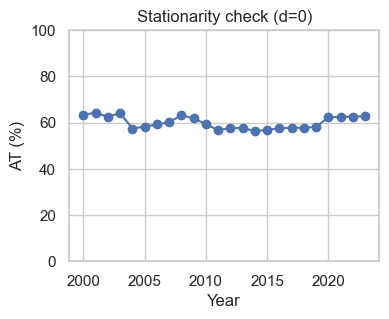

mean1=61.1875, mean2=58.7250, mean3=60.1875
var1=6.6236, var2=5.7469, var3=5.6236
ADF Statistic: -5.263580
p-value: 0.000007
Critical values:
  1%: -4.012
  5%: -3.104
  10%: -2.691


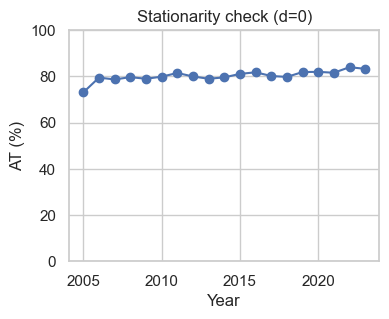

mean1=78.3167, mean2=80.5000, mean3=81.5833
var1=5.6081, var2=1.0600, var3=1.8681
ADF Statistic: 6.674041
p-value: 1.000000
Critical values:
  1%: -4.223
  5%: -3.189
  10%: -2.730


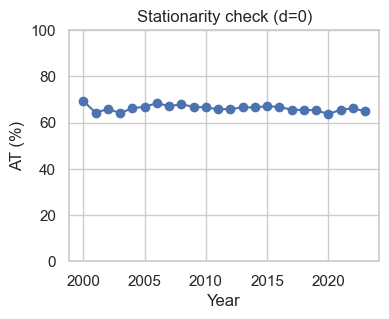

mean1=66.5625, mean2=66.6750, mean3=65.4625
var1=2.9023, var2=0.3894, var3=0.7248
ADF Statistic: -4.318594
p-value: 0.000412
Critical values:
  1%: -3.753
  5%: -2.998
  10%: -2.639


In [480]:
df_AT_mun = check_stationarity('AT', df_mun, 'municipal_recycling', 0)
df_AT_elec = check_stationarity('AT', df_elec, 'electrical_recycling', 0)
df_AT_pack = check_stationarity('AT', df_pack, 'packaging_recycling', 0)

Since for electrical recyclinf the fullter test gave a p-value bigger than 0.05, we assum that the time series is not stationary. Only after differentiating it two times it becomes stationary.

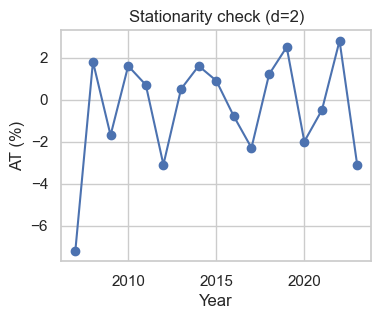

mean1=-0.9600, mean2=-0.1800, mean3=-0.2200
var1=11.2824, var2=2.7416, var3=3.3976
ADF Statistic: -6.222101
p-value: 0.000000
Critical values:
  1%: -4.332
  5%: -3.233
  10%: -2.749


In [481]:
df_AT_elec = check_stationarity('AT', df_elec, 'electrical_recycling', 2)

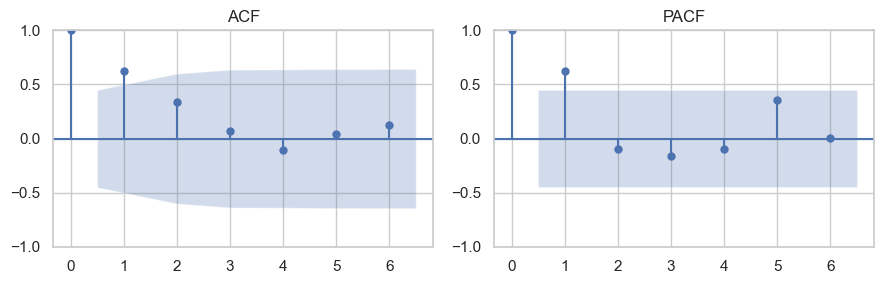

   p  q        AIC        BIC
0  1  1  88.584297  92.362053
1  1  2  89.687865  94.410060
2  1  3  90.088694  95.755328
3  2  1  90.557255  95.279449
4  2  2  91.217309  96.883942


In [482]:
train = df_AT_mun[df_AT_mun.index.get_level_values('year') <= 2018].copy()
test  = df_AT_mun[df_AT_mun.index.get_level_values('year') > 2018].copy()

y_mun = train['municipal_recycling']
y_mun.index = pd.to_datetime(y_mun.index, format='%Y')

x_mun = test['municipal_recycling']
x_mun.index = pd.to_datetime(x_mun.index, format='%Y')

check_orders(y_mun, x_mun, 2018, 'municipal_recycling', 4, 4, 0)

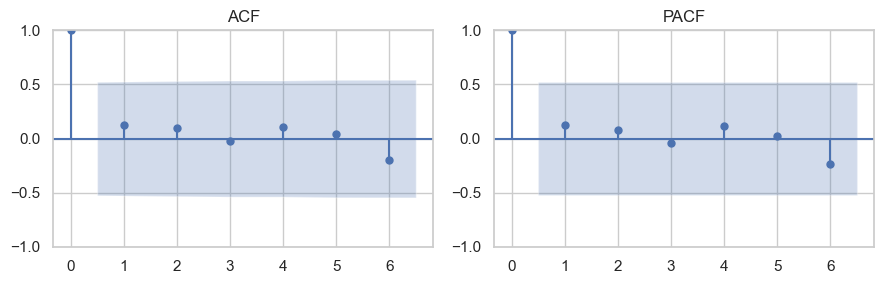

    p  q        AIC        BIC
15  4  4  58.728612  63.092772
11  3  4  59.240131  63.119384
9   3  2  59.542425  62.451865
0   1  1  59.791515  61.246235
14  4  3  59.896566  63.775819


In [483]:
train = df_AT_elec[df_AT_elec.index.get_level_values('year') <= 2018].copy()
test  = df_AT_elec[df_AT_elec.index.get_level_values('year') > 2018].copy()

y_elec = train['electrical_recycling']
y_elec.index = pd.to_datetime(y_elec.index, format='%Y')

x_elec = test['electrical_recycling']
x_elec.index = pd.to_datetime(x_elec.index, format='%Y')

check_orders(y_elec, x_elec, 2018, 'electrical_recycling', 5, 5, 2)

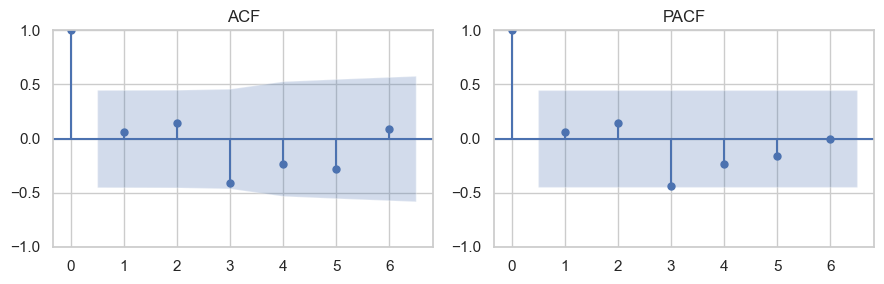

    p  q        AIC        BIC
8   3  1  59.681714  65.348348
9   3  2  61.219513  67.830586
12  4  1  61.314240  67.925313
10  3  3  61.854425  69.409937
6   2  3  62.159761  68.770834


In [484]:
train = df_AT_pack[df_AT_pack.index.get_level_values('year') <= 2018].copy()
test  = df_AT_pack[df_AT_pack.index.get_level_values('year') > 2018].copy()

y_pack = train['packaging_recycling']
y_pack.index = pd.to_datetime(y_pack.index, format='%Y')

x_pack = test['packaging_recycling']
x_pack.index = pd.to_datetime(x_pack.index, format='%Y')

check_orders(y_pack, x_pack, 2018, 'packaging_recycling', 5, 5, 0)

WE choos the order values based on the lowest AIC and then calcuate the ARIMA model.

2019-01-01    58.369640
2020-01-01    58.829919
2021-01-01    59.138625
2022-01-01    59.345673
2023-01-01    59.484539
Freq: YS-JAN, Name: predicted_mean, dtype: float64
            lower municipal_recycling  upper municipal_recycling
2019-01-01                  54.479810                  62.259470
2020-01-01                  54.113312                  63.546526
2021-01-01                  54.094104                  64.183147
2022-01-01                  54.160403                  64.530943
2023-01-01                  54.237186                  64.731891


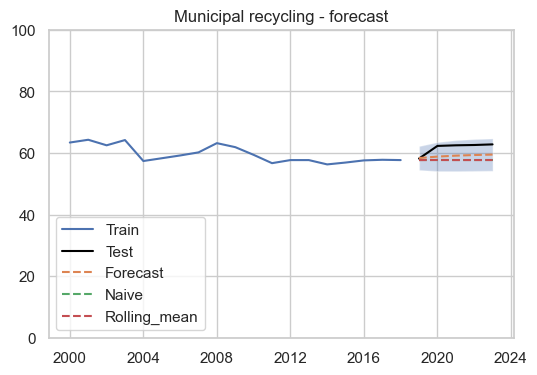

rmse ARIMA: 2.9983997271415324
rmse naive: 4.346722903521683
rmse rolling mean: 4.329245759507354
mae ARIMA: 2.714176757049452
mae naive: 3.979999999999997
mae rolling mean: 3.9641975308641904
2019-01-01    81.154347
2020-01-01    81.853684
2021-01-01    81.287828
2022-01-01    79.611403
2023-01-01    80.592719
Freq: YS-JAN, Name: predicted_mean, dtype: float64
            lower electrical_recycling  upper electrical_recycling
2019-01-01                   79.712207                   82.596487
2020-01-01                   79.933698                   83.773670
2021-01-01                   77.217960                   85.357695
2022-01-01                   74.680767                   84.542039
2023-01-01                   73.425280                   87.760159


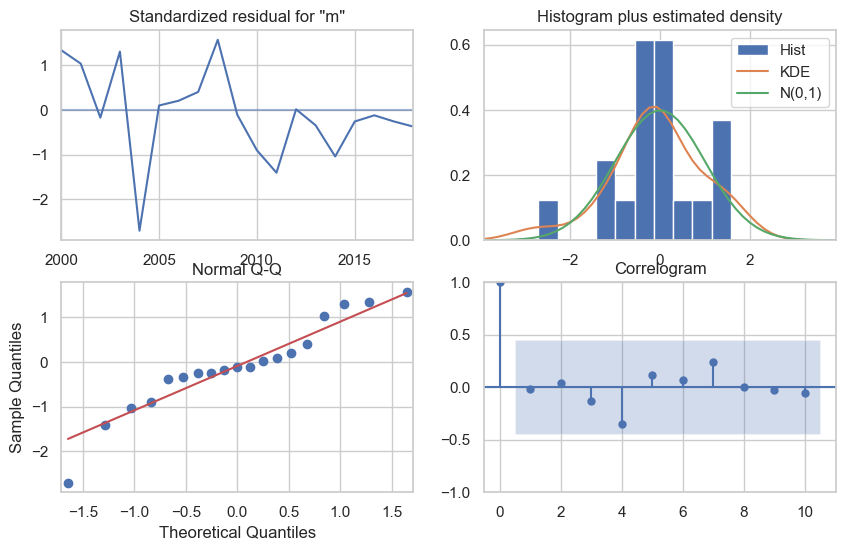

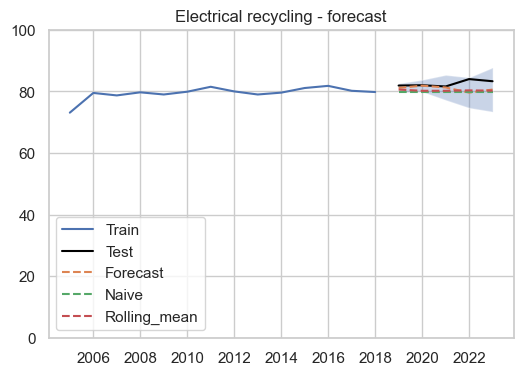

rmse ARIMA: 2.3351234763378055
rmse naive: 2.91135707188246
rmse rolling mean: 2.436015771604559
mae ARIMA: 1.6600037936674057
mae naive: 2.7600000000000025
mae rolling mean: 2.24444444444444
2019-01-01    65.835096
2020-01-01    66.702165
2021-01-01    67.284499
2022-01-01    67.582254
2023-01-01    67.191373
Freq: YS-JAN, Name: predicted_mean, dtype: float64
            lower packaging_recycling  upper packaging_recycling
2019-01-01                  64.337036                  67.333155
2020-01-01                  65.199694                  68.204635
2021-01-01                  65.652578                  68.916421
2022-01-01                  65.681826                  69.482681
2023-01-01                  65.273478                  69.109269


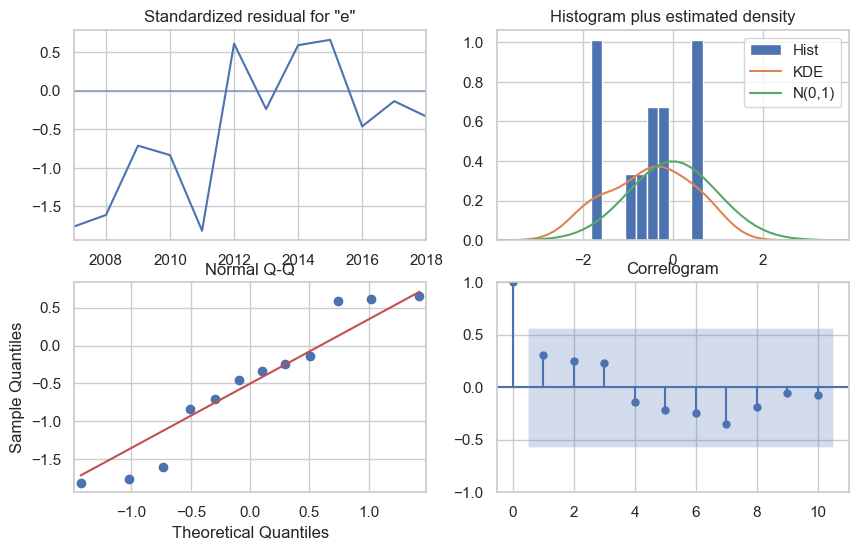

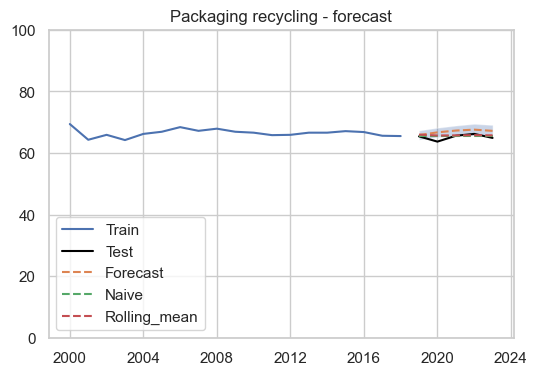

rmse ARIMA: 1.9596354189571572
rmse naive: 0.9066421565314492
rmse rolling mean: 1.0150451979504926
mae ARIMA: 1.7590772959426944
mae naive: 0.6599999999999966
mae rolling mean: 0.7831275720164541


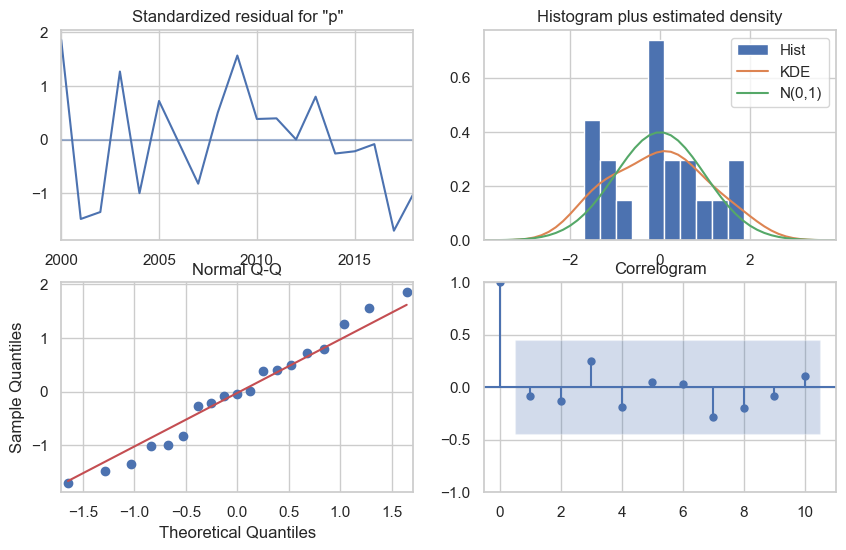

In [485]:
arima_model(y_mun , x_mun, 1, 0, 1, "Municipal recycling - forecast")
arima_model(y_elec , x_elec, 4, 2, 4, "Electrical recycling - forecast")
arima_model(y_pack , x_pack, 3, 0, 1, "Packaging recycling - forecast")

While the prediction is still not perfect, our rmse and mae are a lot smaller then for the linear regression, so we would prefer this instead of the regression.

Now, I will calculate the RMSE and MAE for all countries and calculate the mean.

In [486]:
def check_stationarity(country, dataset, response_var, d_max=3, alpha=0.05):
    """
    Determines the order of differencing d using the ADF test.
    """
    df = dataset[dataset["country"] == country].sort_values("year")
    y = df.set_index("year")[response_var].dropna()

    for d in range(d_max + 1):
        y_diff = y.copy()
        for _ in range(d):
            y_diff = y_diff.diff().dropna()

        adf_stat, pval, *_ = adfuller(y_diff.values)

        if pval < alpha:
            return d

    return d_max


def check_orders(y, d, p_range=range(1, 6), q_range=range(1, 6)):
    """
    Selects (p, q) based on minimum AIC.
    """
    warnings.filterwarnings("ignore")

    results = []

    for p, q in itertools.product(p_range, q_range):
        try:
            model = ARIMA(y, order=(p, d, q))
            res = model.fit()
            results.append({
                "p": p,
                "q": q,
                "AIC": res.aic
            })
        except:
            continue

    results_df = pd.DataFrame(results)
    best = results_df.loc[results_df["AIC"].idxmin()]

    return int(best["p"]), int(best["q"])

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


def arima_model(y, p, d, q, h=5):
    """
    Fits ARIMA model and evaluates forecast performance.
    """
    train = y.iloc[:-h]
    test = y.iloc[-h:]

    model = ARIMA(train, order=(p, d, q))
    res = model.fit()

    forecast = res.forecast(steps=h)

    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))

    return mae, rmse


def arima_pipeline(
    dataset,
    response_var,
    min_obs=10,
    h=3
):
    """
    Runs full ARIMA pipeline for all countries and returns per-country
    and overall MAE/RMSE.
    """
    results = []

    for country, g in dataset.groupby("country"):
        g = g.sort_values("year").dropna(subset=[response_var])

        if len(g) < min_obs:
            continue

        y = g.set_index("year")[response_var]

        try:
            d = check_stationarity(country, dataset, response_var)
            p, q = check_orders(y, d)
            mae, rmse = arima_model(y, p, d, q, h=h)

            results.append({
                "country": country,
                "p": p,
                "d": d,
                "q": q,
                "MAE": mae,
                "RMSE": rmse
            })

        except Exception:
            continue

    results_df = pd.DataFrame(results)

    summary = {
        "mean_MAE": results_df["MAE"].mean(),
        "mean_RMSE": results_df["RMSE"].mean(),
        "n_countries": len(results_df)
    }

    return results_df, summary

In [ ]:
df_arima_mun, arima_summary_mun = arima_pipeline(
    df_merged,
    response_var="municipal_recycling",
    h=5
)
#print(df_arima)
print(arima_summary_mun)

df_arima_elec, arima_summary_elec = arima_pipeline(
    df_merged,
    response_var="electrical_recycling",
    h=5
)
print(arima_summary_elec)

df_arima_elec, arima_summary_elec = arima_pipeline(
    df_merged,
    response_var="packaging_recycling",
    h=5
)
print(arima_summary_elec)

## 6.3.

Time Series models worked a lot better then the regression, even ou simple rolling mean and naive bayes approaches. A reason could be that for regression we did not include all characteristics that truly defince the recycling rate. Overall, a time series approach is preferred here. When soing a regression it is important ot leave the country in, as this makes a big difference.
Overall, the future values can be predicted decently well. Regression di dnot work at all for electrical waste, but depending on teh country the time series model did a goog job.
We though a panel regression might work, but in our case the results got worse, so this was not the fix, to our regression issue.
Some countries can be predicted better and some worse then others.

# 9. Findings

## 9.1. Potential bias
The data was not missing at random in our dataset, but mostly at the beginning and at the end of the time series. WE used backwards and forward filling to imputate these data, which could lead to some values being over or underestimated.

In question 4, the exclusion of observations with missing values may bias the analysis toward countries with more complete reporting, despite aggregation mitigating some data loss. While PCA and hierarchical clustering highlight across-country patterns in recycling within the EU, these methods are exploratory and descriptive. They are sensitive to scaling, variable selection, and data aggregation, and do not establish causal relationships - they do, however, provide a clear summary of structural factors linked to recycling performance.

## 9.2. Why were the questions good?

The questions were good questions, because they helped us anaylsze the recycling rate in EU countries. For once we can see if the EU-targets are fulfilled at the moment and we can also see if there a differences between the countries and what might lead to these differences to better help countries that need it it. By trying to predict the future, wen can also check if we think that the target will be fulfilled in the future or not.

Q1: How has the amount of recycling of waste developed in the EU overall over time?
The question give a clear overview of the development of recycling over time for the 27 eu countries. By analyzing answering the question there is a clear overview, about the overall trend of waste treatment in the eu, as well as for specific groups of waste, which shows also a difference between them.


Q4: Are there characteristics of countries that could lead to increased recycling?

After analyzing the development of recycling over time, this question investigates country-level characteristics to better understand the factors associated with lower or higher waste recycling rates. The insights gained from the analysis enable more informed and targeted decision-making regarding future regulations for increasing recycling across EU countries. 

Q5: How well can the development of the amount of recycling be predicted?  
By attempting to predict the development of recycling rates, it is possible to assess how countries are likely to perform in the future. Reliable predictions could help identify countries that are unlikely to reach the specified targets, allowing for earlier support measures or policy adjustments. In addition, if predictions suggest that the targets cannot be reached by most countries, this could indicate that the targets themselves may need to be reconsidered.

If recycling rates cannot be predicted with sufficient accuracy, this would indicate that their development is highly uncertain. In this case, forecasts based on past data would provide limited support for decision-making, and policy decisions would need to rely more strongly on expert judgment and qualitative assessments rather than on quantitative predictions alone.


## 9.3. Do the answers make any sense?
Q1: Yes the answer make sense, they show a clear uptrend to enviromently friendly and sustainable waste treatment.

Q5: It was suprising to us, that the panel regression worked a lot worse then simple linear regression. Maybe a reason was that we do not have many datapoints and if we seperate by country, not many datapoints per regression are left. That the time series worked decently well is not surpeise as a lot of data follws some kind of trend.


## 9.4. Were there any difficulties?
The Eurostat data included flags indicating varying levels of quality or reliability. After consideration, the numbers were used as reported, since no alternative was available. In a future project, the flags could be incorporated more systematically to assess data quality.

Merging the different datasets proved challenging and required substantial effort. The datasets cover different countries and time periods, which led to many missing values in the combined dataset and required careful preprocessing to create a unified dataset suitable for analysis. Especially the merging of all waste datasets was challanging, because non of them hat the a complete time and geo coverage. So we had to do the scaffold approch which was really challanging.

Some policies changed during our time series which lead to some changes that could not be exaplined just by the data.

Our time series was relatively short, which made it harder to predict the future as we did not have much data to build on. In the future as more data is added, this should get easier.
 

## 9.5. Which Data Science tools and techniques were learned during this exercise?
In the preproccessing we used a lot operations, that we learned in the lecture and had to use for the exam as well inlc. e.g. to turn data from the long to wide format, with pivot table. 

In question 1 we used varies plots to get an overview of the data and to better understand it. 

In Question 4 for the within-country exploratory analysis, a panel regression model was applied. For exploration across countries, Principal Component Analysis (PCA) and Hierarchical Clustering were used to visualize patterns, group countries with similar characteristics, and examine structural factors associated with recycling rates.

In Question 5 we used regression models like a simple linear regression and panel regression as well as time series data.

## 9.6. Key insights

* Question 4: Exploratory analyses using PCA and Hierarchical Clustering consistently highlight recycling patterns across countries within the EU. Higher GDP per capita, education attainment, and urbanization are associated with higher municipal and packaging recycling rates, while lower values correspond to lower recycling.

* Question 5: With a time Series model, the recycling rates can be predicted decently well for the next 5 years. The goal would e to predict further in the future, but at the moment the time series are relatively short, so t does not work yet. This might by possible in the future.



# 10. Appendix
## 10.1. Work Distribution

Every group member helped searched for datasets and for preprocessing of the dataset. Then every group menber slected one or more questions to answer.
Leon did the data engineering and preprocessing of the waste related datasets and answered question 1.
Amélie Assmayr answered question 5 and Anna Svoboda and Helene Vaught did question 4.
